# Initializing

In [ ]:
!pip install --upgrade huggingface-hub

In [ ]:
!pip install transformers -U

In [ ]:
!hf auth login --token ''

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

In [ ]:
BASE_DIRECTORY = "/"
MODELS_DIRECTORY = BASE_DIRECTORY + "models/"
DATASETS_DIRECTORY = BASE_DIRECTORY + "datasets/"
RESULTS_DIRECTORY = BASE_DIRECTORY + "results/"

In [ ]:
import random
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_curve, roc_auc_score
from torch.nn.functional import softmax
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
)
from scipy.stats import hmean
import pickle
from sklearn.metrics import f1_score
import gc

# Prompt Guard Functions

In [ ]:
def evaluate_batch(model, tokenizer, texts, batch_size=32, positive_label=1, temperature=1.0, device='cuda'):
    """
    Evaluate the model on a batch of texts with temperature-adjusted softmax.
    """
    model.to(device)
    model.eval()

    encoded_texts = tokenizer(texts, padding=True, truncation=True, max_length=512, return_tensors="pt")
    dataset = torch.utils.data.TensorDataset(encoded_texts['input_ids'], encoded_texts['attention_mask'])
    data_loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size)

    scores = []

    for batch in tqdm(data_loader, desc="Evaluating"):
        input_ids, attention_mask = [b.to(device) for b in batch]
        with torch.no_grad():
            logits = model(input_ids=input_ids, attention_mask=attention_mask).logits
        scaled_logits = logits / temperature
        probabilities = softmax(scaled_logits, dim=-1)
        positive_class_probabilities = probabilities[:, positive_label].cpu().numpy()
        scores.extend(positive_class_probabilities)

    return scores

In [ ]:
def train_model(model, tokenizer, train_df, batch_size=32, epochs=1, lr=5e-6, device='cuda'):
    """
    Train the model on the given dataset.
    """
    # Adjust the model's classifier to have two output labels
    model.classifier = torch.nn.Linear(model.classifier.in_features, 2)
    model.num_labels = 2

    model.to(device)
    model.train()

    # Prepare optimizer
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

    # Prepare data loader
    def collate_fn(batch):
        texts = [item['prompt'] for item in batch]
        labels = torch.tensor([int(item['label']) for item in batch])
        encodings = tokenizer(texts, padding=True, truncation=True, max_length=512, return_tensors="pt")
        return encodings.input_ids, encodings.attention_mask, labels

    # Convert DataFrame to list of dictionaries for DataLoader
    train_data = train_df[['prompt', 'label']].to_dict('records')
    data_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)

    # Training loop
    for epoch in range(epochs):
        total_loss = 0
        for batch in tqdm(data_loader, desc=f"Epoch {epoch + 1}"):
            input_ids, attention_mask, labels = [x.to(device) for x in batch]
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss

            # Backpropagation
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Average loss in epoch {epoch + 1}: {total_loss / len(data_loader):.6f}")

    return model, tokenizer

In [ ]:
def save_model_and_tokenizer(model, tokenizer, save_dir):
    """
    Saves a Hugging Face model and tokenizer to a given directory.
    Works for both pretrained and fine-tuned models.
    """
    os.makedirs(save_dir, exist_ok=True)
    model.save_pretrained(save_dir)
    tokenizer.save_pretrained(save_dir)
    print(f"✅ Model and tokenizer saved to: {save_dir}")

def load_model_and_tokenizer(load_dir):
    """
    Loads a Hugging Face model and tokenizer from a directory.
    Automatically restores the correct architecture/config.
    """
    tokenizer = AutoTokenizer.from_pretrained(load_dir)
    model = AutoModelForSequenceClassification.from_pretrained(load_dir)
    print(f"✅ Model and tokenizer loaded from: {load_dir}")
    return model, tokenizer

In [ ]:
def compute_asr_fpr(labels, preds):
    """
    Compute Attack Success Rate (ASR) and False Positive Rate (FPR).

    Args:
        labels (list[int]): Ground truth labels (0 = benign, 1 = attack)
        preds (list[int]): Model predictions (0 = safe/blocked, 1 = unsafe/succeeded)

    Returns:
        dict: {"ASR": float, "FPR": float}
    """
    if len(labels) != len(preds):
        raise ValueError("labels and preds must have the same length")

    # convert to integers for safety
    labels = [int(x) for x in labels]
    preds = [int(x) for x in preds]

    # isolate subsets
    attack_idx = [i for i, y in enumerate(labels) if y == 1]
    benign_idx = [i for i, y in enumerate(labels) if y == 0]

    n_attacks = len(attack_idx)
    n_benign = len(benign_idx)

    if n_attacks == 0 or n_benign == 0:
        raise ValueError("Need at least one attack and one benign sample")

    # ASR: fraction of attack samples that succeeded (pred == 1)
    asr = sum(preds[i] for i in attack_idx) / n_attacks

    # FPR: fraction of benign samples incorrectly flagged as unsafe (pred == 1)
    fpr = sum(preds[i] for i in benign_idx) / n_benign

    return {"ASR": (1 - asr), "FPR": fpr}

# Dataset / Finetune 1

## synapsecai/synthetic-prompt-injections

https://www.oxen.ai/synapsecai/synthetic-prompt-injections

In [ ]:
df = pd.read_parquet(DATASETS_DIRECTORY + "synthetic-prompt-injections_train.parquet")

df = df[['text', 'label']]

df = df.rename(columns={'text': 'prompt'})

train_df, temp_df = train_test_split(df, test_size=0.30, random_state=42)
cal_df, test_df = train_test_split(temp_df, test_size=2/3, random_state=42)
finetuning_df, val_df = train_test_split(train_df, test_size=0.20, random_state=42)

In [ ]:
# Load the Prompt Guard model
prompt_injection_model_name = 'meta-llama/Llama-Prompt-Guard-2-86M'
tokenizer = AutoTokenizer.from_pretrained(prompt_injection_model_name)
model = AutoModelForSequenceClassification.from_pretrained(prompt_injection_model_name)

In [ ]:
print("\n" + "="*50)
print("EVALUATING ORIGINAL MODEL ON VAL SET")
print("="*50)

test_texts = val_df['prompt'].tolist()
test_labels = val_df['label'].tolist()

# Get predictions from model
test_scores = evaluate_batch(model, tokenizer, test_texts, batch_size=64, positive_label=1, temperature=3.0)

# Convert scores to binary predictions (threshold = 0.5)
test_predictions = [1 if score > 0.5 else 0 for score in test_scores]

# Calculate metrics
metrics = compute_asr_fpr(test_labels, test_predictions)

print(f"Original Model Performance:")
print(metrics)

In [ ]:
# Fine-tune the model
print("\n" + "="*50)
print("FINE-TUNING MODEL")
print("="*50)

model, tokenizer = train_model(model, tokenizer, finetuning_df, batch_size=16, epochs=3, device='cuda')

In [ ]:
print("\n" + "="*50)
print("EVALUATING FINETUNED MODEL ON VAL SET")
print("="*50)

test_texts = val_df['prompt'].tolist()
test_labels = val_df['label'].tolist()

# Get predictions from model
test_scores = evaluate_batch(model, tokenizer, test_texts, batch_size=64, positive_label=1, temperature=3.0)

# Convert scores to binary predictions (threshold = 0.5)
test_predictions = [1 if score > 0.5 else 0 for score in test_scores]

# Calculate metrics
metrics = compute_asr_fpr(test_labels, test_predictions)

print(f"Finetuned Model Performance:")
print(metrics)

In [ ]:
save_dir = MODELS_DIRECTORY + "model_1"
save_model_and_tokenizer(model, tokenizer, save_dir)

In [ ]:
# delete the old model explicitly
del model
gc.collect()
torch.cuda.empty_cache()

In [ ]:
# Save finetuning dataset partition into combined dataset
test_df['model'] = 1
combined_df = test_df.copy()
print("Combined dataset size = ", combined_df.shape[0])
combined_df.head()

## Analysis

In [ ]:
print("No analysis until at least 3 finetunes are trained")

No analysis until at least 3 finetunes are trained


# Dataset / Finetune 2

## Malicious Prompt Detection Dataset (MPDD)

https://www.kaggle.com/datasets/mohammedaminejebbar/malicious-prompt-detection-dataset-mpdd

In [ ]:
df = pd.read_csv(DATASETS_DIRECTORY + "MPDD.csv")

df = df[['text', 'label']]

df = df.rename(columns={'text': 'prompt'})

train_df, temp_df = train_test_split(df, test_size=0.30, random_state=42)
cal_df, test_df = train_test_split(temp_df, test_size=2/3, random_state=42)
finetuning_df, val_df = train_test_split(train_df, test_size=0.20, random_state=42)

In [ ]:
# Load the Prompt Guard model
prompt_injection_model_name = 'meta-llama/Llama-Prompt-Guard-2-86M'
tokenizer = AutoTokenizer.from_pretrained(prompt_injection_model_name)
model = AutoModelForSequenceClassification.from_pretrained(prompt_injection_model_name)

In [ ]:
print("\n" + "="*50)
print("EVALUATING ORIGINAL MODEL ON VAL SET")
print("="*50)

test_texts = val_df['prompt'].tolist()
test_labels = val_df['label'].tolist()

# Get predictions from model
test_scores = evaluate_batch(model, tokenizer, test_texts, batch_size=64, positive_label=1, temperature=3.0)

# Convert scores to binary predictions (threshold = 0.5)
test_predictions = [1 if score > 0.5 else 0 for score in test_scores]

# Calculate metrics
metrics = compute_asr_fpr(test_labels, test_predictions)

print(f"Original Model Performance:")
print(metrics)

In [ ]:
# Fine-tune the model
print("\n" + "="*50)
print("FINE-TUNING MODEL")
print("="*50)

model, tokenizer = train_model(model, tokenizer, finetuning_df, batch_size=16, epochs=3, device='cuda')

In [ ]:
print("\n" + "="*50)
print("EVALUATING FINETUNED MODEL ON VAL SET")
print("="*50)

test_texts = val_df['prompt'].tolist()
test_labels = val_df['label'].tolist()

# Get predictions from model
test_scores = evaluate_batch(model, tokenizer, test_texts, batch_size=64, positive_label=1, temperature=3.0)

# Convert scores to binary predictions (threshold = 0.5)
test_predictions = [1 if score > 0.5 else 0 for score in test_scores]

# Calculate metrics
metrics = compute_asr_fpr(test_labels, test_predictions)

print(f"Finetuned Model Performance:")
print(metrics)

In [ ]:
save_dir = MODELS_DIRECTORY + "model_2"
save_model_and_tokenizer(model, tokenizer, save_dir)

In [ ]:
# delete the old model explicitly
del model
gc.collect()
torch.cuda.empty_cache()

In [ ]:
# Save finetuning dataset partition into combined dataset
test_df['model'] = 2
combined_df = pd.concat([combined_df, test_df], ignore_index=True)
print("Combined dataset size = ", combined_df.shape[0])
combined_df.head()

## Analysis

In [ ]:
print("No analysis until at least 3 finetunes are trained")

No analysis until at least 3 finetunes are trained


# Dataset / Finetune 3

## TrustAIRLab/in-the-wild-jailbreak-prompts

https://huggingface.co/datasets/TrustAIRLab/in-the-wild-jailbreak-prompts

In [ ]:
# Load and analyze dataset
print("Loading dataset...")

part1 = load_dataset('TrustAIRLab/in-the-wild-jailbreak-prompts', 'jailbreak_2023_12_25', split='train')
part2 = load_dataset('TrustAIRLab/in-the-wild-jailbreak-prompts', 'regular_2023_12_25', split='train')

df1 = part1.to_pandas()
df2 = part2.to_pandas()

df = pd.concat([df1, df2], ignore_index=True)

df = df[['prompt', 'jailbreak']]

df['label'] = df['jailbreak'].map({True: 1, False: 0})
df = df.drop(columns=['jailbreak'])

In [ ]:
train_df, temp_df = train_test_split(df, test_size=0.30, random_state=42)
cal_df, test_df = train_test_split(temp_df, test_size=2/3, random_state=42)
finetuning_df, val_df = train_test_split(train_df, test_size=0.20, random_state=42)

In [ ]:
# Load the Prompt Guard model
prompt_injection_model_name = 'meta-llama/Llama-Prompt-Guard-2-86M'
tokenizer = AutoTokenizer.from_pretrained(prompt_injection_model_name)
model = AutoModelForSequenceClassification.from_pretrained(prompt_injection_model_name)

In [ ]:
print("\n" + "="*50)
print("EVALUATING ORIGINAL MODEL ON VAL SET")
print("="*50)

test_texts = val_df['prompt'].tolist()
test_labels = val_df['label'].tolist()

# Get predictions from model
test_scores = evaluate_batch(model, tokenizer, test_texts, batch_size=64, positive_label=1, temperature=3.0)

# Convert scores to binary predictions (threshold = 0.5)
test_predictions = [1 if score > 0.5 else 0 for score in test_scores]

# Calculate metrics
metrics = compute_asr_fpr(test_labels, test_predictions)

print(f"Original Model Performance:")
print(metrics)

In [ ]:
# Fine-tune the model
print("\n" + "="*50)
print("FINE-TUNING MODEL")
print("="*50)

model, tokenizer = train_model(model, tokenizer, finetuning_df, batch_size=16, epochs=3, device='cuda')

In [ ]:
print("\n" + "="*50)
print("EVALUATING FINETUNED MODEL ON VAL SET")
print("="*50)

test_texts = test_df['prompt'].tolist()
test_labels = test_df['label'].tolist()

# Get predictions from original model
test_scores = evaluate_batch(model, tokenizer, test_texts, batch_size=64, positive_label=1, temperature=3.0)

# Convert scores to binary predictions (threshold = 0.5)
test_predictions = [1 if score > 0.5 else 0 for score in test_scores]

# Calculate metrics
metrics = compute_asr_fpr(test_labels, test_predictions)

print(f"Finetuned Model Performance:")
print(metrics)

In [ ]:
save_dir = MODELS_DIRECTORY + "model_3"
save_model_and_tokenizer(model, tokenizer, save_dir)

In [ ]:
# delete the old model explicitly
del model
gc.collect()
torch.cuda.empty_cache()

In [ ]:
# Save finetuning dataset partition into combined dataset
test_df['model'] = 3
combined_df = pd.concat([combined_df, test_df], ignore_index=True)
print("Combined dataset size = ", combined_df.shape[0])
combined_df.head()

In [ ]:
# Save combined dataset for k = 3
combined_df.to_csv(RESULTS_DIRECTORY + "k=3/combined_df.csv", index=False)

## Analysis

In [ ]:
# Load the combined dataset at this point in time
combined_df = pd.read_csv(RESULTS_DIRECTORY + "k=3/combined_df.csv")

In [ ]:
test_texts = combined_df['prompt'].tolist()
test_labels = combined_df['label'].tolist()
best_model_ids = combined_df['model'].tolist()

In [ ]:
#Baseline Results
prompt_injection_model_name = 'meta-llama/Llama-Prompt-Guard-2-86M'
tokenizer = AutoTokenizer.from_pretrained(prompt_injection_model_name)
model = AutoModelForSequenceClassification.from_pretrained(prompt_injection_model_name)

baseline_probs = evaluate_batch(model, tokenizer, test_texts, positive_label=1, temperature=3.0)

#Model 1 Results
model, tokenizer = load_model_and_tokenizer(MODELS_DIRECTORY + "model_1")

model_1_probs = evaluate_batch(model, tokenizer, test_texts, positive_label=1, temperature=3.0)

#Model 2 Results
model, tokenizer = load_model_and_tokenizer(MODELS_DIRECTORY + "model_2")

model_2_probs = evaluate_batch(model, tokenizer, test_texts, positive_label=1, temperature=3.0)

#Model 3 Results
model, tokenizer = load_model_and_tokenizer(MODELS_DIRECTORY + "model_3")

model_3_probs = evaluate_batch(model, tokenizer, test_texts, positive_label=1, temperature=3.0)

In [ ]:
with open(RESULTS_DIRECTORY + "k=3/baseline_probs.pkl", "wb") as f:
    pickle.dump(baseline_probs, f)
with open(RESULTS_DIRECTORY + "k=3/model_1_probs.pkl", "wb") as f:
    pickle.dump(model_1_probs, f)
with open(RESULTS_DIRECTORY + "k=3/model_2_probs.pkl", "wb") as f:
    pickle.dump(model_2_probs, f)
with open(RESULTS_DIRECTORY + "k=3/model_3_probs.pkl", "wb") as f:
    pickle.dump(model_3_probs, f)

In [ ]:
with open(RESULTS_DIRECTORY + "k=3/baseline_probs.pkl", "rb") as f:
    baseline_probs = pickle.load(f)
with open(RESULTS_DIRECTORY + "k=3/model_1_probs.pkl", "rb") as f:
    model_1_probs = pickle.load(f)
with open(RESULTS_DIRECTORY + "k=3/model_2_probs.pkl", "rb") as f:
    model_2_probs = pickle.load(f)
with open(RESULTS_DIRECTORY + "k=3/model_3_probs.pkl", "rb") as f:
    model_3_probs = pickle.load(f)

In [ ]:
import pandas as pd
import numpy as np
import re
from collections import Counter
from math import log2

# Function to calculate Shannon entropy of characters
def text_entropy(text):
    if not text:
        return 0
    freq = Counter(text)
    probs = [v / len(text) for v in freq.values()]
    return -sum(p * log2(p) for p in probs)

# Function to check for common code keywords
code_keywords = {'if', 'else', 'while', 'for', 'import', 'def', 'function',
                 'var', 'let', 'const', 'return', 'class', 'script', 'print', 'exec'}

common_english = {'the', 'and', 'you', 'your', 'please', 'what', 'how', 'can', 'do', 'tell'}

def extract_features(df):
    df = df.copy()

    # Basic text cleaning
    df['prompt'] = df['prompt'].astype(str)

    # 1. Prompt length (in words)
    df['prompt_length'] = df['prompt'].apply(lambda x: len(x.split()))

    # 2. Whitespace proportion
    df['whitespace_proportion'] = df['prompt'].apply(lambda x: x.count(' ') / len(x) if len(x) > 0 else 0)

    # 3. Special character proportion
    special_chars = r"[^a-zA-Z0-9\s]"
    df['special_char_proportion'] = df['prompt'].apply(
        lambda x: len(re.findall(special_chars, x)) / len(x) if len(x) > 0 else 0
    )

    # 4. Average word length
    df['avg_word_length'] = df['prompt'].apply(
        lambda x: np.mean([len(w) for w in x.split()]) if len(x.split()) > 0 else 0
    )

    # 5. Digit proportion
    df['digit_proportion'] = df['prompt'].apply(lambda x: sum(c.isdigit() for c in x) / len(x) if len(x) > 0 else 0)

    # 6. Uppercase ratio
    df['uppercase_ratio'] = df['prompt'].apply(lambda x: sum(c.isupper() for c in x) / len(x) if len(x) > 0 else 0)

    # 7. Code keyword proportion
    df['code_keyword_count'] = df['prompt'].apply(
        lambda x: sum(1 for w in re.findall(r'\b\w+\b', x.lower()) if w in code_keywords)
    )

    # 8. Natural language word proportion
    df['nl_word_count'] = df['prompt'].apply(
        lambda x: sum(1 for w in re.findall(r'\b\w+\b', x.lower()) if w in common_english)
    )

    # 9. Character entropy
    df['char_entropy'] = df['prompt'].apply(text_entropy)

    return df

# Example usage:
combined_df = extract_features(combined_df)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# X = combined_df.drop(columns=['prompt', 'model', 'label', 'type'])
X = cal_df.drop(columns=['prompt', 'model', 'label'])
y = cal_df['model']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = RandomForestClassifier(n_estimators=200, random_state=42)
clf.fit(X_train, y_train)

print("Accuracy:", clf.score(X_test, y_test))

In [ ]:
best_model_ids_forest = clf.predict(X)
print(len(best_model_ids_forest))
print(best_model_ids_forest)

In [ ]:
best_model_ids_forest = best_model_ids_forest.tolist()

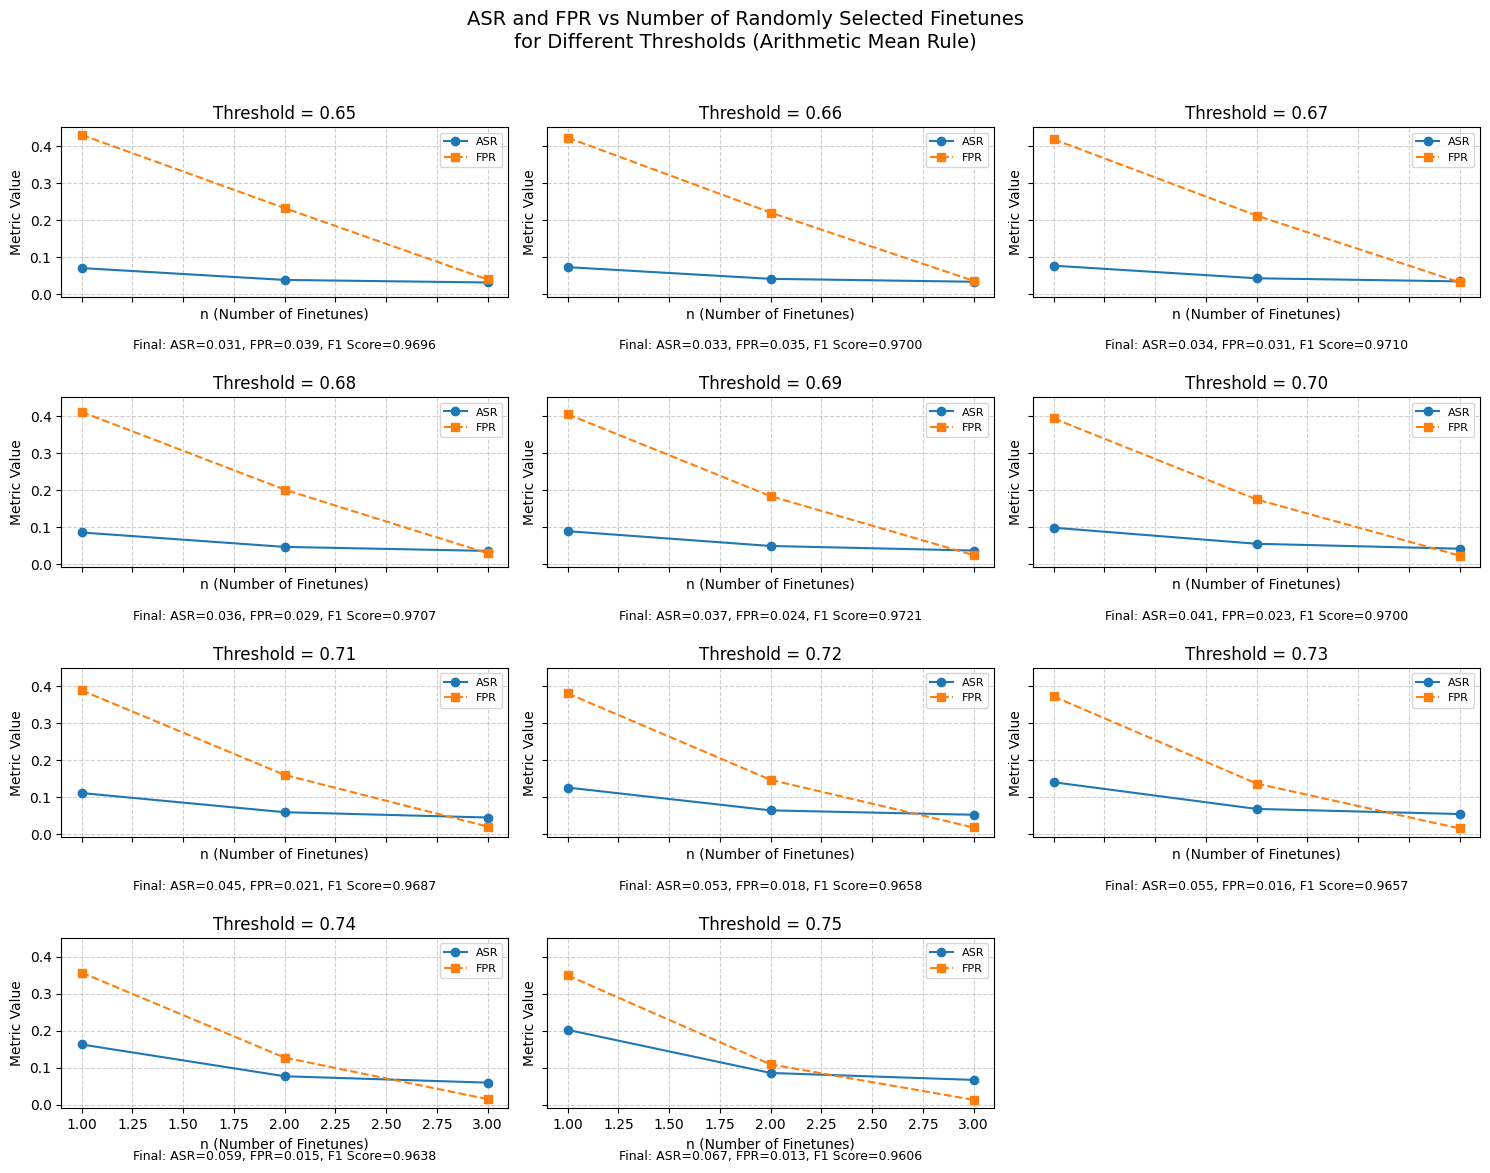

In [ ]:
# Collect finetune model probabilities
finetune_probs = [
    model_1_probs,
    model_2_probs,
    model_3_probs
]

n_models = len(finetune_probs)
n_samples = len(test_labels)
thresholds = np.arange(0.65, 0.76, 0.01)

random.seed(42)
all_results = []

# --- Main loop: n = 1..5, threshold sweep ---
for n in range(1, n_models + 1):
    combined_probs = []
    for i in range(n_samples):
        selected_indices = random.sample(range(n_models), n)
        avg_prob = np.mean([finetune_probs[j][i] for j in selected_indices])
        combined_probs.append(avg_prob)
    combined_probs = np.array(combined_probs)

    for thresh in thresholds:
        preds = [1 if p > thresh else 0 for p in combined_probs]
        metrics = compute_asr_fpr(test_labels, preds)
        f1 = f1_score([int(x) for x in test_labels], preds)
        all_results.append({
            'n': n,
            'threshold': round(thresh, 2),
            'ASR': metrics['ASR'],
            'FPR': metrics['FPR'],
            'F1': f1
        })

results_df = pd.DataFrame(all_results)

# --- Plot: one subplot per threshold, showing both ASR and FPR ---
num_thresholds = len(thresholds)
ncols = 3  # grid layout (3 columns)
nrows = int(np.ceil(num_thresholds / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 3), sharex=True, sharey=True)
axes = axes.flatten()

for idx, thresh in enumerate(thresholds):
    ax = axes[idx]
    subset = results_df[results_df['threshold'] == round(thresh, 2)]

    ax.plot(subset['n'], subset['ASR'], marker='o', label='ASR', color='C0')
    ax.plot(subset['n'], subset['FPR'], marker='s', linestyle='--', label='FPR', color='C1')
    ax.set_title(f'Threshold = {thresh:.2f}')
    ax.set_xlabel('n (Number of Finetunes)')
    ax.set_ylabel('Metric Value')
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(fontsize=8)

    final_row = subset[subset['n'] == len(finetune_probs)].iloc[0]
    final_asr = final_row['ASR']
    final_fpr = final_row['FPR']
    final_f1 = final_row['F1']
    ax.text(
        0.5, -0.25,
        f"Final: ASR={final_asr:.3f}, FPR={final_fpr:.3f}, F1 Score={final_f1:.4f}",
        ha='center', va='top', transform=ax.transAxes, fontsize=9, color='black'
    )

# Hide unused subplots if thresholds don’t fill the grid
for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('ASR and FPR vs Number of Randomly Selected Finetunes\nfor Different Thresholds (Arithmetic Mean Rule)', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


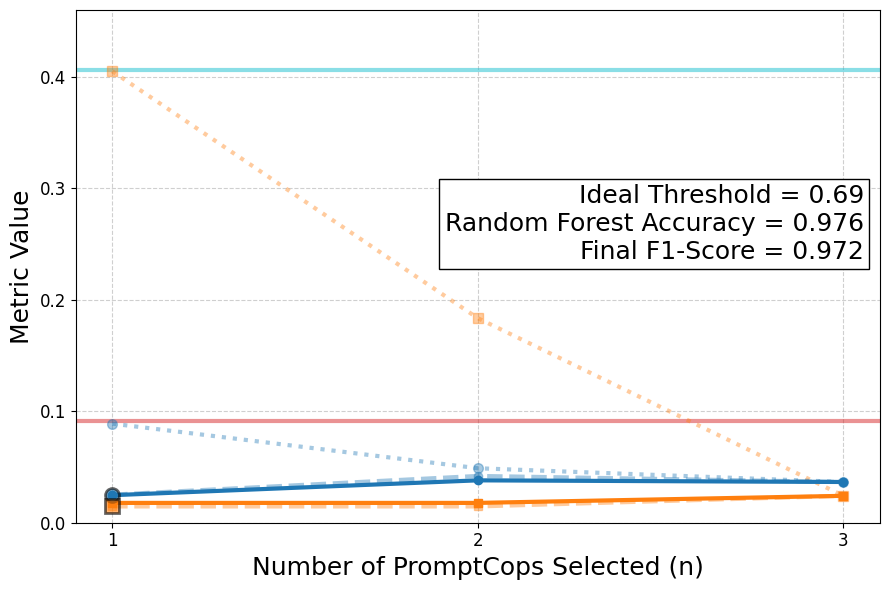

In [ ]:
threshold = 0.69

# Collect all fine-tune model probabilities
finetune_probs = [
    model_1_probs,
    model_2_probs,
    model_3_probs
]

n_models = len(finetune_probs)
n_samples = len(test_labels)
results = []
ideal_results = []
forest_results = []

random.seed(42)  # reproducibility

# --- Baseline (non-finetuned model) ---
baseline_preds = [1 if p > 0.5 else 0 for p in baseline_probs]
baseline_metrics = compute_asr_fpr(test_labels, baseline_preds)
baseline_asr = baseline_metrics['ASR']
baseline_fpr = baseline_metrics['FPR']

# --- Normal random finetune selection for n = 1..5 ---
for n in range(1, n_models + 1):
    combined_probs = []
    for i in range(n_samples):
        selected_indices = random.sample(range(n_models), n)
        avg_prob = np.mean([finetune_probs[j][i] for j in selected_indices])
        combined_probs.append(avg_prob)

    preds = [1 if p > threshold else 0 for p in combined_probs]
    metrics = compute_asr_fpr(test_labels, preds)
    metrics['n'] = n
    results.append(metrics)

# --- Ideal case: always include the best model per sample ---
# best_model_ids is a list of integers from 1 to 5 (same length as test_labels)
for n in range(1, n_models + 1):
    combined_probs = []
    for i in range(n_samples):
        best_model_idx = best_model_ids[i] - 1  # convert 1–5 → 0–4 index

        if n == 1:
            selected_indices = [best_model_idx]
        else:
            # Always include the best model, and select the rest randomly
            other_indices = [idx for idx in range(n_models) if idx != best_model_idx]
            selected_indices = [best_model_idx] + random.sample(other_indices, n - 1)

        avg_prob = np.mean([finetune_probs[j][i] for j in selected_indices])
        combined_probs.append(avg_prob)

    preds = [1 if p > threshold else 0 for p in combined_probs]
    metrics = compute_asr_fpr(test_labels, preds)
    metrics['n'] = n
    ideal_results.append(metrics)


# --- Forest case: always include the random forest model per sample ---
# best_model_ids_forest is a list of integers from 1 to 9 (same length as test_labels)
for n in range(1, n_models + 1):
    combined_probs = []
    for i in range(n_samples):
        best_model_idx = best_model_ids_forest[i] - 1  # convert 1–5 → 0–4 index

        if n == 1:
            selected_indices = [best_model_idx]
        else:
            # Always include the best model, and select the rest randomly
            other_indices = [idx for idx in range(n_models) if idx != best_model_idx]
            selected_indices = [best_model_idx] + random.sample(other_indices, n - 1)

        avg_prob = np.mean([finetune_probs[j][i] for j in selected_indices])
        combined_probs.append(avg_prob)

    preds = [1 if p > threshold else 0 for p in combined_probs]
    metrics = compute_asr_fpr(test_labels, preds)
    metrics['n'] = n
    forest_results.append(metrics)
    forest_final_f1 = f1_score(test_labels, preds)



# --- Extract values for plotting ---
n_values = [r['n'] for r in results]
asr_values = [r['ASR'] for r in results]
fpr_values = [r['FPR'] for r in results]

ideal_asr_values = [r['ASR'] for r in ideal_results]
ideal_fpr_values = [r['FPR'] for r in ideal_results]

forest_asr_values = [r['ASR'] for r in forest_results]
forest_fpr_values = [r['FPR'] for r in forest_results]

# --- Compute final F1 score for the random strategy (at n = ?) ---
# Reconstruct the last (n=?) combined probabilities and predictions
final_combined_probs = []
n_final = n_models
for i in range(n_samples):
    selected_indices = random.sample(range(n_models), n_final)
    avg_prob = np.mean([finetune_probs[j][i] for j in selected_indices])
    final_combined_probs.append(avg_prob)

final_preds = [1 if p > threshold else 0 for p in final_combined_probs]
final_f1 = f1_score(test_labels, final_preds)

# --- Plot ---
plt.figure(figsize=(9, 6))

plt.axhline(y=baseline_asr, color='C9', alpha=0.5, label='Baseline ASR', linewidth=3)
plt.axhline(y=baseline_fpr, color='C3', alpha=0.5, label='Baseline FPR', linewidth=3)
plt.plot(n_values, asr_values, marker='o', linestyle=':', color='C0', alpha=0.4, label='Random Selection ASR', linewidth=3, markersize=7)
plt.plot(n_values, fpr_values, marker='s', linestyle=':', color='C1', alpha=0.4, label='Random Selection FPR', linewidth=3, markersize=7)
plt.plot(n_values, forest_asr_values, marker='o', color='C0', label='ASR (Predicted Expert and n-1 Random Selections)', linewidth=3)
plt.plot(n_values, forest_fpr_values, marker='s', color='C1', label='FPR (Predicted Expert and n-1 Random Selections)', linewidth=3)
plt.plot(n_values, ideal_asr_values, marker='o', linestyle='--', color='C0', alpha=0.4, label='Ideal ASR (Best Expert and n-1 Random Selections)', linewidth=3)
plt.plot(n_values, ideal_fpr_values, marker='s', linestyle='--', color='C1', alpha=0.4, label='Ideal FPR (Best Expert and n-1 Random Selections)', linewidth=3)

plt.plot(
    n_values[0], ideal_asr_values[0],
    marker='o', markersize=10, linestyle='None',
    color='C0', markeredgecolor='black',
    label='Ideal ASR (Best Expert Only)', zorder=5, alpha=0.6,
    markeredgewidth=2
)

plt.plot(
    n_values[0], ideal_fpr_values[0],
    marker='s', markersize=10, linestyle='None',
    color='C1', markeredgecolor='black',
    label='Ideal FPR (Best Expert Only)', zorder=5, alpha=0.6,
    markeredgewidth=2
)

textstr = f'Ideal Threshold = {threshold}\nRandom Forest Accuracy = {clf.score(X_test, y_test):.3f}\nFinal F1-Score = {final_f1:.3f}'
plt.text(
    0.98, 0.66, textstr,
    transform=plt.gca().transAxes,
    fontsize=18,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(facecolor="white", alpha=1.0)
)

plt.ylim(0, 0.46)
plt.xlabel('Number of PromptCops Selected (n)', fontsize='18')
plt.ylabel('Metric Value', fontsize='18')
# plt.title(
#     f'(k=3) Performance Across Increasing Selection Size',
#     fontweight='bold',
#     fontsize='19'
# )
plt.grid(True, linestyle='--', alpha=0.6)

plt.tick_params(axis='both', which='major', labelsize=12)
plt.xticks([1, 2, 3])

# leg = plt.legend(loc="upper right", bbox_to_anchor=(0.99, 0.96), borderaxespad=0.0, facecolor="white", fontsize='11')
# for text in leg.get_texts():
#     if text.get_text() == "ASR (Predicted Expert and n-1 Random Selections)" or text.get_text() == "FPR (Predicted Expert and n-1 Random Selections)":
#         text.set_fontstyle('oblique')

plt.tight_layout()
plt.savefig("exp2_3.pdf", bbox_inches="tight")
plt.show()

In [ ]:
print("ASR Values:", asr_values)
print("FPR Values:", fpr_values)
print("Ideal ASR Values:", ideal_asr_values)
print("Ideal FPR Values:", ideal_fpr_values)
print("Forest ASR Values:", forest_asr_values)
print("Forest FPR Values:", forest_fpr_values)

ASR Values: [0.0888888888888889, 0.04888888888888887, 0.03654320987654325]
FPR Values: [0.4050793650793651, 0.18349206349206348, 0.02412698412698413]
Ideal ASR Values: [0.0251851851851852, 0.041975308641975295, 0.03654320987654325]
Ideal FPR Values: [0.014603174603174604, 0.014603174603174604, 0.02412698412698413]
Forest ASR Values: [0.024691358024691357, 0.038024691358024665, 0.03654320987654325]
Forest FPR Values: [0.017777777777777778, 0.017777777777777778, 0.02412698412698413]


# Dataset / Finetune 4

## Harelix/Prompt-Injection-Mixed-Techniques-2024

https://ai.gitee.com/hf-datasets/Harelix/Prompt-Injection-Mixed-Techniques-2024/blob/main/train.csv

In [ ]:
df = pd.read_csv(DATASETS_DIRECTORY + 'harelix_data.csv', names=['prompt', 'label'])
df['label'] = df['label'].map({'malicious': 1, 'valid': 0})

train_df, temp_df = train_test_split(df, test_size=0.30, random_state=42)
cal_df, test_df = train_test_split(temp_df, test_size=2/3, random_state=42)
finetuning_df, val_df = train_test_split(train_df, test_size=0.20, random_state=42)

In [ ]:
# Load the Prompt Guard model
prompt_injection_model_name = 'meta-llama/Llama-Prompt-Guard-2-86M'
tokenizer = AutoTokenizer.from_pretrained(prompt_injection_model_name)
model = AutoModelForSequenceClassification.from_pretrained(prompt_injection_model_name)

In [ ]:
print("\n" + "="*50)
print("EVALUATING ORIGINAL MODEL ON VAL SET")
print("="*50)

test_texts = val_df['prompt'].tolist()
test_labels = val_df['label'].tolist()

# Get predictions from model
test_scores = evaluate_batch(model, tokenizer, test_texts, batch_size=64, positive_label=1, temperature=3.0)

# Convert scores to binary predictions (threshold = 0.5)
test_predictions = [1 if score > 0.5 else 0 for score in test_scores]

# Calculate metrics
metrics = compute_asr_fpr(test_labels, test_predictions)

print(f"Original Model Performance:")
print(metrics)

In [ ]:
# Fine-tune the model
print("\n" + "="*50)
print("FINE-TUNING MODEL")
print("="*50)

model, tokenizer = train_model(model, tokenizer, train_df, batch_size=16, epochs=3, device='cuda')

In [ ]:
print("\n" + "="*50)
print("EVALUATING FINETUNED MODEL ON VAL SET")
print("="*50)

test_texts = val_df['prompt'].tolist()
test_labels = val_df['label'].tolist()

# Get predictions from original model
test_scores = evaluate_batch(model, tokenizer, test_texts, positive_label=1, temperature=3.0)

# Convert scores to binary predictions (threshold = 0.5)
test_predictions = [1 if score > 0.5 else 0 for score in test_scores]

# Calculate metrics
metrics = compute_asr_fpr(test_labels, test_predictions)

print(f"Finetuned Model Performance:")
print(metrics)

In [ ]:
save_dir = MODELS_DIRECTORY + "model_4"
save_model_and_tokenizer(model, tokenizer, save_dir)

In [ ]:
# delete the old model explicitly
del model
gc.collect()
torch.cuda.empty_cache()

In [ ]:
test_df['model'] = 4
combined_df = pd.concat([combined_df, test_df], ignore_index=True)
print("Combined dataset size = ", combined_df.shape[0])
combined_df.head()

In [ ]:
# Save combined dataset for k = 4
combined_df.to_csv(RESULTS_DIRECTORY + "k=4/combined_df.csv", index=False)

## Analysis

In [ ]:
# Load the combined dataset at this point in time
combined_df = pd.read_csv(RESULTS_DIRECTORY + 'k=4/combined_df.csv')

In [ ]:
test_texts = combined_df['prompt'].tolist()
test_labels = combined_df['label'].tolist()
best_model_ids = combined_df['model'].tolist()

In [ ]:
#Baseline Results
prompt_injection_model_name = 'meta-llama/Llama-Prompt-Guard-2-86M'
tokenizer = AutoTokenizer.from_pretrained(prompt_injection_model_name)
model = AutoModelForSequenceClassification.from_pretrained(prompt_injection_model_name)

baseline_probs = evaluate_batch(model, tokenizer, test_texts, positive_label=1, temperature=3.0)

#Model 1 Results
model, tokenizer = load_model_and_tokenizer(MODELS_DIRECTORY + "model_1")

model_1_probs = evaluate_batch(model, tokenizer, test_texts, positive_label=1, temperature=3.0)

#Model 2 Results
model, tokenizer = load_model_and_tokenizer(MODELS_DIRECTORY + "model_2")

model_2_probs = evaluate_batch(model, tokenizer, test_texts, positive_label=1, temperature=3.0)

#Model 3 Results
model, tokenizer = load_model_and_tokenizer(MODELS_DIRECTORY + "model_3")

model_3_probs = evaluate_batch(model, tokenizer, test_texts, positive_label=1, temperature=3.0)

#Model 4 Results
model, tokenizer = load_model_and_tokenizer(MODELS_DIRECTORY + "model_4")

model_4_probs = evaluate_batch(model, tokenizer, test_texts, positive_label=1, temperature=3.0)

In [ ]:
with open(RESULTS_DIRECTORY + "k=4/baseline_probs.pkl", "wb") as f:
    pickle.dump(baseline_probs, f)
with open(RESULTS_DIRECTORY + "k=4/model_1_probs.pkl", "wb") as f:
    pickle.dump(model_1_probs, f)
with open(RESULTS_DIRECTORY + "k=4/model_2_probs.pkl", "wb") as f:
    pickle.dump(model_2_probs, f)
with open(RESULTS_DIRECTORY + "k=4/model_3_probs.pkl", "wb") as f:
    pickle.dump(model_3_probs, f)
with open(RESULTS_DIRECTORY + "k=4/model_4_probs.pkl", "wb") as f:
    pickle.dump(model_4_probs, f)

In [ ]:
with open(RESULTS_DIRECTORY + "k=4/baseline_probs.pkl", "rb") as f:
    baseline_probs = pickle.load(f)
with open(RESULTS_DIRECTORY + "k=4/model_1_probs.pkl", "rb") as f:
    model_1_probs = pickle.load(f)
with open(RESULTS_DIRECTORY + "k=4/model_2_probs.pkl", "rb") as f:
    model_2_probs = pickle.load(f)
with open(RESULTS_DIRECTORY + "k=4/model_3_probs.pkl", "rb") as f:
    model_3_probs = pickle.load(f)
with open(RESULTS_DIRECTORY + "k=4/model_4_probs.pkl", "rb") as f:
    model_4_probs = pickle.load(f)

In [ ]:
import pandas as pd
import numpy as np
import re
from collections import Counter
from math import log2

# Function to calculate Shannon entropy of characters
def text_entropy(text):
    if not text:
        return 0
    freq = Counter(text)
    probs = [v / len(text) for v in freq.values()]
    return -sum(p * log2(p) for p in probs)

# Function to check for common code keywords
code_keywords = {'if', 'else', 'while', 'for', 'import', 'def', 'function',
                 'var', 'let', 'const', 'return', 'class', 'script', 'print', 'exec'}

common_english = {'the', 'and', 'you', 'your', 'please', 'what', 'how', 'can', 'do', 'tell'}

def extract_features(df):
    df = df.copy()

    # Basic text cleaning
    df['prompt'] = df['prompt'].astype(str)

    # 1. Prompt length (in words)
    df['prompt_length'] = df['prompt'].apply(lambda x: len(x.split()))

    # 2. Whitespace proportion
    df['whitespace_proportion'] = df['prompt'].apply(lambda x: x.count(' ') / len(x) if len(x) > 0 else 0)

    # 3. Special character proportion
    special_chars = r"[^a-zA-Z0-9\s]"
    df['special_char_proportion'] = df['prompt'].apply(
        lambda x: len(re.findall(special_chars, x)) / len(x) if len(x) > 0 else 0
    )

    # 4. Average word length
    df['avg_word_length'] = df['prompt'].apply(
        lambda x: np.mean([len(w) for w in x.split()]) if len(x.split()) > 0 else 0
    )

    # 5. Digit proportion
    df['digit_proportion'] = df['prompt'].apply(lambda x: sum(c.isdigit() for c in x) / len(x) if len(x) > 0 else 0)

    # 6. Uppercase ratio
    df['uppercase_ratio'] = df['prompt'].apply(lambda x: sum(c.isupper() for c in x) / len(x) if len(x) > 0 else 0)

    # 7. Code keyword proportion
    df['code_keyword_count'] = df['prompt'].apply(
        lambda x: sum(1 for w in re.findall(r'\b\w+\b', x.lower()) if w in code_keywords)
    )

    # 8. Natural language word proportion
    df['nl_word_count'] = df['prompt'].apply(
        lambda x: sum(1 for w in re.findall(r'\b\w+\b', x.lower()) if w in common_english)
    )

    # 9. Character entropy
    df['char_entropy'] = df['prompt'].apply(text_entropy)

    return df

# Example usage:
combined_df = extract_features(combined_df)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# X = combined_df.drop(columns=['prompt', 'model', 'label', 'type'])
X = cal_df.drop(columns=['prompt', 'model', 'label'])
y = cal_df['model']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = RandomForestClassifier(n_estimators=200, random_state=42)
clf.fit(X_train, y_train)

print("Accuracy:", clf.score(X_test, y_test))

In [ ]:
best_model_ids_forest = clf.predict(X)
print(len(best_model_ids_forest))
print(best_model_ids_forest)

In [ ]:
best_model_ids_forest = best_model_ids_forest.tolist()

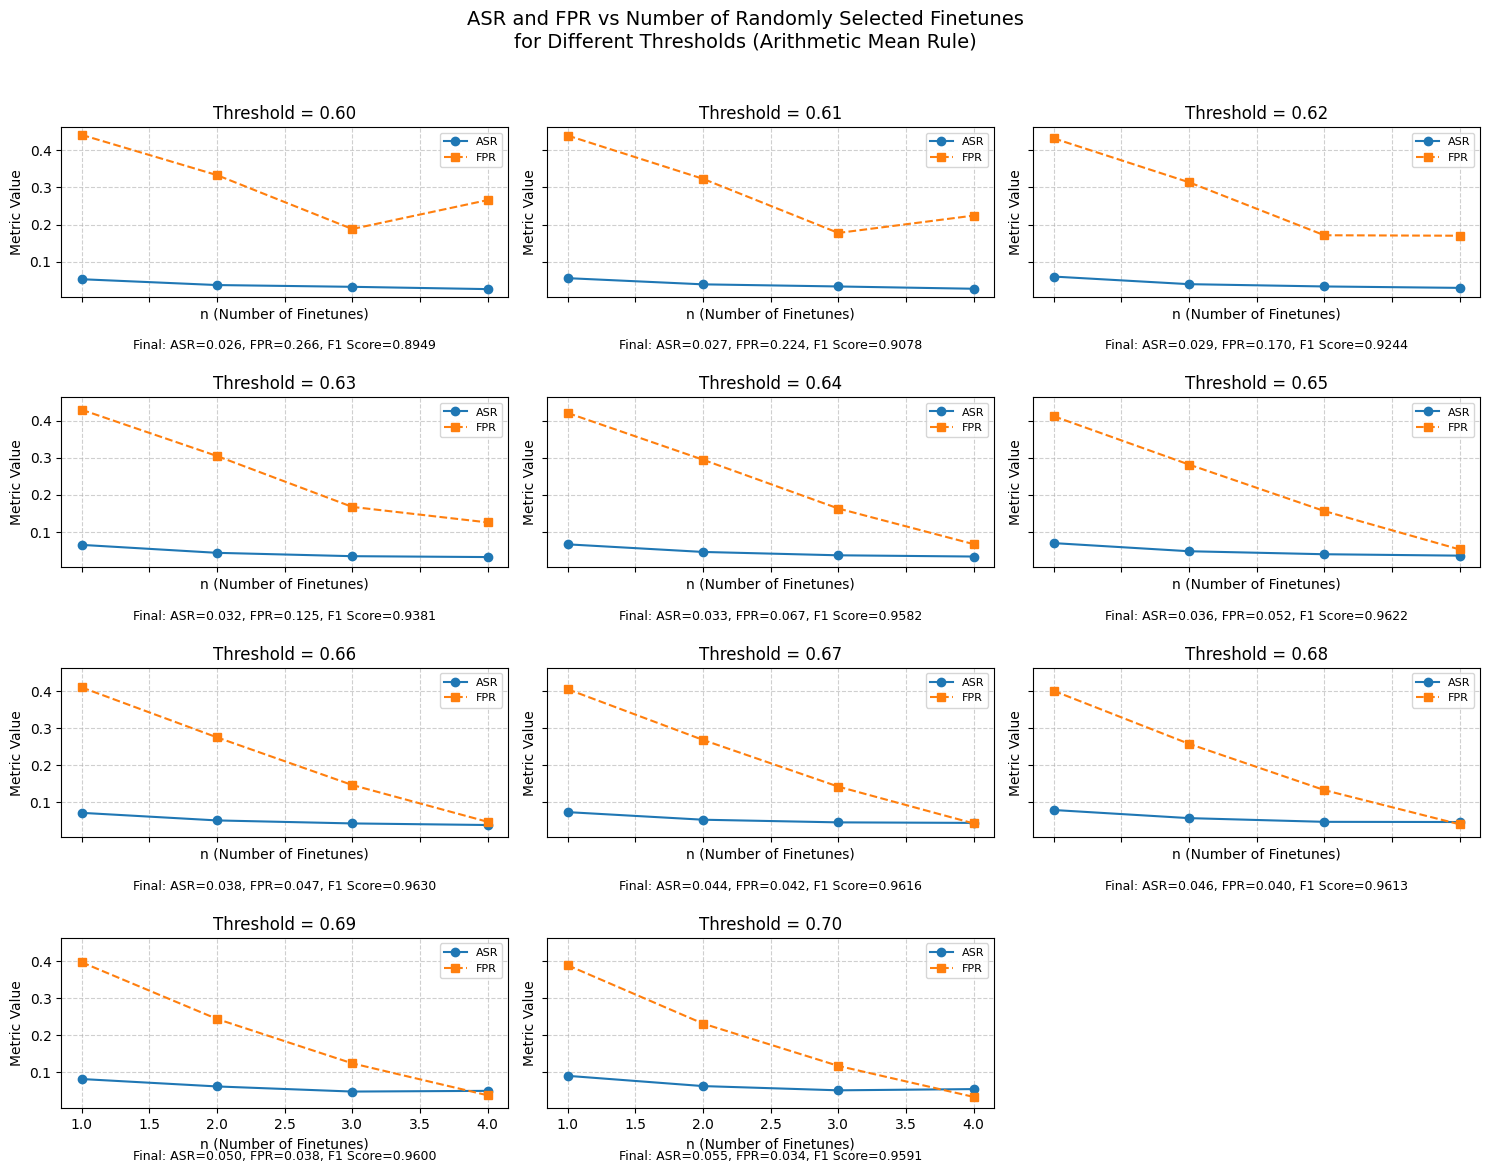

In [ ]:
# Collect finetune model probabilities
finetune_probs = [
    model_1_probs,
    model_2_probs,
    model_3_probs,
    model_4_probs
]

n_models = len(finetune_probs)
n_samples = len(test_labels)
thresholds = np.arange(0.60, 0.71, 0.01)

random.seed(42)
all_results = []

# --- Main loop: n = 1..5, threshold sweep ---
for n in range(1, n_models + 1):
    combined_probs = []
    for i in range(n_samples):
        selected_indices = random.sample(range(n_models), n)
        avg_prob = np.mean([finetune_probs[j][i] for j in selected_indices])
        combined_probs.append(avg_prob)
    combined_probs = np.array(combined_probs)

    for thresh in thresholds:
        preds = [1 if p > thresh else 0 for p in combined_probs]
        metrics = compute_asr_fpr(test_labels, preds)
        f1 = f1_score([int(x) for x in test_labels], preds)
        all_results.append({
            'n': n,
            'threshold': round(thresh, 2),
            'ASR': metrics['ASR'],
            'FPR': metrics['FPR'],
            'F1': f1
        })

results_df = pd.DataFrame(all_results)

# --- Plot: one subplot per threshold, showing both ASR and FPR ---
num_thresholds = len(thresholds)
ncols = 3  # grid layout (3 columns)
nrows = int(np.ceil(num_thresholds / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 3), sharex=True, sharey=True)
axes = axes.flatten()

for idx, thresh in enumerate(thresholds):
    ax = axes[idx]
    subset = results_df[results_df['threshold'] == round(thresh, 2)]

    ax.plot(subset['n'], subset['ASR'], marker='o', label='ASR', color='C0')
    ax.plot(subset['n'], subset['FPR'], marker='s', linestyle='--', label='FPR', color='C1')
    ax.set_title(f'Threshold = {thresh:.2f}')
    ax.set_xlabel('n (Number of Finetunes)')
    ax.set_ylabel('Metric Value')
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(fontsize=8)

    final_row = subset[subset['n'] == len(finetune_probs)].iloc[0]
    final_asr = final_row['ASR']
    final_fpr = final_row['FPR']
    final_f1 = final_row['F1']
    ax.text(
        0.5, -0.25,
        f"Final: ASR={final_asr:.3f}, FPR={final_fpr:.3f}, F1 Score={final_f1:.4f}",
        ha='center', va='top', transform=ax.transAxes, fontsize=9, color='black'
    )

# Hide unused subplots if thresholds don’t fill the grid
for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('ASR and FPR vs Number of Randomly Selected Finetunes\nfor Different Thresholds (Arithmetic Mean Rule)', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


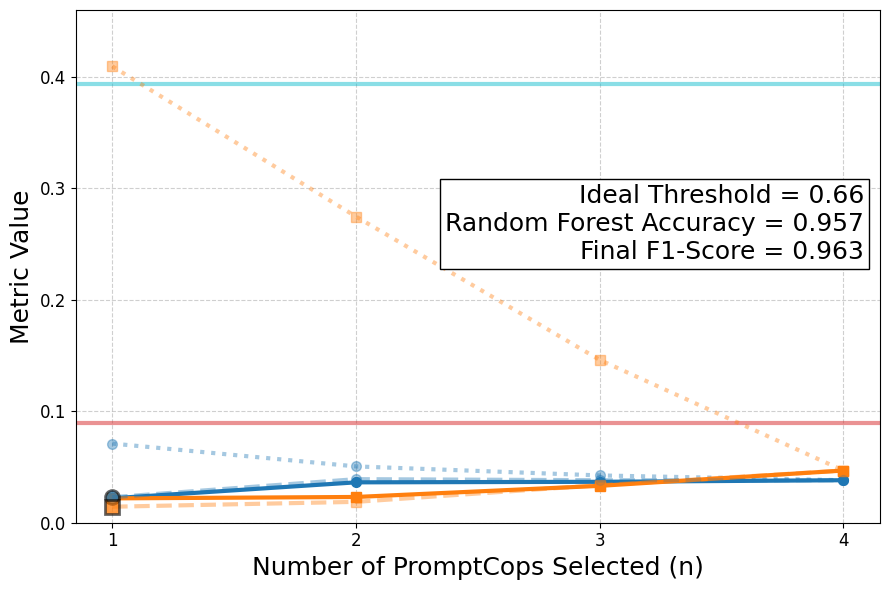

In [ ]:
threshold = 0.66

# Collect all fine-tune model probabilities
finetune_probs = [
    model_1_probs,
    model_2_probs,
    model_3_probs,
    model_4_probs
]

n_models = len(finetune_probs)
n_samples = len(test_labels)
results = []
ideal_results = []
forest_results = []

random.seed(42)  # reproducibility

# --- Baseline (non-finetuned model) ---
baseline_preds = [1 if p > 0.5 else 0 for p in baseline_probs]
baseline_metrics = compute_asr_fpr(test_labels, baseline_preds)
baseline_asr = baseline_metrics['ASR']
baseline_fpr = baseline_metrics['FPR']

# --- Normal random finetune selection for n = 1..5 ---
for n in range(1, n_models + 1):
    combined_probs = []
    for i in range(n_samples):
        selected_indices = random.sample(range(n_models), n)
        avg_prob = np.mean([finetune_probs[j][i] for j in selected_indices])
        combined_probs.append(avg_prob)

    preds = [1 if p > threshold else 0 for p in combined_probs]
    metrics = compute_asr_fpr(test_labels, preds)
    metrics['n'] = n
    results.append(metrics)

# --- Ideal case: always include the best model per sample ---
# best_model_ids is a list of integers from 1 to 5 (same length as test_labels)
for n in range(1, n_models + 1):
    combined_probs = []
    for i in range(n_samples):
        best_model_idx = best_model_ids[i] - 1  # convert 1–5 → 0–4 index

        if n == 1:
            selected_indices = [best_model_idx]
        else:
            # Always include the best model, and select the rest randomly
            other_indices = [idx for idx in range(n_models) if idx != best_model_idx]
            selected_indices = [best_model_idx] + random.sample(other_indices, n - 1)

        avg_prob = np.mean([finetune_probs[j][i] for j in selected_indices])
        combined_probs.append(avg_prob)

    preds = [1 if p > threshold else 0 for p in combined_probs]
    metrics = compute_asr_fpr(test_labels, preds)
    metrics['n'] = n
    ideal_results.append(metrics)


# --- Forest case: always include the random forest model per sample ---
# best_model_ids_forest is a list of integers from 1 to 9 (same length as test_labels)
for n in range(1, n_models + 1):
    combined_probs = []
    for i in range(n_samples):
        best_model_idx = best_model_ids_forest[i] - 1  # convert 1–5 → 0–4 index

        if n == 1:
            selected_indices = [best_model_idx]
        else:
            # Always include the best model, and select the rest randomly
            other_indices = [idx for idx in range(n_models) if idx != best_model_idx]
            selected_indices = [best_model_idx] + random.sample(other_indices, n - 1)

        avg_prob = np.mean([finetune_probs[j][i] for j in selected_indices])
        combined_probs.append(avg_prob)

    preds = [1 if p > threshold else 0 for p in combined_probs]
    metrics = compute_asr_fpr(test_labels, preds)
    metrics['n'] = n
    forest_results.append(metrics)
    forest_final_f1 = f1_score(test_labels, preds)



# --- Extract values for plotting ---
n_values = [r['n'] for r in results]
asr_values = [r['ASR'] for r in results]
fpr_values = [r['FPR'] for r in results]

ideal_asr_values = [r['ASR'] for r in ideal_results]
ideal_fpr_values = [r['FPR'] for r in ideal_results]

forest_asr_values = [r['ASR'] for r in forest_results]
forest_fpr_values = [r['FPR'] for r in forest_results]

# --- Compute final F1 score for the random strategy (at n = ?) ---
# Reconstruct the last (n=?) combined probabilities and predictions
final_combined_probs = []
n_final = n_models
for i in range(n_samples):
    selected_indices = random.sample(range(n_models), n_final)
    avg_prob = np.mean([finetune_probs[j][i] for j in selected_indices])
    final_combined_probs.append(avg_prob)

final_preds = [1 if p > threshold else 0 for p in final_combined_probs]
final_f1 = f1_score(test_labels, final_preds)

# --- Plot ---
plt.figure(figsize=(9, 6))

plt.axhline(y=baseline_asr, color='C9', alpha=0.5, label='Baseline ASR', linewidth=3, markersize=7)
plt.axhline(y=baseline_fpr, color='C3', alpha=0.5, label='Baseline FPR', linewidth=3, markersize=7)
plt.plot(n_values, asr_values, marker='o', linestyle=':', color='C0', alpha=0.4, label='Random Selection ASR', linewidth=3, markersize=7)
plt.plot(n_values, fpr_values, marker='s', linestyle=':', color='C1', alpha=0.4, label='Random Selection FPR', linewidth=3, markersize=7)
plt.plot(n_values, forest_asr_values, marker='o', color='C0', label='ASR (Predicted Expert and n-1 Random Selections)', linewidth=3, markersize=7)
plt.plot(n_values, forest_fpr_values, marker='s', color='C1', label='FPR (Predicted Expert and n-1 Random Selections)', linewidth=3, markersize=7)
plt.plot(n_values, ideal_asr_values, marker='o', linestyle='--', color='C0', alpha=0.4, label='Ideal ASR (Best Expert and n-1 Random Selections)', linewidth=3, markersize=7)
plt.plot(n_values, ideal_fpr_values, marker='s', linestyle='--', color='C1', alpha=0.4, label='Ideal FPR (Best Expert and n-1 Random Selections)', linewidth=3, markersize=7)

plt.plot(
    n_values[0], ideal_asr_values[0],
    marker='o', markersize=10, linestyle='None',
    color='C0', markeredgecolor='black',
    label='Ideal ASR (Best Expert Only)', zorder=5, alpha=0.6, markeredgewidth=2
)

plt.plot(
    n_values[0], ideal_fpr_values[0],
    marker='s', markersize=10, linestyle='None',
    color='C1', markeredgecolor='black',
    label='Ideal FPR (Best Expert Only)', zorder=5, alpha=0.6, markeredgewidth=2
)

textstr = f'Ideal Threshold = {threshold}\nRandom Forest Accuracy = {clf.score(X_test, y_test):.3f}\nFinal F1-Score = {final_f1:.3f}'
plt.text(
    0.98, 0.66, textstr,
    transform=plt.gca().transAxes,
    fontsize=18,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(facecolor="white", alpha=1.0)
)

plt.ylim(0, 0.46)
plt.xlabel('Number of PromptCops Selected (n)', fontsize='18')
plt.ylabel('Metric Value', fontsize='18')
# plt.title(
#     f'(k=4) Performance Across Increasing Selection Size',
#     fontweight='bold',
#     fontsize='19'
# )
plt.grid(True, linestyle='--', alpha=0.6)

plt.tick_params(axis='both', which='major', labelsize=12)
plt.xticks([1, 2, 3, 4])

# leg = plt.legend(loc="upper right", bbox_to_anchor=(0.99, 0.96), borderaxespad=0.0, facecolor="white", fontsize='11')
# for text in leg.get_texts():
#     if text.get_text() == "ASR (Predicted Expert and n-1 Random Selections)" or text.get_text() == "FPR (Predicted Expert and n-1 Random Selections)":
#         text.set_fontstyle('oblique')

plt.tight_layout()
plt.savefig("exp2_4.pdf", bbox_inches="tight")
plt.show()

# Dataset / Finetune 5

## jackhhao/jailbreak-classification

https://huggingface.co/datasets/jackhhao/jailbreak-classification

In [ ]:
# Load and analyze the jailbreak classification dataset
print("Loading jailbreak classification dataset...")
dataset = load_dataset("jackhhao/jailbreak-classification")

# Convert to pandas DataFrames for easier manipulation
train_data = dataset['train']

df = train_data.to_pandas()

In [ ]:
# Convert labels to binary (0 for benign, 1 for jailbreak)
df['label'] = df['type'].map({'benign': 0, 'jailbreak': 1})

train_df, temp_df = train_test_split(df, test_size=0.30, random_state=42)
cal_df, test_df = train_test_split(temp_df, test_size=2/3, random_state=42)
finetuning_df, val_df = train_test_split(train_df, test_size=0.20, random_state=42)

In [ ]:
# Load the Prompt Guard model
prompt_injection_model_name = 'meta-llama/Llama-Prompt-Guard-2-86M'
tokenizer = AutoTokenizer.from_pretrained(prompt_injection_model_name)
model = AutoModelForSequenceClassification.from_pretrained(prompt_injection_model_name)

In [ ]:
print("\n" + "="*50)
print("EVALUATING ORIGINAL MODEL ON VAL SET")
print("="*50)

test_texts = val_df['prompt'].tolist()
test_labels = val_df['label'].tolist()

# Get predictions from original model
test_scores = evaluate_batch(model, tokenizer, test_texts, batch_size=64, positive_label=1, temperature=3.0)

# Convert scores to binary predictions (threshold = 0.5)
test_predictions = [1 if score > 0.5 else 0 for score in test_scores]

# Calculate metrics
metrics = compute_asr_fpr(test_labels, test_predictions)

print(f"Original Model Performance:")
print(metrics)

In [ ]:
# Fine-tune the model
print("\n" + "="*50)
print("FINE-TUNING MODEL")
print("="*50)

model, tokenizer = train_model(model, tokenizer, train_df, batch_size=32, epochs=3, device='cuda')

In [ ]:
print("\n" + "="*50)
print("EVALUATING FINETUNED MODEL ON VAL SET")
print("="*50)

test_texts = val_df['prompt'].tolist()
test_labels = val_df['label'].tolist()

# Get predictions from original model
test_scores = evaluate_batch(model, tokenizer, test_texts, positive_label=1, temperature=3.0)

# Convert scores to binary predictions (threshold = 0.5)
test_predictions = [1 if score > 0.5 else 0 for score in test_scores]

# Calculate metrics
metrics = compute_asr_fpr(test_labels, test_predictions)

print(f"Finetuned Model Performance:")
print(metrics)

In [ ]:
save_dir = MODELS_DIRECTORY + "model_5"
save_model_and_tokenizer(model, tokenizer, save_dir)

In [ ]:
# delete the old model explicitly
del model
gc.collect()
torch.cuda.empty_cache()

In [ ]:
test_df['model'] = 5
combined_df = pd.concat([combined_df, test_df], ignore_index=True)
print("Combined dataset size = ", combined_df.shape[0])
combined_df.head()

In [ ]:
# Save combined dataset for k = 5
combined_df.to_csv(RESULTS_DIRECTORY + "k=5/combined_df.csv", index=False)

## Analysis

In [ ]:
# Load the combined dataset at this point in time
combined_df = pd.read_csv(RESULTS_DIRECTORY + 'k=5/combined_df.csv')

In [ ]:
test_texts = combined_df['prompt'].tolist()
test_labels = combined_df['label'].tolist()
best_model_ids = combined_df['model'].tolist()

In [ ]:
#Baseline Results
prompt_injection_model_name = 'meta-llama/Llama-Prompt-Guard-2-86M'
tokenizer = AutoTokenizer.from_pretrained(prompt_injection_model_name)
model = AutoModelForSequenceClassification.from_pretrained(prompt_injection_model_name)

baseline_probs = evaluate_batch(model, tokenizer, test_texts, positive_label=1, temperature=3.0)

#Model 1 Results
model, tokenizer = load_model_and_tokenizer(MODELS_DIRECTORY + "model_1")

model_1_probs = evaluate_batch(model, tokenizer, test_texts, positive_label=1, temperature=3.0)

#Model 2 Results
model, tokenizer = load_model_and_tokenizer(MODELS_DIRECTORY + "model_2")

model_2_probs = evaluate_batch(model, tokenizer, test_texts, positive_label=1, temperature=3.0)

#Model 3 Results
model, tokenizer = load_model_and_tokenizer(MODELS_DIRECTORY + "model_3")

model_3_probs = evaluate_batch(model, tokenizer, test_texts, positive_label=1, temperature=3.0)

#Model 4 Results
model, tokenizer = load_model_and_tokenizer(MODELS_DIRECTORY + "model_4")

model_4_probs = evaluate_batch(model, tokenizer, test_texts, positive_label=1, temperature=3.0)

#Model 5 Results
model, tokenizer = load_model_and_tokenizer(MODELS_DIRECTORY + "model_5")

model_5_probs = evaluate_batch(model, tokenizer, test_texts, positive_label=1, temperature=3.0)

In [ ]:
with open(RESULTS_DIRECTORY + "k=5/baseline_probs.pkl", "wb") as f:
    pickle.dump(baseline_probs, f)
with open(RESULTS_DIRECTORY + "k=5/model_1_probs.pkl", "wb") as f:
    pickle.dump(model_1_probs, f)
with open(RESULTS_DIRECTORY + "k=5/model_2_probs.pkl", "wb") as f:
    pickle.dump(model_2_probs, f)
with open(RESULTS_DIRECTORY + "k=5/model_3_probs.pkl", "wb") as f:
    pickle.dump(model_3_probs, f)
with open(RESULTS_DIRECTORY + "k=5/model_4_probs.pkl", "wb") as f:
    pickle.dump(model_4_probs, f)
with open(RESULTS_DIRECTORY + "k=5/model_5_probs.pkl", "wb") as f:
    pickle.dump(model_5_probs, f)

In [ ]:
with open(RESULTS_DIRECTORY + "k=5/baseline_probs.pkl", "rb") as f:
    baseline_probs = pickle.load(f)
with open(RESULTS_DIRECTORY + "k=5/model_1_probs.pkl", "rb") as f:
    model_1_probs = pickle.load(f)
with open(RESULTS_DIRECTORY + "k=5/model_2_probs.pkl", "rb") as f:
    model_2_probs = pickle.load(f)
with open(RESULTS_DIRECTORY + "k=5/model_3_probs.pkl", "rb") as f:
    model_3_probs = pickle.load(f)
with open(RESULTS_DIRECTORY + "k=5/model_4_probs.pkl", "rb") as f:
    model_4_probs = pickle.load(f)
with open(RESULTS_DIRECTORY + "k=5/model_5_probs.pkl", "rb") as f:
    model_5_probs = pickle.load(f)

In [ ]:
import pandas as pd
import numpy as np
import re
from collections import Counter
from math import log2

# Function to calculate Shannon entropy of characters
def text_entropy(text):
    if not text:
        return 0
    freq = Counter(text)
    probs = [v / len(text) for v in freq.values()]
    return -sum(p * log2(p) for p in probs)

# Function to check for common code keywords
code_keywords = {'if', 'else', 'while', 'for', 'import', 'def', 'function',
                 'var', 'let', 'const', 'return', 'class', 'script', 'print', 'exec'}

common_english = {'the', 'and', 'you', 'your', 'please', 'what', 'how', 'can', 'do', 'tell'}

def extract_features(df):
    df = df.copy()

    # Basic text cleaning
    df['prompt'] = df['prompt'].astype(str)

    # 1. Prompt length (in words)
    df['prompt_length'] = df['prompt'].apply(lambda x: len(x.split()))

    # 2. Whitespace proportion
    df['whitespace_proportion'] = df['prompt'].apply(lambda x: x.count(' ') / len(x) if len(x) > 0 else 0)

    # 3. Special character proportion
    special_chars = r"[^a-zA-Z0-9\s]"
    df['special_char_proportion'] = df['prompt'].apply(
        lambda x: len(re.findall(special_chars, x)) / len(x) if len(x) > 0 else 0
    )

    # 4. Average word length
    df['avg_word_length'] = df['prompt'].apply(
        lambda x: np.mean([len(w) for w in x.split()]) if len(x.split()) > 0 else 0
    )

    # 5. Digit proportion
    df['digit_proportion'] = df['prompt'].apply(lambda x: sum(c.isdigit() for c in x) / len(x) if len(x) > 0 else 0)

    # 6. Uppercase ratio
    df['uppercase_ratio'] = df['prompt'].apply(lambda x: sum(c.isupper() for c in x) / len(x) if len(x) > 0 else 0)

    # 7. Code keyword proportion
    df['code_keyword_count'] = df['prompt'].apply(
        lambda x: sum(1 for w in re.findall(r'\b\w+\b', x.lower()) if w in code_keywords)
    )

    # 8. Natural language word proportion
    df['nl_word_count'] = df['prompt'].apply(
        lambda x: sum(1 for w in re.findall(r'\b\w+\b', x.lower()) if w in common_english)
    )

    # 9. Character entropy
    df['char_entropy'] = df['prompt'].apply(text_entropy)

    return df

# Example usage:
combined_df = extract_features(combined_df)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X = cal_df.drop(columns=['prompt', 'model', 'label', 'type'])
y = cal_df['model']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = RandomForestClassifier(n_estimators=200, random_state=42)
clf.fit(X_train, y_train)

print("Accuracy:", clf.score(X_test, y_test))

In [ ]:
best_model_ids_forest = clf.predict(X)
print(len(best_model_ids_forest))
print(best_model_ids_forest)

In [ ]:
best_model_ids_forest = best_model_ids_forest.tolist()

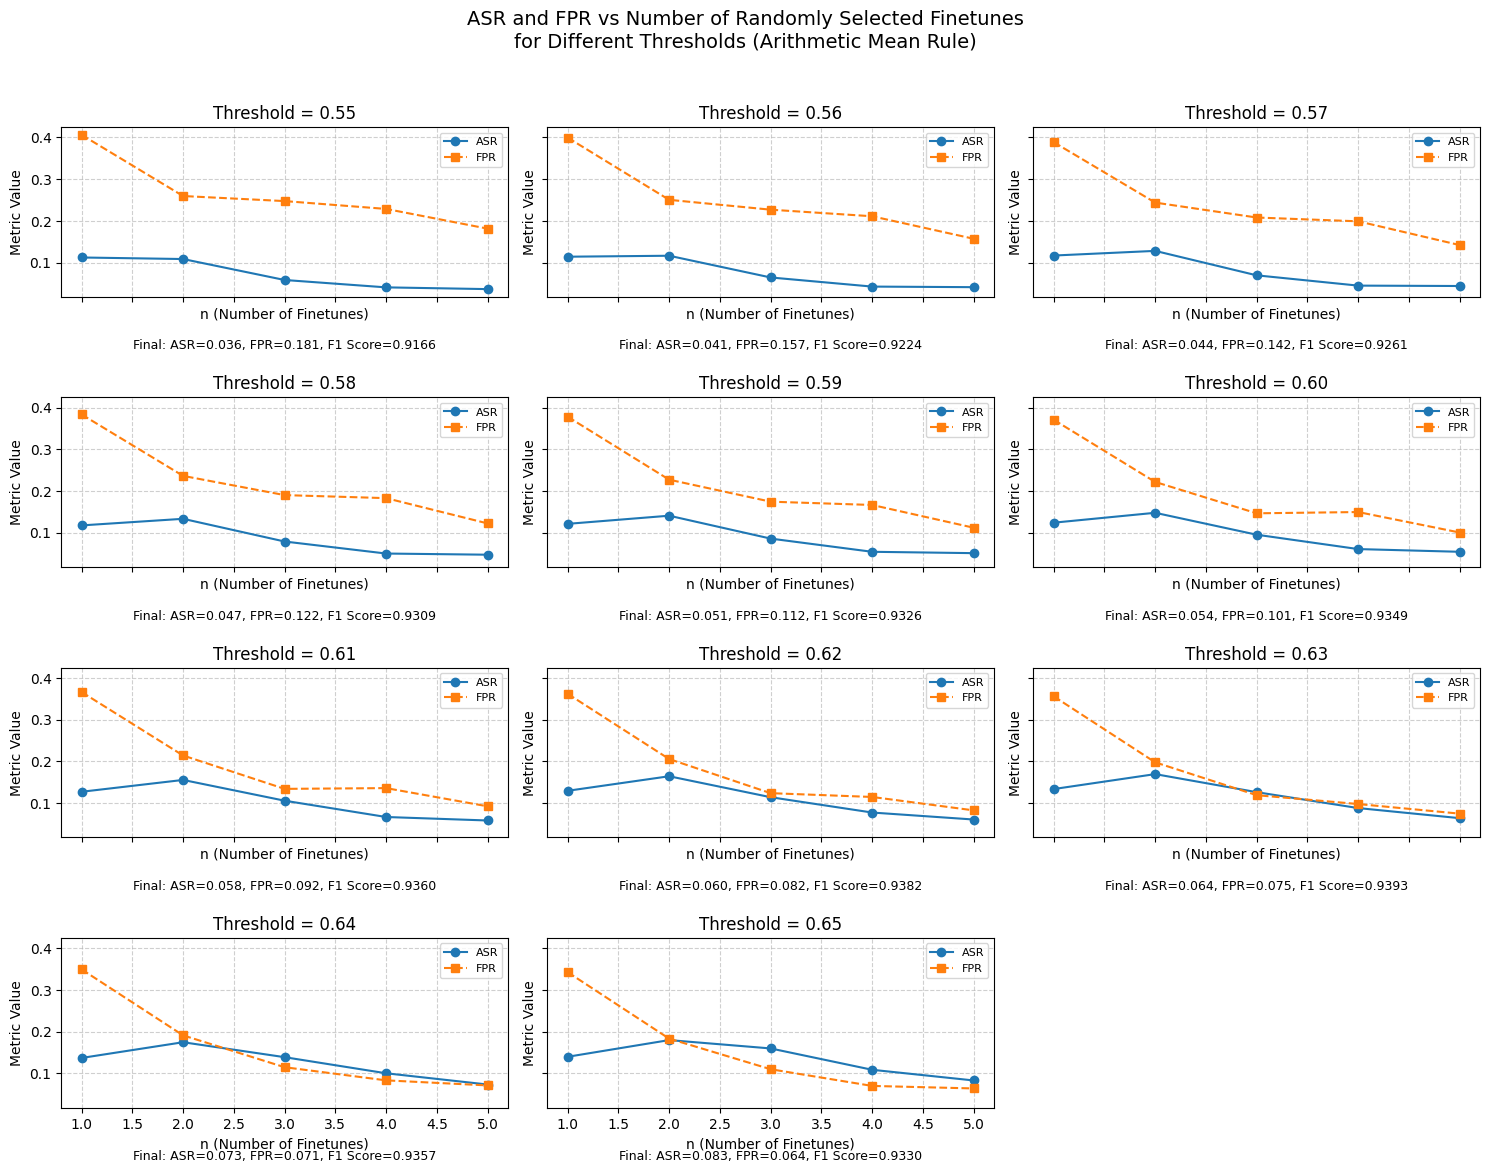

In [ ]:
# Collect finetune model probabilities
finetune_probs = [
    model_1_probs,
    model_2_probs,
    model_3_probs,
    model_4_probs,
    model_5_probs
]

n_models = len(finetune_probs)
n_samples = len(test_labels)
thresholds = np.arange(0.55, 0.66, 0.01)

random.seed(42)
all_results = []

# --- Main loop: n = 1..5, threshold sweep ---
for n in range(1, n_models + 1):
    combined_probs = []
    for i in range(n_samples):
        selected_indices = random.sample(range(n_models), n)
        avg_prob = np.mean([finetune_probs[j][i] for j in selected_indices])
        combined_probs.append(avg_prob)
    combined_probs = np.array(combined_probs)

    for thresh in thresholds:
        preds = [1 if p > thresh else 0 for p in combined_probs]
        metrics = compute_asr_fpr(test_labels, preds)
        f1 = f1_score([int(x) for x in test_labels], preds)
        all_results.append({
            'n': n,
            'threshold': round(thresh, 2),
            'ASR': metrics['ASR'],
            'FPR': metrics['FPR'],
            'F1': f1
        })

results_df = pd.DataFrame(all_results)

# --- Plot: one subplot per threshold, showing both ASR and FPR ---
num_thresholds = len(thresholds)
ncols = 3  # grid layout (3 columns)
nrows = int(np.ceil(num_thresholds / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 3), sharex=True, sharey=True)
axes = axes.flatten()

for idx, thresh in enumerate(thresholds):
    ax = axes[idx]
    subset = results_df[results_df['threshold'] == round(thresh, 2)]

    ax.plot(subset['n'], subset['ASR'], marker='o', label='ASR', color='C0')
    ax.plot(subset['n'], subset['FPR'], marker='s', linestyle='--', label='FPR', color='C1')
    ax.set_title(f'Threshold = {thresh:.2f}')
    ax.set_xlabel('n (Number of Finetunes)')
    ax.set_ylabel('Metric Value')
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(fontsize=8)

    final_row = subset[subset['n'] == len(finetune_probs)].iloc[0]
    final_asr = final_row['ASR']
    final_fpr = final_row['FPR']
    final_f1 = final_row['F1']
    ax.text(
        0.5, -0.25,
        f"Final: ASR={final_asr:.3f}, FPR={final_fpr:.3f}, F1 Score={final_f1:.4f}",
        ha='center', va='top', transform=ax.transAxes, fontsize=9, color='black'
    )

# Hide unused subplots if thresholds don’t fill the grid
for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('ASR and FPR vs Number of Randomly Selected Finetunes\nfor Different Thresholds (Arithmetic Mean Rule)', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

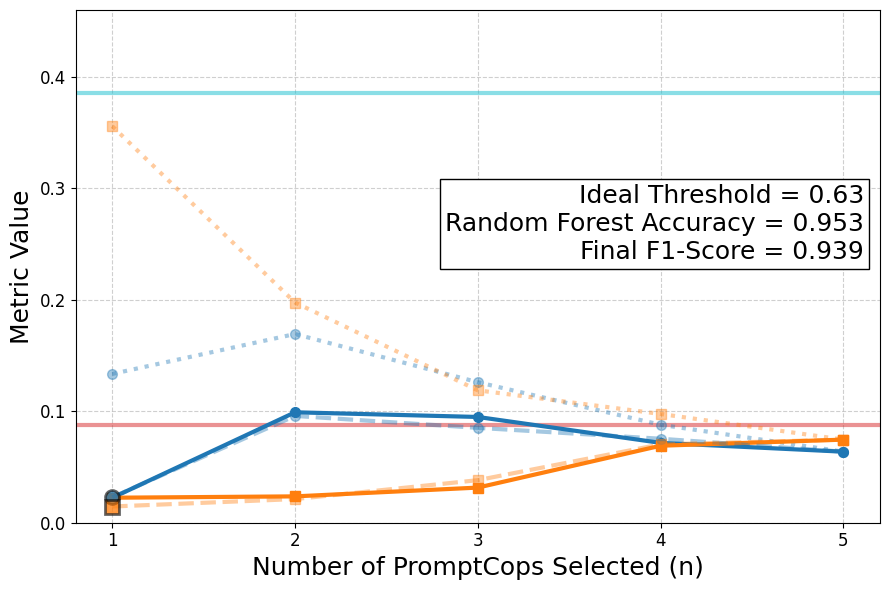

In [ ]:
threshold = 0.63

# Collect all fine-tune model probabilities
finetune_probs = [
    model_1_probs,
    model_2_probs,
    model_3_probs,
    model_4_probs,
    model_5_probs
]

n_models = len(finetune_probs)
n_samples = len(test_labels)
results = []
ideal_results = []
forest_results = []

random.seed(42)  # reproducibility

# --- Baseline (non-finetuned model) ---
baseline_preds = [1 if p > 0.5 else 0 for p in baseline_probs]
baseline_metrics = compute_asr_fpr(test_labels, baseline_preds)
baseline_asr = baseline_metrics['ASR']
baseline_fpr = baseline_metrics['FPR']

# --- Normal random finetune selection for n = 1..5 ---
for n in range(1, n_models + 1):
    combined_probs = []
    for i in range(n_samples):
        selected_indices = random.sample(range(n_models), n)
        avg_prob = np.mean([finetune_probs[j][i] for j in selected_indices])
        combined_probs.append(avg_prob)

    preds = [1 if p > threshold else 0 for p in combined_probs]
    metrics = compute_asr_fpr(test_labels, preds)
    metrics['n'] = n
    results.append(metrics)

# --- Ideal case: always include the best model per sample ---
# best_model_ids is a list of integers from 1 to 5 (same length as test_labels)
for n in range(1, n_models + 1):
    combined_probs = []
    for i in range(n_samples):
        best_model_idx = best_model_ids[i] - 1  # convert 1–5 → 0–4 index

        if n == 1:
            selected_indices = [best_model_idx]
        else:
            # Always include the best model, and select the rest randomly
            other_indices = [idx for idx in range(n_models) if idx != best_model_idx]
            selected_indices = [best_model_idx] + random.sample(other_indices, n - 1)

        avg_prob = np.mean([finetune_probs[j][i] for j in selected_indices])
        combined_probs.append(avg_prob)

    preds = [1 if p > threshold else 0 for p in combined_probs]
    metrics = compute_asr_fpr(test_labels, preds)
    metrics['n'] = n
    ideal_results.append(metrics)


# --- Forest case: always include the random forest model per sample ---
# best_model_ids_forest is a list of integers from 1 to 9 (same length as test_labels)
for n in range(1, n_models + 1):
    combined_probs = []
    for i in range(n_samples):
        best_model_idx = best_model_ids_forest[i] - 1  # convert 1–5 → 0–4 index

        if n == 1:
            selected_indices = [best_model_idx]
        else:
            # Always include the best model, and select the rest randomly
            other_indices = [idx for idx in range(n_models) if idx != best_model_idx]
            selected_indices = [best_model_idx] + random.sample(other_indices, n - 1)

        avg_prob = np.mean([finetune_probs[j][i] for j in selected_indices])
        combined_probs.append(avg_prob)

    preds = [1 if p > threshold else 0 for p in combined_probs]
    metrics = compute_asr_fpr(test_labels, preds)
    metrics['n'] = n
    forest_results.append(metrics)
    forest_final_f1 = f1_score(test_labels, preds)



# --- Extract values for plotting ---
n_values = [r['n'] for r in results]
asr_values = [r['ASR'] for r in results]
fpr_values = [r['FPR'] for r in results]

ideal_asr_values = [r['ASR'] for r in ideal_results]
ideal_fpr_values = [r['FPR'] for r in ideal_results]

forest_asr_values = [r['ASR'] for r in forest_results]
forest_fpr_values = [r['FPR'] for r in forest_results]

# --- Compute final F1 score for the random strategy (at n = ?) ---
# Reconstruct the last (n=?) combined probabilities and predictions
final_combined_probs = []
n_final = n_models
for i in range(n_samples):
    selected_indices = random.sample(range(n_models), n_final)
    avg_prob = np.mean([finetune_probs[j][i] for j in selected_indices])
    final_combined_probs.append(avg_prob)

final_preds = [1 if p > threshold else 0 for p in final_combined_probs]
final_f1 = f1_score(test_labels, final_preds)

# --- Plot ---
plt.figure(figsize=(9, 6))

plt.axhline(y=baseline_asr, color='C9', alpha=0.5, label='Baseline ASR', linewidth=3, markersize=7)
plt.axhline(y=baseline_fpr, color='C3', alpha=0.5, label='Baseline FPR', linewidth=3, markersize=7)
plt.plot(n_values, asr_values, marker='o', linestyle=':', color='C0', alpha=0.4, label='Random Selection ASR', linewidth=3, markersize=7)
plt.plot(n_values, fpr_values, marker='s', linestyle=':', color='C1', alpha=0.4, label='Random Selection FPR', linewidth=3, markersize=7)
plt.plot(n_values, forest_asr_values, marker='o', color='C0', label='ASR (Predicted Expert and n-1 Random Selections)', linewidth=3, markersize=7)
plt.plot(n_values, forest_fpr_values, marker='s', color='C1', label='FPR (Predicted Expert and n-1 Random Selections)', linewidth=3, markersize=7)
plt.plot(n_values, ideal_asr_values, marker='o', linestyle='--', color='C0', alpha=0.4, label='Ideal ASR (Best Expert and n-1 Random Selections)', linewidth=3, markersize=7)
plt.plot(n_values, ideal_fpr_values, marker='s', linestyle='--', color='C1', alpha=0.4, label='Ideal FPR (Best Expert and n-1 Random Selections)', linewidth=3, markersize=7)

plt.plot(
    n_values[0], ideal_asr_values[0],
    marker='o', markersize=10, linestyle='None',
    color='C0', markeredgecolor='black',
    label='Ideal ASR (Best Expert Only)', zorder=5, alpha=0.6, markeredgewidth=2
)

plt.plot(
    n_values[0], ideal_fpr_values[0],
    marker='s', markersize=10, linestyle='None',
    color='C1', markeredgecolor='black',
    label='Ideal FPR (Best Expert Only)', zorder=5, alpha=0.6, markeredgewidth=2
)

textstr = f'Ideal Threshold = {threshold}\nRandom Forest Accuracy = {clf.score(X_test, y_test):.3f}\nFinal F1-Score = {final_f1:.3f}'
plt.text(
    0.98, 0.66, textstr,
    transform=plt.gca().transAxes,
    fontsize=18,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(facecolor="white", alpha=1.0)
)

plt.ylim(0, 0.46)
plt.xlabel('Number of PromptCops Selected (n)', fontsize='18')
plt.ylabel('Metric Value', fontsize='18')
# plt.title(
#     f'(k=5) Performance Across Increasing Selection Size',
#     fontweight='bold',
#     fontsize='19'
# )
plt.grid(True, linestyle='--', alpha=0.6)

plt.tick_params(axis='both', which='major', labelsize=12)
plt.xticks([1, 2, 3, 4, 5])

# leg = plt.legend(loc="upper right", bbox_to_anchor=(0.99, 0.96), borderaxespad=0.0, facecolor="white", fontsize='11')
# for text in leg.get_texts():
#     if text.get_text() == "ASR (Predicted Expert and n-1 Random Selections)" or text.get_text() == "FPR (Predicted Expert and n-1 Random Selections)":
#         text.set_fontstyle('oblique')

plt.tight_layout()
plt.savefig("exp2_5.pdf", bbox_inches="tight")
plt.show()

In [ ]:
print("ASR Values:", asr_values)
print("FPR Values:", fpr_values)
print("Ideal ASR Values:", ideal_asr_values)
print("Ideal FPR Values:", ideal_fpr_values)
print("Forest ASR Values:", forest_asr_values)
print("Forest FPR Values:", forest_fpr_values)

ASR Values: [0.13348837209302322, 0.16930232558139535, 0.12604651162790703, 0.08790697674418602, 0.06372093023255809]
FPR Values: [0.3557575757575758, 0.19757575757575757, 0.11878787878787879, 0.09757575757575758, 0.07454545454545454]
Ideal ASR Values: [0.02279069767441866, 0.09581395348837207, 0.08511627906976749, 0.0753488372093023, 0.06372093023255809]
Ideal FPR Values: [0.014545454545454545, 0.021212121212121213, 0.038181818181818185, 0.0703030303030303, 0.07454545454545454]
Forest ASR Values: [0.022325581395348792, 0.09906976744186047, 0.09488372093023256, 0.07162790697674415, 0.06372093023255809]
Forest FPR Values: [0.022424242424242423, 0.023636363636363636, 0.03151515151515152, 0.06909090909090909, 0.07454545454545454]


# Dataset / Finetune 6

## qualifire/prompt-injections-benchmark

https://huggingface.co/datasets/qualifire/prompt-injections-benchmark

In [ ]:
# Load and analyze the  dataset
dataset = load_dataset("qualifire/prompt-injections-benchmark")
dataset = dataset['test'].to_pandas()
dataset = dataset.rename(columns={'text': 'prompt'})

dataset['label'] = dataset['label'].map({'benign': 0, 'jailbreak': 1})

train_df, temp_df = train_test_split(dataset, test_size=0.30, random_state=42, stratify=dataset['label'])
cal_df, test_df = train_test_split(temp_df, test_size=2/3, random_state=42)
finetuning_df, val_df = train_test_split(train_df, test_size=0.20, random_state=42)

In [ ]:
# Load the Prompt Guard model
prompt_injection_model_name = 'meta-llama/Llama-Prompt-Guard-2-86M'
tokenizer = AutoTokenizer.from_pretrained(prompt_injection_model_name)
model = AutoModelForSequenceClassification.from_pretrained(prompt_injection_model_name)

In [ ]:
print("\n" + "="*50)
print("EVALUATING ORIGINAL MODEL ON VAL SET")
print("="*50)

test_texts = val_df['prompt'].tolist()
test_labels = val_df['label'].tolist()

# Get predictions from original model
test_scores = evaluate_batch(model, tokenizer, test_texts, batch_size=64, positive_label=1, temperature=3.0)

# Convert scores to binary predictions (threshold = 0.5)
test_predictions = [1 if score > 0.5 else 0 for score in test_scores]

# Calculate metrics
metrics = compute_asr_fpr(test_labels, test_predictions)

print(f"Original Model Performance:")
print(metrics)

In [ ]:
# Fine-tune the model
print("\n" + "="*50)
print("FINE-TUNING MODEL")
print("="*50)

model, tokenizer = train_model(model, tokenizer, train_df, batch_size=32, epochs=3, device='cuda')

In [ ]:
print("\n" + "="*50)
print("EVALUATING FINETUNED MODEL ON VAL SET")
print("="*50)

test_texts = val_df['prompt'].tolist()
test_labels = val_df['label'].tolist()

# Get predictions from original model
test_scores = evaluate_batch(model, tokenizer, test_texts, positive_label=1, temperature=3.0)

# Convert scores to binary predictions (threshold = 0.5)
test_predictions = [1 if score > 0.5 else 0 for score in test_scores]

# Calculate metrics
metrics = compute_asr_fpr(test_labels, test_predictions)

print(f"Finetuned Model Performance:")
print(metrics)

In [ ]:
save_dir = MODELS_DIRECTORY + "model_6"
save_model_and_tokenizer(model, tokenizer, save_dir)

In [ ]:
# delete the old model explicitly
del model
gc.collect()
torch.cuda.empty_cache()

In [ ]:
test_df['model'] = 6
combined_df = pd.concat([combined_df, test_df], ignore_index=True)
print("Combined dataset size = ", combined_df.shape[0])
combined_df.head()

In [ ]:
# Save combined dataset for k = 6
combined_df.to_csv(RESULTS_DIRECTORY + "k=6/combined_df.csv", index=False)

## Analysis

In [ ]:
# Load the combined dataset at this point in time
combined_df = pd.read_csv(RESULTS_DIRECTORY + 'k=6/combined_df.csv')

In [ ]:
test_texts = combined_df['prompt'].tolist()
test_labels = combined_df['label'].tolist()
best_model_ids = combined_df['model'].tolist()

In [ ]:
#Baseline Results
prompt_injection_model_name = 'meta-llama/Llama-Prompt-Guard-2-86M'
tokenizer = AutoTokenizer.from_pretrained(prompt_injection_model_name)
model = AutoModelForSequenceClassification.from_pretrained(prompt_injection_model_name)

baseline_probs = evaluate_batch(model, tokenizer, test_texts, positive_label=1, temperature=3.0)

#Model 1 Results
model, tokenizer = load_model_and_tokenizer(MODELS_DIRECTORY + "model_1")

model_1_probs = evaluate_batch(model, tokenizer, test_texts, positive_label=1, temperature=3.0)

#Model 2 Results
model, tokenizer = load_model_and_tokenizer(MODELS_DIRECTORY + "model_2")

model_2_probs = evaluate_batch(model, tokenizer, test_texts, positive_label=1, temperature=3.0)

#Model 3 Results
model, tokenizer = load_model_and_tokenizer(MODELS_DIRECTORY + "model_3")

model_3_probs = evaluate_batch(model, tokenizer, test_texts, positive_label=1, temperature=3.0)

#Model 4 Results
model, tokenizer = load_model_and_tokenizer(MODELS_DIRECTORY + "model_4")

model_4_probs = evaluate_batch(model, tokenizer, test_texts, positive_label=1, temperature=3.0)

#Model 5 Results
model, tokenizer = load_model_and_tokenizer(MODELS_DIRECTORY + "model_5")

model_5_probs = evaluate_batch(model, tokenizer, test_texts, positive_label=1, temperature=3.0)

#Model 6 Results
model, tokenizer = load_model_and_tokenizer(MODELS_DIRECTORY + "model_6")

model_6_probs = evaluate_batch(model, tokenizer, test_texts, positive_label=1, temperature=3.0)

In [ ]:
with open(RESULTS_DIRECTORY + "k=6/baseline_probs.pkl", "wb") as f:
    pickle.dump(baseline_probs, f)
with open(RESULTS_DIRECTORY + "k=6/model_1_probs.pkl", "wb") as f:
    pickle.dump(model_1_probs, f)
with open(RESULTS_DIRECTORY + "k=6/model_2_probs.pkl", "wb") as f:
    pickle.dump(model_2_probs, f)
with open(RESULTS_DIRECTORY + "k=6/model_3_probs.pkl", "wb") as f:
    pickle.dump(model_3_probs, f)
with open(RESULTS_DIRECTORY + "k=6/model_4_probs.pkl", "wb") as f:
    pickle.dump(model_4_probs, f)
with open(RESULTS_DIRECTORY + "k=6/model_5_probs.pkl", "wb") as f:
    pickle.dump(model_5_probs, f)
with open(RESULTS_DIRECTORY + "k=6/model_6_probs.pkl", "wb") as f:
    pickle.dump(model_6_probs, f)

In [ ]:
with open(RESULTS_DIRECTORY + "k=6/baseline_probs.pkl", "rb") as f:
    baseline_probs = pickle.load(f)
with open(RESULTS_DIRECTORY + "k=6/model_1_probs.pkl", "rb") as f:
    model_1_probs = pickle.load(f)
with open(RESULTS_DIRECTORY + "k=6/model_2_probs.pkl", "rb") as f:
    model_2_probs = pickle.load(f)
with open(RESULTS_DIRECTORY + "k=6/model_3_probs.pkl", "rb") as f:
    model_3_probs = pickle.load(f)
with open(RESULTS_DIRECTORY + "k=6/model_4_probs.pkl", "rb") as f:
    model_4_probs = pickle.load(f)
with open(RESULTS_DIRECTORY + "k=6/model_5_probs.pkl", "rb") as f:
    model_5_probs = pickle.load(f)
with open(RESULTS_DIRECTORY + "k=6/model_6_probs.pkl", "rb") as f:
    model_6_probs = pickle.load(f)

In [ ]:
import pandas as pd
import numpy as np
import re
from collections import Counter
from math import log2

# Function to calculate Shannon entropy of characters
def text_entropy(text):
    if not text:
        return 0
    freq = Counter(text)
    probs = [v / len(text) for v in freq.values()]
    return -sum(p * log2(p) for p in probs)

# Function to check for common code keywords
code_keywords = {'if', 'else', 'while', 'for', 'import', 'def', 'function',
                 'var', 'let', 'const', 'return', 'class', 'script', 'print', 'exec'}

common_english = {'the', 'and', 'you', 'your', 'please', 'what', 'how', 'can', 'do', 'tell'}

def extract_features(df):
    df = df.copy()

    # Basic text cleaning
    df['prompt'] = df['prompt'].astype(str)

    # 1. Prompt length (in words)
    df['prompt_length'] = df['prompt'].apply(lambda x: len(x.split()))

    # 2. Whitespace proportion
    df['whitespace_proportion'] = df['prompt'].apply(lambda x: x.count(' ') / len(x) if len(x) > 0 else 0)

    # 3. Special character proportion
    special_chars = r"[^a-zA-Z0-9\s]"
    df['special_char_proportion'] = df['prompt'].apply(
        lambda x: len(re.findall(special_chars, x)) / len(x) if len(x) > 0 else 0
    )

    # 4. Average word length
    df['avg_word_length'] = df['prompt'].apply(
        lambda x: np.mean([len(w) for w in x.split()]) if len(x.split()) > 0 else 0
    )

    # 5. Digit proportion
    df['digit_proportion'] = df['prompt'].apply(lambda x: sum(c.isdigit() for c in x) / len(x) if len(x) > 0 else 0)

    # 6. Uppercase ratio
    df['uppercase_ratio'] = df['prompt'].apply(lambda x: sum(c.isupper() for c in x) / len(x) if len(x) > 0 else 0)

    # 7. Code keyword proportion
    df['code_keyword_count'] = df['prompt'].apply(
        lambda x: sum(1 for w in re.findall(r'\b\w+\b', x.lower()) if w in code_keywords)
    )

    # 8. Natural language word proportion
    df['nl_word_count'] = df['prompt'].apply(
        lambda x: sum(1 for w in re.findall(r'\b\w+\b', x.lower()) if w in common_english)
    )

    # 9. Character entropy
    df['char_entropy'] = df['prompt'].apply(text_entropy)

    return df

# Example usage:
combined_df = extract_features(combined_df)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X = cal_df.drop(columns=['prompt', 'model', 'label', 'type'])
y = cal_df['model']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = RandomForestClassifier(n_estimators=200, random_state=42)
clf.fit(X_train, y_train)

print("Accuracy:", clf.score(X_test, y_test))

In [ ]:
best_model_ids_forest = clf.predict(X)
print(len(best_model_ids_forest))
print(best_model_ids_forest)

In [ ]:
best_model_ids_forest = best_model_ids_forest.tolist()

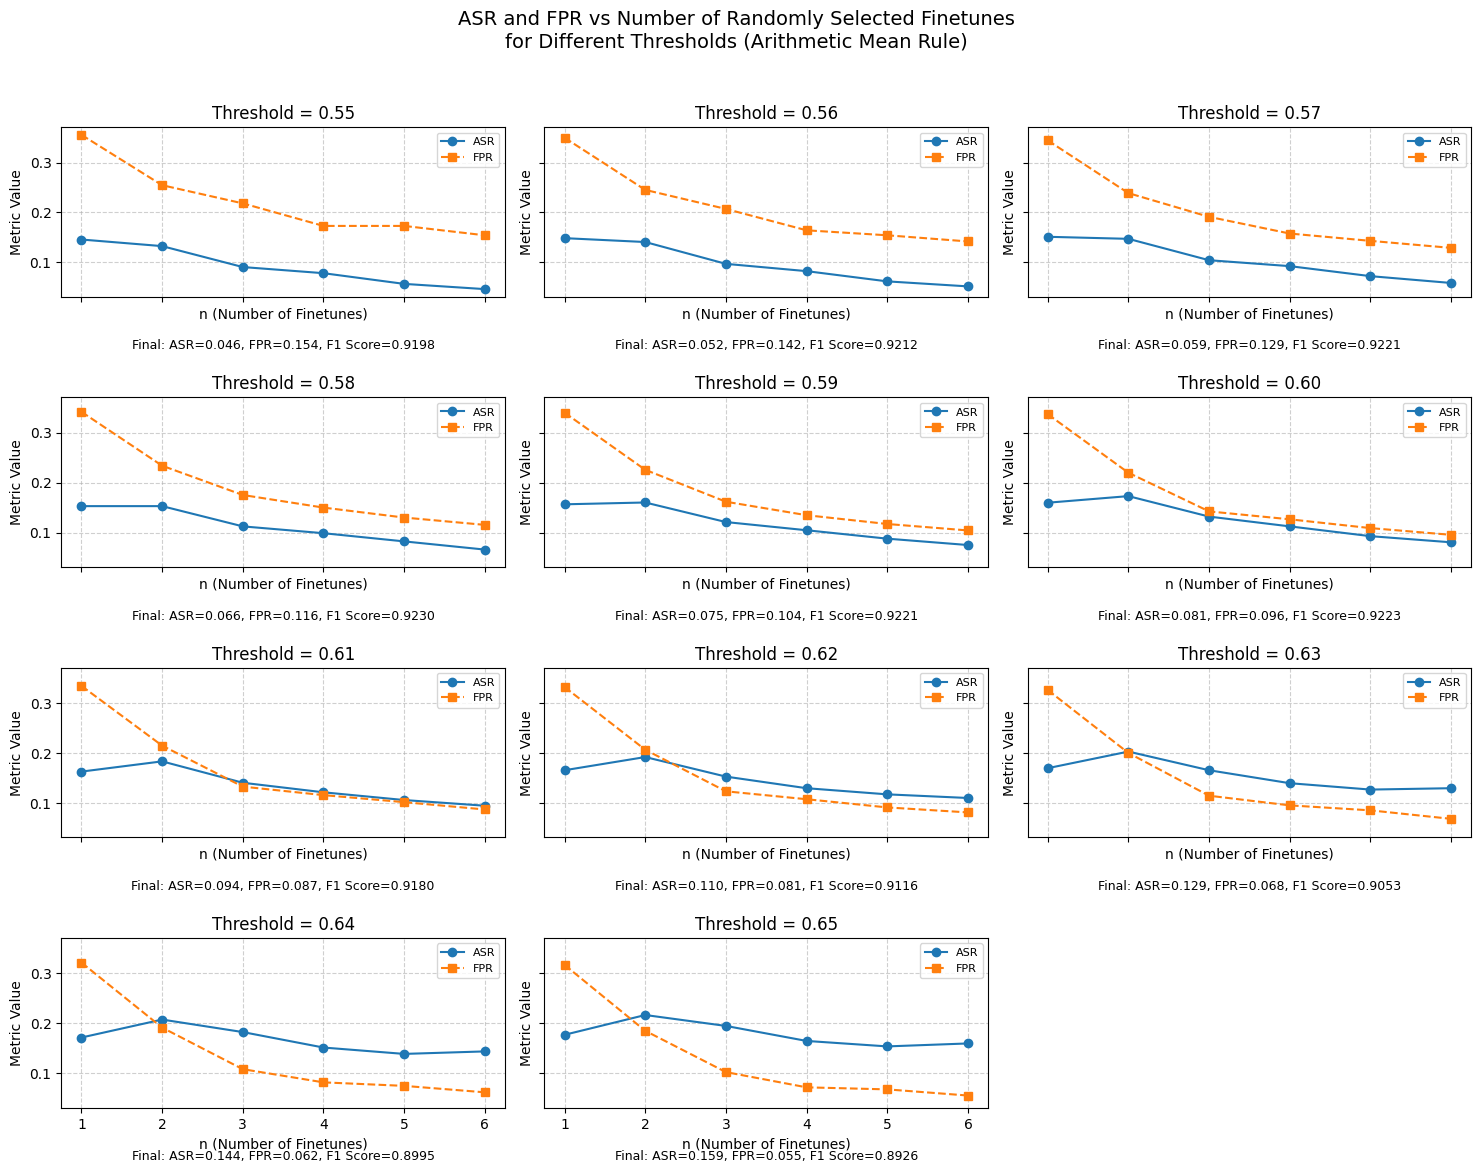

In [ ]:
# Collect finetune model probabilities
finetune_probs = [
    model_1_probs,
    model_2_probs,
    model_3_probs,
    model_4_probs,
    model_5_probs,
    model_6_probs
]

n_models = len(finetune_probs)
n_samples = len(test_labels)
thresholds = np.arange(0.55, 0.66, 0.01)

random.seed(42)
all_results = []

# --- Main loop: n = 1..5, threshold sweep ---
for n in range(1, n_models + 1):
    combined_probs = []
    for i in range(n_samples):
        selected_indices = random.sample(range(n_models), n)
        avg_prob = np.mean([finetune_probs[j][i] for j in selected_indices])
        combined_probs.append(avg_prob)
    combined_probs = np.array(combined_probs)

    for thresh in thresholds:
        preds = [1 if p > thresh else 0 for p in combined_probs]
        metrics = compute_asr_fpr(test_labels, preds)
        f1 = f1_score([int(x) for x in test_labels], preds)
        all_results.append({
            'n': n,
            'threshold': round(thresh, 2),
            'ASR': metrics['ASR'],
            'FPR': metrics['FPR'],
            'F1': f1
        })

results_df = pd.DataFrame(all_results)

# --- Plot: one subplot per threshold, showing both ASR and FPR ---
num_thresholds = len(thresholds)
ncols = 3  # grid layout (3 columns)
nrows = int(np.ceil(num_thresholds / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 3), sharex=True, sharey=True)
axes = axes.flatten()

for idx, thresh in enumerate(thresholds):
    ax = axes[idx]
    subset = results_df[results_df['threshold'] == round(thresh, 2)]

    ax.plot(subset['n'], subset['ASR'], marker='o', label='ASR', color='C0')
    ax.plot(subset['n'], subset['FPR'], marker='s', linestyle='--', label='FPR', color='C1')
    ax.set_title(f'Threshold = {thresh:.2f}')
    ax.set_xlabel('n (Number of Finetunes)')
    ax.set_ylabel('Metric Value')
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(fontsize=8)

    final_row = subset[subset['n'] == len(finetune_probs)].iloc[0]
    final_asr = final_row['ASR']
    final_fpr = final_row['FPR']
    final_f1 = final_row['F1']
    ax.text(
        0.5, -0.25,
        f"Final: ASR={final_asr:.3f}, FPR={final_fpr:.3f}, F1 Score={final_f1:.4f}",
        ha='center', va='top', transform=ax.transAxes, fontsize=9, color='black'
    )

# Hide unused subplots if thresholds don’t fill the grid
for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('ASR and FPR vs Number of Randomly Selected Finetunes\nfor Different Thresholds (Arithmetic Mean Rule)', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

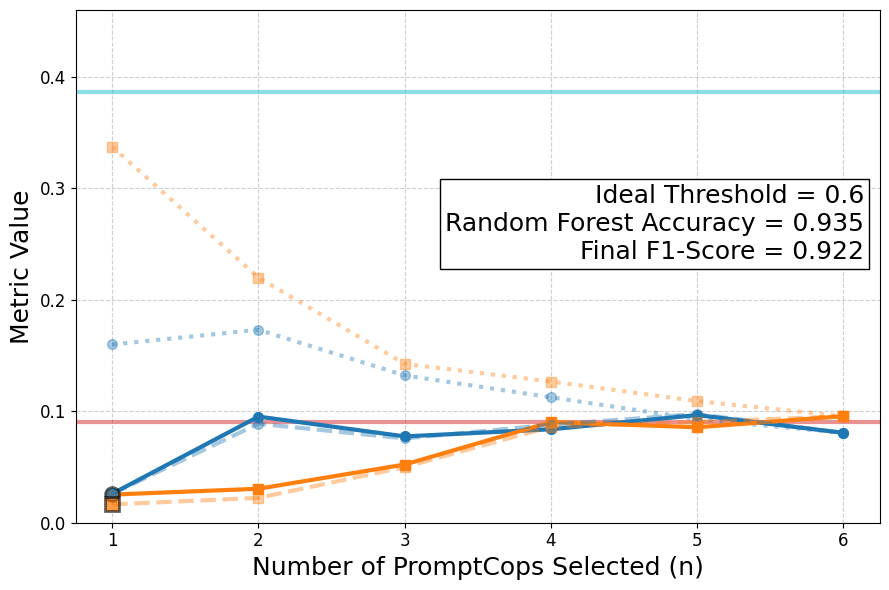

In [ ]:
threshold = 0.60

# Collect all fine-tune model probabilities
finetune_probs = [
    model_1_probs,
    model_2_probs,
    model_3_probs,
    model_4_probs,
    model_5_probs,
    model_6_probs
]

n_models = len(finetune_probs)
n_samples = len(test_labels)
results = []
ideal_results = []
forest_results = []

random.seed(42)  # reproducibility

# --- Baseline (non-finetuned model) ---
baseline_preds = [1 if p > 0.5 else 0 for p in baseline_probs]
baseline_metrics = compute_asr_fpr(test_labels, baseline_preds)
baseline_asr = baseline_metrics['ASR']
baseline_fpr = baseline_metrics['FPR']

# --- Normal random finetune selection for n = 1..5 ---
for n in range(1, n_models + 1):
    combined_probs = []
    for i in range(n_samples):
        selected_indices = random.sample(range(n_models), n)
        avg_prob = np.mean([finetune_probs[j][i] for j in selected_indices])
        combined_probs.append(avg_prob)

    preds = [1 if p > threshold else 0 for p in combined_probs]
    metrics = compute_asr_fpr(test_labels, preds)
    metrics['n'] = n
    results.append(metrics)

# --- Ideal case: always include the best model per sample ---
# best_model_ids is a list of integers from 1 to 5 (same length as test_labels)
for n in range(1, n_models + 1):
    combined_probs = []
    for i in range(n_samples):
        best_model_idx = best_model_ids[i] - 1  # convert 1–5 → 0–4 index

        if n == 1:
            selected_indices = [best_model_idx]
        else:
            # Always include the best model, and select the rest randomly
            other_indices = [idx for idx in range(n_models) if idx != best_model_idx]
            selected_indices = [best_model_idx] + random.sample(other_indices, n - 1)

        avg_prob = np.mean([finetune_probs[j][i] for j in selected_indices])
        combined_probs.append(avg_prob)

    preds = [1 if p > threshold else 0 for p in combined_probs]
    metrics = compute_asr_fpr(test_labels, preds)
    metrics['n'] = n
    ideal_results.append(metrics)


# --- Forest case: always include the random forest model per sample ---
# best_model_ids_forest is a list of integers from 1 to 9 (same length as test_labels)
for n in range(1, n_models + 1):
    combined_probs = []
    for i in range(n_samples):
        best_model_idx = best_model_ids_forest[i] - 1  # convert 1–5 → 0–4 index

        if n == 1:
            selected_indices = [best_model_idx]
        else:
            # Always include the best model, and select the rest randomly
            other_indices = [idx for idx in range(n_models) if idx != best_model_idx]
            selected_indices = [best_model_idx] + random.sample(other_indices, n - 1)

        avg_prob = np.mean([finetune_probs[j][i] for j in selected_indices])
        combined_probs.append(avg_prob)

    preds = [1 if p > threshold else 0 for p in combined_probs]
    metrics = compute_asr_fpr(test_labels, preds)
    metrics['n'] = n
    forest_results.append(metrics)
    forest_final_f1 = f1_score(test_labels, preds)



# --- Extract values for plotting ---
n_values = [r['n'] for r in results]
asr_values = [r['ASR'] for r in results]
fpr_values = [r['FPR'] for r in results]

ideal_asr_values = [r['ASR'] for r in ideal_results]
ideal_fpr_values = [r['FPR'] for r in ideal_results]

forest_asr_values = [r['ASR'] for r in forest_results]
forest_fpr_values = [r['FPR'] for r in forest_results]

# --- Compute final F1 score for the random strategy (at n = ?) ---
# Reconstruct the last (n=?) combined probabilities and predictions
final_combined_probs = []
n_final = n_models
for i in range(n_samples):
    selected_indices = random.sample(range(n_models), n_final)
    avg_prob = np.mean([finetune_probs[j][i] for j in selected_indices])
    final_combined_probs.append(avg_prob)

final_preds = [1 if p > threshold else 0 for p in final_combined_probs]
final_f1 = f1_score(test_labels, final_preds)

# --- Plot ---
plt.figure(figsize=(9, 6))

plt.axhline(y=baseline_asr, color='C9', alpha=0.5, label='Baseline ASR', linewidth=3, markersize=7)
plt.axhline(y=baseline_fpr, color='C3', alpha=0.5, label='Baseline FPR', linewidth=3, markersize=7)
plt.plot(n_values, asr_values, marker='o', linestyle=':', color='C0', alpha=0.4, label='Random Selection ASR', linewidth=3, markersize=7)
plt.plot(n_values, fpr_values, marker='s', linestyle=':', color='C1', alpha=0.4, label='Random Selection FPR', linewidth=3, markersize=7)
plt.plot(n_values, forest_asr_values, marker='o', color='C0', label='ASR (Predicted Expert and n-1 Random Selections)', linewidth=3, markersize=7)
plt.plot(n_values, forest_fpr_values, marker='s', color='C1', label='FPR (Predicted Expert and n-1 Random Selections)', linewidth=3, markersize=7)
plt.plot(n_values, ideal_asr_values, marker='o', linestyle='--', color='C0', alpha=0.4, label='Ideal ASR (Best Expert and n-1 Random Selections)', linewidth=3, markersize=7)
plt.plot(n_values, ideal_fpr_values, marker='s', linestyle='--', color='C1', alpha=0.4, label='Ideal FPR (Best Expert and n-1 Random Selections)', linewidth=3, markersize=7)

plt.plot(
    n_values[0], ideal_asr_values[0],
    marker='o', markersize=10, linestyle='None',
    color='C0', markeredgecolor='black',
    label='Ideal ASR (Best Expert Only)', zorder=5, alpha=0.6, markeredgewidth=2
)

plt.plot(
    n_values[0], ideal_fpr_values[0],
    marker='s', markersize=10, linestyle='None',
    color='C1', markeredgecolor='black',
    label='Ideal FPR (Best Expert Only)', zorder=5, alpha=0.6, markeredgewidth=2
)

textstr = f'Ideal Threshold = {threshold}\nRandom Forest Accuracy = {clf.score(X_test, y_test):.3f}\nFinal F1-Score = {final_f1:.3f}'
plt.text(
    0.98, 0.66, textstr,
    transform=plt.gca().transAxes,
    fontsize=18,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(facecolor="white", alpha=1.0)
)

plt.ylim(0, 0.46)
plt.xlabel('Number of PromptCops Selected (n)', fontsize='18')
plt.ylabel('Metric Value', fontsize='18')
# plt.title(
#     f'(k=6) Performance Across Increasing Selection Size',
#     fontweight='bold',
#     fontsize='19'
# )
plt.grid(True, linestyle='--', alpha=0.6)

plt.tick_params(axis='both', which='major', labelsize=12)

# leg = plt.legend(loc="upper right", bbox_to_anchor=(0.99, 0.96), borderaxespad=0.0, facecolor="white", fontsize='11')
# for text in leg.get_texts():
#     if text.get_text() == "ASR (Predicted Expert and n-1 Random Selections)" or text.get_text() == "FPR (Predicted Expert and n-1 Random Selections)":
#         text.set_fontstyle('oblique')

plt.tight_layout()
plt.savefig("exp2_6.pdf", bbox_inches="tight")
plt.show()

# Dataset / Finetune 7

## jayavibhav/prompt-injection-safety

https://huggingface.co/datasets/jayavibhav/prompt-injection-safety

In [ ]:
# Load and analyze the  dataset
dataset = load_dataset("jayavibhav/prompt-injection-safety")
dataset = dataset['test'].to_pandas()
dataset = dataset.rename(columns={'text': 'prompt'})

dataset['label'] = dataset['label'].map({'benign': 0, 'jailbreak': 1})

train_df, temp_df = train_test_split(dataset, test_size=0.30, random_state=42, stratify=dataset['label'])
cal_df, test_df = train_test_split(temp_df, test_size=2/3, random_state=42)
finetuning_df, val_df = train_test_split(train_df, test_size=0.20, random_state=42)

In [ ]:
# Load the Prompt Guard model
prompt_injection_model_name = 'meta-llama/Llama-Prompt-Guard-2-86M'
tokenizer = AutoTokenizer.from_pretrained(prompt_injection_model_name)
model = AutoModelForSequenceClassification.from_pretrained(prompt_injection_model_name)

In [ ]:
print("\n" + "="*50)
print("EVALUATING ORIGINAL MODEL ON VAL SET")
print("="*50)

test_texts = val_df['prompt'].tolist()
test_labels = val_df['label'].tolist()

# Get predictions from original model
test_scores = evaluate_batch(model, tokenizer, test_texts, batch_size=64, positive_label=1, temperature=3.0)

# Convert scores to binary predictions (threshold = 0.5)
test_predictions = [1 if score > 0.5 else 0 for score in test_scores]

# Calculate metrics
metrics = compute_asr_fpr(test_labels, test_predictions)

print(f"Original Model Performance:")
print(metrics)

In [ ]:
# Fine-tune the model
print("\n" + "="*50)
print("FINE-TUNING MODEL")
print("="*50)

model, tokenizer = train_model(model, tokenizer, train_df, batch_size=32, epochs=3, device='cuda')

In [ ]:
print("\n" + "="*50)
print("EVALUATING FINETUNED MODEL ON VAL SET")
print("="*50)

test_texts = val_df['prompt'].tolist()
test_labels = val_df['label'].tolist()

# Get predictions from original model
test_scores = evaluate_batch(model, tokenizer, test_texts, positive_label=1, temperature=3.0)

# Convert scores to binary predictions (threshold = 0.5)
test_predictions = [1 if score > 0.5 else 0 for score in test_scores]

# Calculate metrics
metrics = compute_asr_fpr(test_labels, test_predictions)

print(f"Finetuned Model Performance:")
print(metrics)

In [ ]:
save_dir = MODELS_DIRECTORY + "model_7"
save_model_and_tokenizer(model, tokenizer, save_dir)

In [ ]:
# delete the old model explicitly
del model
gc.collect()
torch.cuda.empty_cache()

In [ ]:
test_df['model'] = 7
combined_df = pd.concat([combined_df, test_df], ignore_index=True)
print("Combined dataset size = ", combined_df.shape[0])
combined_df.head()

In [ ]:
# Save combined dataset for k = 7
combined_df.to_csv(RESULTS_DIRECTORY + "k=7/combined_df.csv", index=False)

## Analysis

In [ ]:
# Load the combined dataset at this point in time
combined_df = pd.read_csv(RESULTS_DIRECTORY + 'k=7/combined_df.csv')

In [ ]:
test_texts = combined_df['prompt'].tolist()
test_labels = combined_df['label'].tolist()
best_model_ids = combined_df['model'].tolist()

In [ ]:
#Baseline Results
prompt_injection_model_name = 'meta-llama/Llama-Prompt-Guard-2-86M'
tokenizer = AutoTokenizer.from_pretrained(prompt_injection_model_name)
model = AutoModelForSequenceClassification.from_pretrained(prompt_injection_model_name)

baseline_probs = evaluate_batch(model, tokenizer, test_texts, positive_label=1, temperature=3.0)

#Model 1 Results
model, tokenizer = load_model_and_tokenizer(MODELS_DIRECTORY + "model_1")

model_1_probs = evaluate_batch(model, tokenizer, test_texts, positive_label=1, temperature=3.0)

#Model 2 Results
model, tokenizer = load_model_and_tokenizer(MODELS_DIRECTORY + "model_2")

model_2_probs = evaluate_batch(model, tokenizer, test_texts, positive_label=1, temperature=3.0)

#Model 3 Results
model, tokenizer = load_model_and_tokenizer(MODELS_DIRECTORY + "model_3")

model_3_probs = evaluate_batch(model, tokenizer, test_texts, positive_label=1, temperature=3.0)

#Model 4 Results
model, tokenizer = load_model_and_tokenizer(MODELS_DIRECTORY + "model_4")

model_4_probs = evaluate_batch(model, tokenizer, test_texts, positive_label=1, temperature=3.0)

#Model 5 Results
model, tokenizer = load_model_and_tokenizer(MODELS_DIRECTORY + "model_5")

model_5_probs = evaluate_batch(model, tokenizer, test_texts, positive_label=1, temperature=3.0)

#Model 6 Results
model, tokenizer = load_model_and_tokenizer(MODELS_DIRECTORY + "model_6")

model_6_probs = evaluate_batch(model, tokenizer, test_texts, positive_label=1, temperature=3.0)

#Model 7 Results
model, tokenizer = load_model_and_tokenizer(MODELS_DIRECTORY + "model_7")

model_7_probs = evaluate_batch(model, tokenizer, test_texts, positive_label=1, temperature=3.0)

In [ ]:
with open(RESULTS_DIRECTORY + "k=7/baseline_probs.pkl", "wb") as f:
    pickle.dump(baseline_probs, f)
with open(RESULTS_DIRECTORY + "k=7/model_1_probs.pkl", "wb") as f:
    pickle.dump(model_1_probs, f)
with open(RESULTS_DIRECTORY + "k=7/model_2_probs.pkl", "wb") as f:
    pickle.dump(model_2_probs, f)
with open(RESULTS_DIRECTORY + "k=7/model_3_probs.pkl", "wb") as f:
    pickle.dump(model_3_probs, f)
with open(RESULTS_DIRECTORY + "k=7/model_4_probs.pkl", "wb") as f:
    pickle.dump(model_4_probs, f)
with open(RESULTS_DIRECTORY + "k=7/model_5_probs.pkl", "wb") as f:
    pickle.dump(model_5_probs, f)
with open(RESULTS_DIRECTORY + "k=7/model_6_probs.pkl", "wb") as f:
    pickle.dump(model_6_probs, f)
with open(RESULTS_DIRECTORY + "k=7/model_7_probs.pkl", "wb") as f:
    pickle.dump(model_7_probs, f)

In [ ]:
with open(RESULTS_DIRECTORY + "k=7/baseline_probs.pkl", "rb") as f:
    baseline_probs = pickle.load(f)
with open(RESULTS_DIRECTORY + "k=7/model_1_probs.pkl", "rb") as f:
    model_1_probs = pickle.load(f)
with open(RESULTS_DIRECTORY + "k=7/model_2_probs.pkl", "rb") as f:
    model_2_probs = pickle.load(f)
with open(RESULTS_DIRECTORY + "k=7/model_3_probs.pkl", "rb") as f:
    model_3_probs = pickle.load(f)
with open(RESULTS_DIRECTORY + "k=7/model_4_probs.pkl", "rb") as f:
    model_4_probs = pickle.load(f)
with open(RESULTS_DIRECTORY + "k=7/model_5_probs.pkl", "rb") as f:
    model_5_probs = pickle.load(f)
with open(RESULTS_DIRECTORY + "k=7/model_6_probs.pkl", "rb") as f:
    model_6_probs = pickle.load(f)
with open(RESULTS_DIRECTORY + "k=7/model_7_probs.pkl", "rb") as f:
    model_7_probs = pickle.load(f)

In [ ]:
import pandas as pd
import numpy as np
import re
from collections import Counter
from math import log2

# Function to calculate Shannon entropy of characters
def text_entropy(text):
    if not text:
        return 0
    freq = Counter(text)
    probs = [v / len(text) for v in freq.values()]
    return -sum(p * log2(p) for p in probs)

# Function to check for common code keywords
code_keywords = {'if', 'else', 'while', 'for', 'import', 'def', 'function',
                 'var', 'let', 'const', 'return', 'class', 'script', 'print', 'exec'}

common_english = {'the', 'and', 'you', 'your', 'please', 'what', 'how', 'can', 'do', 'tell'}

def extract_features(df):
    df = df.copy()

    # Basic text cleaning
    df['prompt'] = df['prompt'].astype(str)

    # 1. Prompt length (in words)
    df['prompt_length'] = df['prompt'].apply(lambda x: len(x.split()))

    # 2. Whitespace proportion
    df['whitespace_proportion'] = df['prompt'].apply(lambda x: x.count(' ') / len(x) if len(x) > 0 else 0)

    # 3. Special character proportion
    special_chars = r"[^a-zA-Z0-9\s]"
    df['special_char_proportion'] = df['prompt'].apply(
        lambda x: len(re.findall(special_chars, x)) / len(x) if len(x) > 0 else 0
    )

    # 4. Average word length
    df['avg_word_length'] = df['prompt'].apply(
        lambda x: np.mean([len(w) for w in x.split()]) if len(x.split()) > 0 else 0
    )

    # 5. Digit proportion
    df['digit_proportion'] = df['prompt'].apply(lambda x: sum(c.isdigit() for c in x) / len(x) if len(x) > 0 else 0)

    # 6. Uppercase ratio
    df['uppercase_ratio'] = df['prompt'].apply(lambda x: sum(c.isupper() for c in x) / len(x) if len(x) > 0 else 0)

    # 7. Code keyword proportion
    df['code_keyword_count'] = df['prompt'].apply(
        lambda x: sum(1 for w in re.findall(r'\b\w+\b', x.lower()) if w in code_keywords)
    )

    # 8. Natural language word proportion
    df['nl_word_count'] = df['prompt'].apply(
        lambda x: sum(1 for w in re.findall(r'\b\w+\b', x.lower()) if w in common_english)
    )

    # 9. Character entropy
    df['char_entropy'] = df['prompt'].apply(text_entropy)

    return df

# Example usage:
combined_df = extract_features(combined_df)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X = cal_df.drop(columns=['prompt', 'model', 'label', 'type'])
y = cal_df['model']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = RandomForestClassifier(n_estimators=200, random_state=42)
clf.fit(X_train, y_train)

print("Accuracy:", clf.score(X_test, y_test))

In [ ]:
best_model_ids_forest = clf.predict(X)
print(len(best_model_ids_forest))
print(best_model_ids_forest)

In [ ]:
best_model_ids_forest = best_model_ids_forest.tolist()

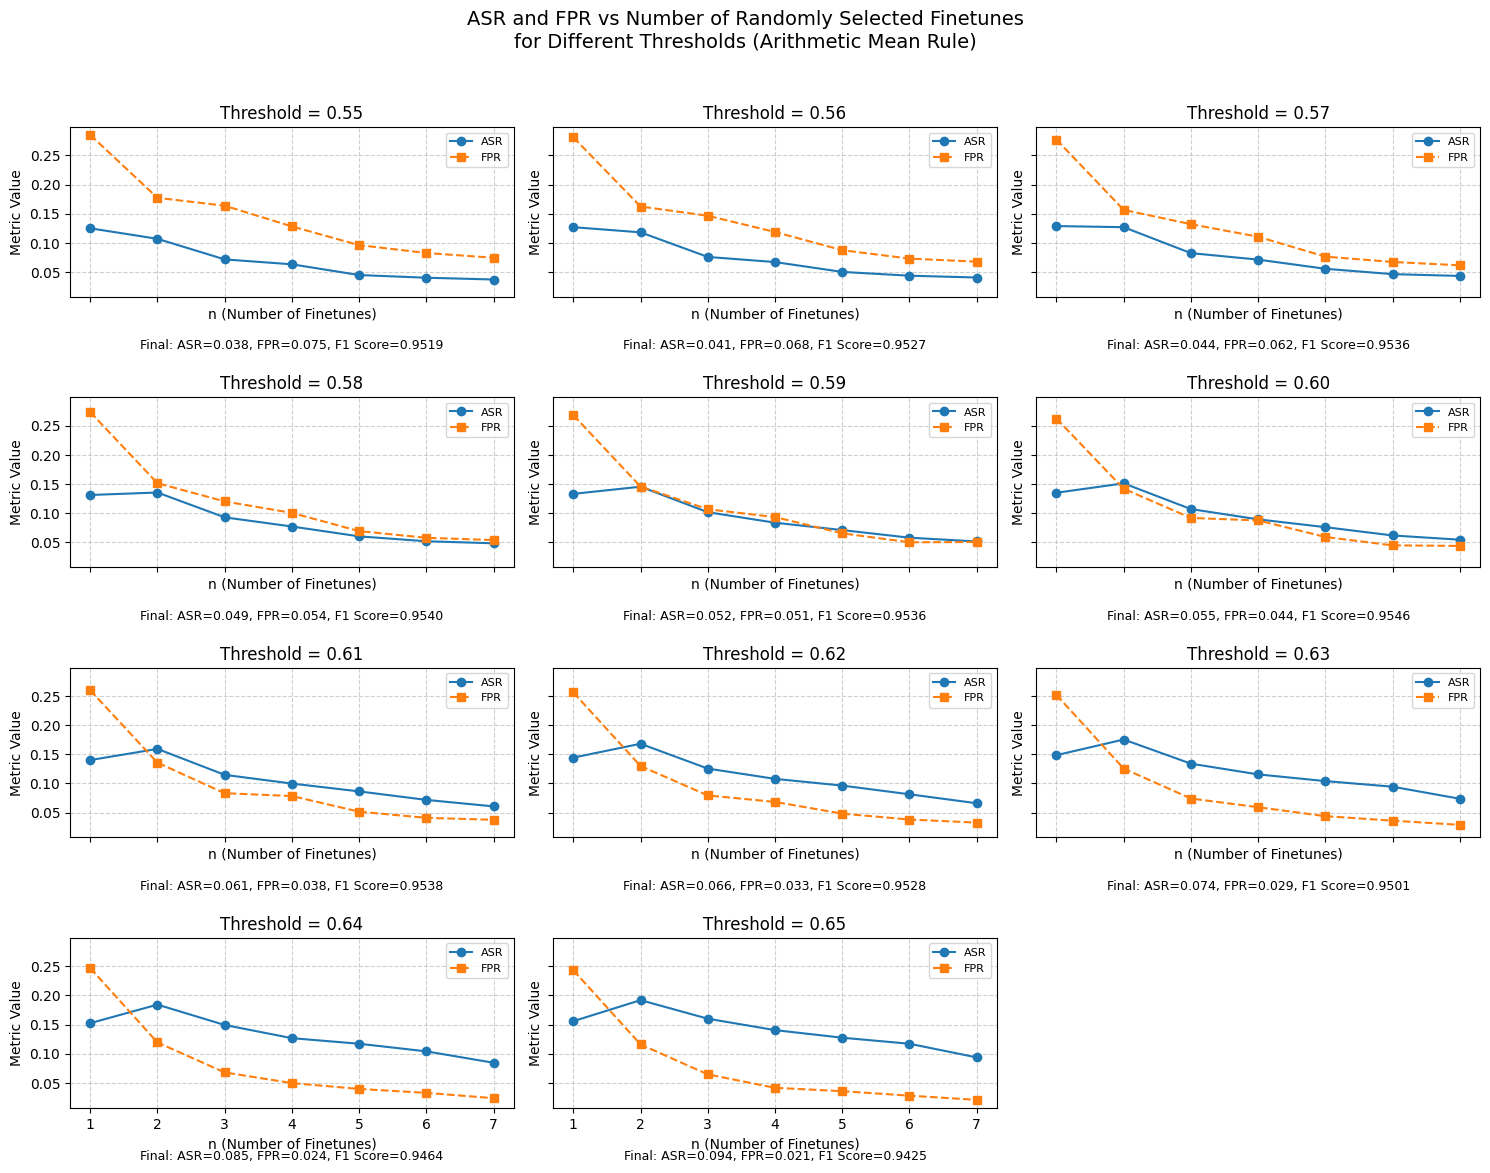

In [ ]:
# Collect finetune model probabilities
finetune_probs = [
    model_1_probs,
    model_2_probs,
    model_3_probs,
    model_4_probs,
    model_5_probs,
    model_6_probs,
    model_7_probs
]

n_models = len(finetune_probs)
n_samples = len(test_labels)
thresholds = np.arange(0.55, 0.66, 0.01)

random.seed(42)
all_results = []

# --- Main loop: n = 1..5, threshold sweep ---
for n in range(1, n_models + 1):
    combined_probs = []
    for i in range(n_samples):
        selected_indices = random.sample(range(n_models), n)
        avg_prob = np.mean([finetune_probs[j][i] for j in selected_indices])
        combined_probs.append(avg_prob)
    combined_probs = np.array(combined_probs)

    for thresh in thresholds:
        preds = [1 if p > thresh else 0 for p in combined_probs]
        metrics = compute_asr_fpr(test_labels, preds)
        f1 = f1_score([int(x) for x in test_labels], preds)
        all_results.append({
            'n': n,
            'threshold': round(thresh, 2),
            'ASR': metrics['ASR'],
            'FPR': metrics['FPR'],
            'F1': f1
        })

results_df = pd.DataFrame(all_results)

# --- Plot: one subplot per threshold, showing both ASR and FPR ---
num_thresholds = len(thresholds)
ncols = 3  # grid layout (3 columns)
nrows = int(np.ceil(num_thresholds / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 3), sharex=True, sharey=True)
axes = axes.flatten()

for idx, thresh in enumerate(thresholds):
    ax = axes[idx]
    subset = results_df[results_df['threshold'] == round(thresh, 2)]

    ax.plot(subset['n'], subset['ASR'], marker='o', label='ASR', color='C0')
    ax.plot(subset['n'], subset['FPR'], marker='s', linestyle='--', label='FPR', color='C1')
    ax.set_title(f'Threshold = {thresh:.2f}')
    ax.set_xlabel('n (Number of Finetunes)')
    ax.set_ylabel('Metric Value')
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(fontsize=8)

    final_row = subset[subset['n'] == len(finetune_probs)].iloc[0]
    final_asr = final_row['ASR']
    final_fpr = final_row['FPR']
    final_f1 = final_row['F1']
    ax.text(
        0.5, -0.25,
        f"Final: ASR={final_asr:.3f}, FPR={final_fpr:.3f}, F1 Score={final_f1:.4f}",
        ha='center', va='top', transform=ax.transAxes, fontsize=9, color='black'
    )

# Hide unused subplots if thresholds don’t fill the grid
for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('ASR and FPR vs Number of Randomly Selected Finetunes\nfor Different Thresholds (Arithmetic Mean Rule)', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

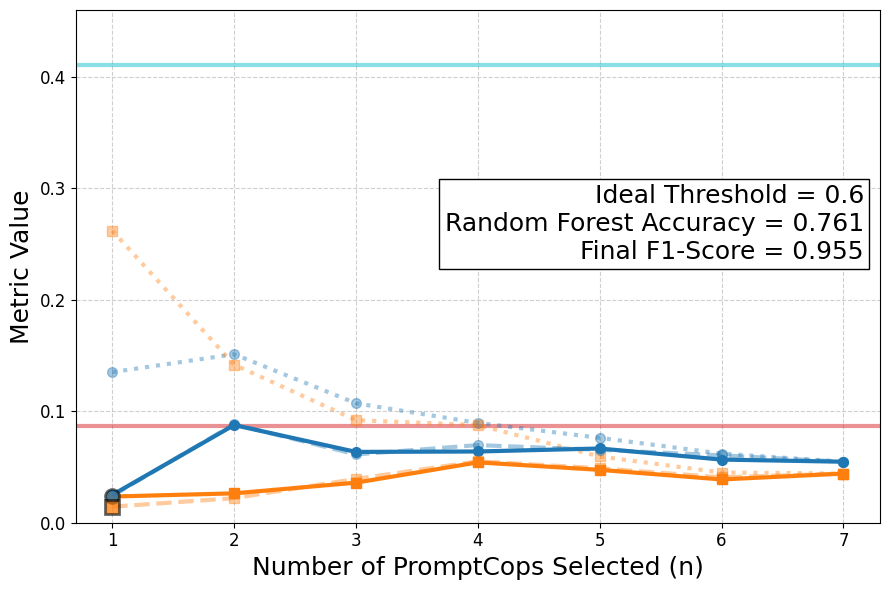

In [ ]:
threshold = 0.60

# Collect all fine-tune model probabilities
finetune_probs = [
    model_1_probs,
    model_2_probs,
    model_3_probs,
    model_4_probs,
    model_5_probs,
    model_6_probs,
    model_7_probs
]

n_models = len(finetune_probs)
n_samples = len(test_labels)
results = []
ideal_results = []
forest_results = []

random.seed(42)  # reproducibility

# --- Baseline (non-finetuned model) ---
baseline_preds = [1 if p > 0.5 else 0 for p in baseline_probs]
baseline_metrics = compute_asr_fpr(test_labels, baseline_preds)
baseline_asr = baseline_metrics['ASR']
baseline_fpr = baseline_metrics['FPR']

# --- Normal random finetune selection for n = 1..5 ---
for n in range(1, n_models + 1):
    combined_probs = []
    for i in range(n_samples):
        selected_indices = random.sample(range(n_models), n)
        avg_prob = np.mean([finetune_probs[j][i] for j in selected_indices])
        combined_probs.append(avg_prob)

    preds = [1 if p > threshold else 0 for p in combined_probs]
    metrics = compute_asr_fpr(test_labels, preds)
    metrics['n'] = n
    results.append(metrics)

# --- Ideal case: always include the best model per sample ---
# best_model_ids is a list of integers from 1 to 5 (same length as test_labels)
for n in range(1, n_models + 1):
    combined_probs = []
    for i in range(n_samples):
        best_model_idx = best_model_ids[i] - 1  # convert 1–5 → 0–4 index

        if n == 1:
            selected_indices = [best_model_idx]
        else:
            # Always include the best model, and select the rest randomly
            other_indices = [idx for idx in range(n_models) if idx != best_model_idx]
            selected_indices = [best_model_idx] + random.sample(other_indices, n - 1)

        avg_prob = np.mean([finetune_probs[j][i] for j in selected_indices])
        combined_probs.append(avg_prob)

    preds = [1 if p > threshold else 0 for p in combined_probs]
    metrics = compute_asr_fpr(test_labels, preds)
    metrics['n'] = n
    ideal_results.append(metrics)


# --- Forest case: always include the random forest model per sample ---
# best_model_ids_forest is a list of integers from 1 to 9 (same length as test_labels)
for n in range(1, n_models + 1):
    combined_probs = []
    for i in range(n_samples):
        best_model_idx = best_model_ids_forest[i] - 1  # convert 1–5 → 0–4 index

        if n == 1:
            selected_indices = [best_model_idx]
        else:
            # Always include the best model, and select the rest randomly
            other_indices = [idx for idx in range(n_models) if idx != best_model_idx]
            selected_indices = [best_model_idx] + random.sample(other_indices, n - 1)

        avg_prob = np.mean([finetune_probs[j][i] for j in selected_indices])
        combined_probs.append(avg_prob)

    preds = [1 if p > threshold else 0 for p in combined_probs]
    metrics = compute_asr_fpr(test_labels, preds)
    metrics['n'] = n
    forest_results.append(metrics)
    forest_final_f1 = f1_score(test_labels, preds)



# --- Extract values for plotting ---
n_values = [r['n'] for r in results]
asr_values = [r['ASR'] for r in results]
fpr_values = [r['FPR'] for r in results]

ideal_asr_values = [r['ASR'] for r in ideal_results]
ideal_fpr_values = [r['FPR'] for r in ideal_results]

forest_asr_values = [r['ASR'] for r in forest_results]
forest_fpr_values = [r['FPR'] for r in forest_results]

# --- Compute final F1 score for the random strategy (at n = ?) ---
# Reconstruct the last (n=?) combined probabilities and predictions
final_combined_probs = []
n_final = n_models
for i in range(n_samples):
    selected_indices = random.sample(range(n_models), n_final)
    avg_prob = np.mean([finetune_probs[j][i] for j in selected_indices])
    final_combined_probs.append(avg_prob)

final_preds = [1 if p > threshold else 0 for p in final_combined_probs]
final_f1 = f1_score(test_labels, final_preds)

# --- Plot ---
plt.figure(figsize=(9, 6))

plt.axhline(y=baseline_asr, color='C9', alpha=0.5, label='Baseline ASR', linewidth=3, markersize=7)
plt.axhline(y=baseline_fpr, color='C3', alpha=0.5, label='Baseline FPR', linewidth=3, markersize=7)
plt.plot(n_values, asr_values, marker='o', linestyle=':', color='C0', alpha=0.4, label='Random Selection ASR', linewidth=3, markersize=7)
plt.plot(n_values, fpr_values, marker='s', linestyle=':', color='C1', alpha=0.4, label='Random Selection FPR', linewidth=3, markersize=7)
plt.plot(n_values, forest_asr_values, marker='o', color='C0', label='ASR (Predicted Expert and n-1 Random Selections)', linewidth=3, markersize=7)
plt.plot(n_values, forest_fpr_values, marker='s', color='C1', label='FPR (Predicted Expert and n-1 Random Selections)', linewidth=3, markersize=7)
plt.plot(n_values, ideal_asr_values, marker='o', linestyle='--', color='C0', alpha=0.4, label='Ideal ASR (Best Expert and n-1 Random Selections)', linewidth=3, markersize=7)
plt.plot(n_values, ideal_fpr_values, marker='s', linestyle='--', color='C1', alpha=0.4, label='Ideal FPR (Best Expert and n-1 Random Selections)', linewidth=3, markersize=7)

plt.plot(
    n_values[0], ideal_asr_values[0],
    marker='o', markersize=10, linestyle='None',
    color='C0', markeredgecolor='black',
    label='Ideal ASR (Best Expert Only)', zorder=5, alpha=0.6, markeredgewidth=2
)

plt.plot(
    n_values[0], ideal_fpr_values[0],
    marker='s', markersize=10, linestyle='None',
    color='C1', markeredgecolor='black',
    label='Ideal FPR (Best Expert Only)', zorder=5, alpha=0.6, markeredgewidth=2
)

textstr = f'Ideal Threshold = {threshold}\nRandom Forest Accuracy = {clf.score(X_test, y_test):.3f}\nFinal F1-Score = {final_f1:.3f}'
plt.text(
    0.98, 0.66, textstr,
    transform=plt.gca().transAxes,
    fontsize=18,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(facecolor="white", alpha=1.0)
)

plt.ylim(0, 0.46)
plt.xlabel('Number of PromptCops Selected (n)', fontsize='18')
plt.ylabel('Metric Value', fontsize='18')
# plt.title(
#     f'(k=7) Performance Across Increasing Selection Size',
#     fontweight='bold',
#     fontsize='19'
# )
plt.grid(True, linestyle='--', alpha=0.6)

plt.tick_params(axis='both', which='major', labelsize=12)

# leg = plt.legend(loc="upper right", bbox_to_anchor=(0.99, 0.96), borderaxespad=0.0, facecolor="white", fontsize='11')
# for text in leg.get_texts():
#     if text.get_text() == "ASR (Predicted Expert and n-1 Random Selections)" or text.get_text() == "FPR (Predicted Expert and n-1 Random Selections)":
#         text.set_fontstyle('oblique')

plt.tight_layout()
plt.savefig("exp2_7.pdf", bbox_inches="tight")
plt.show()

# Dataset / Finetune 8

## ToxicDetector's Evaluation Dataset

https://sites.google.com/view/toxic-prompt-detector/open-science-artifact

In [ ]:
df = pd.read_csv(DATASETS_DIRECTORY + 'toxic_scenarios.csv')
df = df[['Question_benign', 'Question_malicious']]

df['label'] = np.random.randint(0, 2, size=len(df))
# Use np.where to select the appropriate prompt based on the label
df['prompt'] = np.where(df['label'] == 0, df['Question_benign'], df['Question_malicious'])
# Keep only the desired columns
df = df[['prompt', 'label']]
# Shuffle the dataset
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

In [ ]:
train_df, temp_df = train_test_split(df, test_size=0.30, random_state=42)
cal_df, test_df = train_test_split(temp_df, test_size=2/3, random_state=42)
finetuning_df, val_df = train_test_split(train_df, test_size=0.20, random_state=42)

In [ ]:
# Load the Prompt Guard model
prompt_injection_model_name = 'meta-llama/Llama-Prompt-Guard-2-86M'
tokenizer = AutoTokenizer.from_pretrained(prompt_injection_model_name)
model = AutoModelForSequenceClassification.from_pretrained(prompt_injection_model_name)

In [ ]:
print("\n" + "="*50)
print("EVALUATING ORIGINAL MODEL ON VAL SET")
print("="*50)

test_texts = test_df['prompt'].tolist()
test_labels = test_df['label'].tolist()

# Get predictions from model
test_scores = evaluate_batch(model, tokenizer, test_texts, batch_size=64, positive_label=1, temperature=3.0)

# Convert scores to binary predictions (threshold = 0.5)
test_predictions = [1 if score > 0.5 else 0 for score in test_scores]

# Calculate metrics
metrics = compute_asr_fpr(test_labels, test_predictions)

print(f"Original Model Performance:")
print(metrics)

In [ ]:
# Fine-tune the model
print("\n" + "="*50)
print("FINE-TUNING MODEL")
print("="*50)

model, tokenizer = train_model(model, tokenizer, train_df, batch_size=16, epochs=5, device='cuda')

In [ ]:
print("\n" + "="*50)
print("EVALUATING FINETUNED MODEL ON TEST SET")
print("="*50)

test_texts = test_df['prompt'].tolist()
test_labels = test_df['label'].tolist()

# Get predictions from original model
test_scores = evaluate_batch(model, tokenizer, test_texts, positive_label=1, temperature=3.0)

# Convert scores to binary predictions (threshold = 0.5)
test_predictions = [1 if score > 0.5 else 0 for score in test_scores]

# Calculate metrics
metrics = compute_asr_fpr(test_labels, test_predictions)

print(f"Finetuned Model Performance:")
print(metrics)

In [ ]:
save_dir = MODELS_DIRECTORY + "model_8"
save_model_and_tokenizer(model, tokenizer, save_dir)

In [ ]:
# delete the old model explicitly
del model
gc.collect()
torch.cuda.empty_cache()

In [ ]:
test_df['model'] = 8
combined_df = pd.concat([combined_df, test_df], ignore_index=True)
print("Combined dataset size = ", combined_df.shape[0])
combined_df.head()

In [ ]:
# Save combined dataset for k = 8
combined_df.to_csv(RESULTS_DIRECTORY + "k=8/combined_df.csv", index=False)

## Analysis

In [ ]:
# Load the combined dataset at this point in time
combined_df = pd.read_csv(RESULTS_DIRECTORY + 'k=8/combined_df.csv')

In [ ]:
test_texts = combined_df['prompt'].tolist()
test_labels = combined_df['label'].tolist()
best_model_ids = combined_df['model'].tolist()

In [ ]:
#Baseline Results
prompt_injection_model_name = 'meta-llama/Llama-Prompt-Guard-2-86M'
tokenizer = AutoTokenizer.from_pretrained(prompt_injection_model_name)
model = AutoModelForSequenceClassification.from_pretrained(prompt_injection_model_name)

baseline_probs = evaluate_batch(model, tokenizer, test_texts, positive_label=1, temperature=3.0)

#Model 1 Results
model, tokenizer = load_model_and_tokenizer(MODELS_DIRECTORY + "model_1")

model_1_probs = evaluate_batch(model, tokenizer, test_texts, positive_label=1, temperature=3.0)

#Model 2 Results
model, tokenizer = load_model_and_tokenizer(MODELS_DIRECTORY + "model_2")

model_2_probs = evaluate_batch(model, tokenizer, test_texts, positive_label=1, temperature=3.0)

#Model 3 Results
model, tokenizer = load_model_and_tokenizer(MODELS_DIRECTORY + "model_3")

model_3_probs = evaluate_batch(model, tokenizer, test_texts, positive_label=1, temperature=3.0)

#Model 4 Results
model, tokenizer = load_model_and_tokenizer(MODELS_DIRECTORY + "model_4")

model_4_probs = evaluate_batch(model, tokenizer, test_texts, positive_label=1, temperature=3.0)

#Model 5 Results
model, tokenizer = load_model_and_tokenizer(MODELS_DIRECTORY + "model_5")

model_5_probs = evaluate_batch(model, tokenizer, test_texts, positive_label=1, temperature=3.0)

#Model 6 Results
model, tokenizer = load_model_and_tokenizer(MODELS_DIRECTORY + "model_6")

model_6_probs = evaluate_batch(model, tokenizer, test_texts, positive_label=1, temperature=3.0)

#Model 7 Results
model, tokenizer = load_model_and_tokenizer(MODELS_DIRECTORY + "model_7")

model_7_probs = evaluate_batch(model, tokenizer, test_texts, positive_label=1, temperature=3.0)

#Model 8 Results
model, tokenizer = load_model_and_tokenizer(MODELS_DIRECTORY + "model_8")

model_8_probs = evaluate_batch(model, tokenizer, test_texts, positive_label=1, temperature=3.0)

In [ ]:
with open(RESULTS_DIRECTORY + "k=8/baseline_probs.pkl", "wb") as f:
    pickle.dump(baseline_probs, f)
with open(RESULTS_DIRECTORY + "k=8/model_1_probs.pkl", "wb") as f:
    pickle.dump(model_1_probs, f)
with open(RESULTS_DIRECTORY + "k=8/model_2_probs.pkl", "wb") as f:
    pickle.dump(model_2_probs, f)
with open(RESULTS_DIRECTORY + "k=8/model_3_probs.pkl", "wb") as f:
    pickle.dump(model_3_probs, f)
with open(RESULTS_DIRECTORY + "k=8/model_4_probs.pkl", "wb") as f:
    pickle.dump(model_4_probs, f)
with open(RESULTS_DIRECTORY + "k=8/model_5_probs.pkl", "wb") as f:
    pickle.dump(model_5_probs, f)
with open(RESULTS_DIRECTORY + "k=8/model_6_probs.pkl", "wb") as f:
    pickle.dump(model_6_probs, f)
with open(RESULTS_DIRECTORY + "k=8/model_7_probs.pkl", "wb") as f:
    pickle.dump(model_7_probs, f)
with open(RESULTS_DIRECTORY + "k=8/model_8_probs.pkl", "wb") as f:
    pickle.dump(model_8_probs, f)

In [ ]:
with open(RESULTS_DIRECTORY + "k=8/baseline_probs.pkl", "rb") as f:
    baseline_probs = pickle.load(f)
with open(RESULTS_DIRECTORY + "k=8/model_1_probs.pkl", "rb") as f:
    model_1_probs = pickle.load(f)
with open(RESULTS_DIRECTORY + "k=8/model_2_probs.pkl", "rb") as f:
    model_2_probs = pickle.load(f)
with open(RESULTS_DIRECTORY + "k=8/model_3_probs.pkl", "rb") as f:
    model_3_probs = pickle.load(f)
with open(RESULTS_DIRECTORY + "k=8/model_4_probs.pkl", "rb") as f:
    model_4_probs = pickle.load(f)
with open(RESULTS_DIRECTORY + "k=8/model_5_probs.pkl", "rb") as f:
    model_5_probs = pickle.load(f)
with open(RESULTS_DIRECTORY + "k=8/model_6_probs.pkl", "rb") as f:
    model_6_probs = pickle.load(f)
with open(RESULTS_DIRECTORY + "k=8/model_7_probs.pkl", "rb") as f:
    model_7_probs = pickle.load(f)
with open(RESULTS_DIRECTORY + "k=8/model_8_probs.pkl", "rb") as f:
    model_8_probs = pickle.load(f)

In [ ]:
import pandas as pd
import numpy as np
import re
from collections import Counter
from math import log2

# Function to calculate Shannon entropy of characters
def text_entropy(text):
    if not text:
        return 0
    freq = Counter(text)
    probs = [v / len(text) for v in freq.values()]
    return -sum(p * log2(p) for p in probs)

# Function to check for common code keywords
code_keywords = {'if', 'else', 'while', 'for', 'import', 'def', 'function',
                 'var', 'let', 'const', 'return', 'class', 'script', 'print', 'exec'}

common_english = {'the', 'and', 'you', 'your', 'please', 'what', 'how', 'can', 'do', 'tell'}

def extract_features(df):
    df = df.copy()

    # Basic text cleaning
    df['prompt'] = df['prompt'].astype(str)

    # 1. Prompt length (in words)
    df['prompt_length'] = df['prompt'].apply(lambda x: len(x.split()))

    # 2. Whitespace proportion
    df['whitespace_proportion'] = df['prompt'].apply(lambda x: x.count(' ') / len(x) if len(x) > 0 else 0)

    # 3. Special character proportion
    special_chars = r"[^a-zA-Z0-9\s]"
    df['special_char_proportion'] = df['prompt'].apply(
        lambda x: len(re.findall(special_chars, x)) / len(x) if len(x) > 0 else 0
    )

    # 4. Average word length
    df['avg_word_length'] = df['prompt'].apply(
        lambda x: np.mean([len(w) for w in x.split()]) if len(x.split()) > 0 else 0
    )

    # 5. Digit proportion
    df['digit_proportion'] = df['prompt'].apply(lambda x: sum(c.isdigit() for c in x) / len(x) if len(x) > 0 else 0)

    # 6. Uppercase ratio
    df['uppercase_ratio'] = df['prompt'].apply(lambda x: sum(c.isupper() for c in x) / len(x) if len(x) > 0 else 0)

    # 7. Code keyword proportion
    df['code_keyword_count'] = df['prompt'].apply(
        lambda x: sum(1 for w in re.findall(r'\b\w+\b', x.lower()) if w in code_keywords)
    )

    # 8. Natural language word proportion
    df['nl_word_count'] = df['prompt'].apply(
        lambda x: sum(1 for w in re.findall(r'\b\w+\b', x.lower()) if w in common_english)
    )

    # 9. Character entropy
    df['char_entropy'] = df['prompt'].apply(text_entropy)

    return df

# Example usage:
combined_df = extract_features(combined_df)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X = cal_df.drop(columns=['prompt', 'model', 'label', 'type'])
y = cal_df['model']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = RandomForestClassifier(n_estimators=200, random_state=42)
clf.fit(X_train, y_train)

print("Accuracy:", clf.score(X_test, y_test))

In [ ]:
best_model_ids_forest = clf.predict(X)
print(len(best_model_ids_forest))
print(best_model_ids_forest)

In [ ]:
best_model_ids_forest = best_model_ids_forest.tolist()

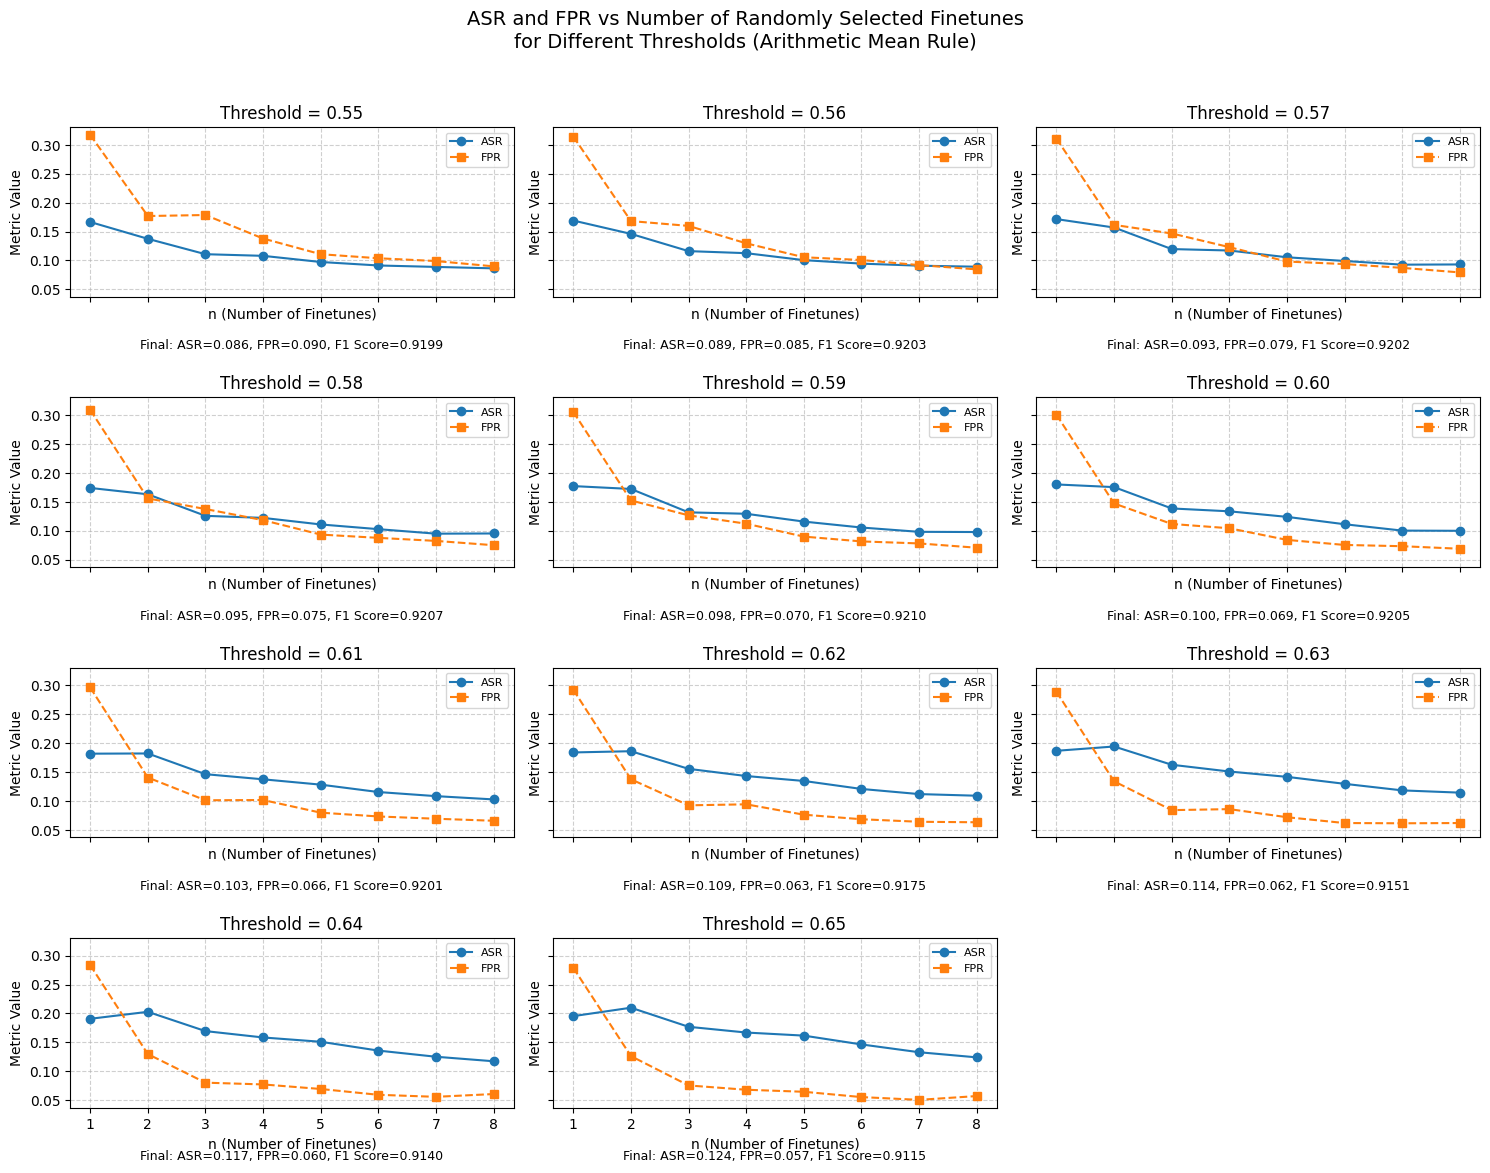

In [ ]:
# Collect finetune model probabilities
finetune_probs = [
    model_1_probs,
    model_2_probs,
    model_3_probs,
    model_4_probs,
    model_5_probs,
    model_6_probs,
    model_7_probs,
    model_8_probs
]

n_models = len(finetune_probs)
n_samples = len(test_labels)
thresholds = np.arange(0.55, 0.66, 0.01)

random.seed(42)
all_results = []

# --- Main loop: n = 1..5, threshold sweep ---
for n in range(1, n_models + 1):
    combined_probs = []
    for i in range(n_samples):
        selected_indices = random.sample(range(n_models), n)
        avg_prob = np.mean([finetune_probs[j][i] for j in selected_indices])
        combined_probs.append(avg_prob)
    combined_probs = np.array(combined_probs)

    for thresh in thresholds:
        preds = [1 if p > thresh else 0 for p in combined_probs]
        metrics = compute_asr_fpr(test_labels, preds)
        f1 = f1_score([int(x) for x in test_labels], preds)
        all_results.append({
            'n': n,
            'threshold': round(thresh, 2),
            'ASR': metrics['ASR'],
            'FPR': metrics['FPR'],
            'F1': f1
        })

results_df = pd.DataFrame(all_results)

# --- Plot: one subplot per threshold, showing both ASR and FPR ---
num_thresholds = len(thresholds)
ncols = 3  # grid layout (3 columns)
nrows = int(np.ceil(num_thresholds / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 3), sharex=True, sharey=True)
axes = axes.flatten()

for idx, thresh in enumerate(thresholds):
    ax = axes[idx]
    subset = results_df[results_df['threshold'] == round(thresh, 2)]

    ax.plot(subset['n'], subset['ASR'], marker='o', label='ASR', color='C0')
    ax.plot(subset['n'], subset['FPR'], marker='s', linestyle='--', label='FPR', color='C1')
    ax.set_title(f'Threshold = {thresh:.2f}')
    ax.set_xlabel('n (Number of Finetunes)')
    ax.set_ylabel('Metric Value')
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(fontsize=8)

    final_row = subset[subset['n'] == len(finetune_probs)].iloc[0]
    final_asr = final_row['ASR']
    final_fpr = final_row['FPR']
    final_f1 = final_row['F1']
    ax.text(
        0.5, -0.25,
        f"Final: ASR={final_asr:.3f}, FPR={final_fpr:.3f}, F1 Score={final_f1:.4f}",
        ha='center', va='top', transform=ax.transAxes, fontsize=9, color='black'
    )

# Hide unused subplots if thresholds don’t fill the grid
for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('ASR and FPR vs Number of Randomly Selected Finetunes\nfor Different Thresholds (Arithmetic Mean Rule)', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

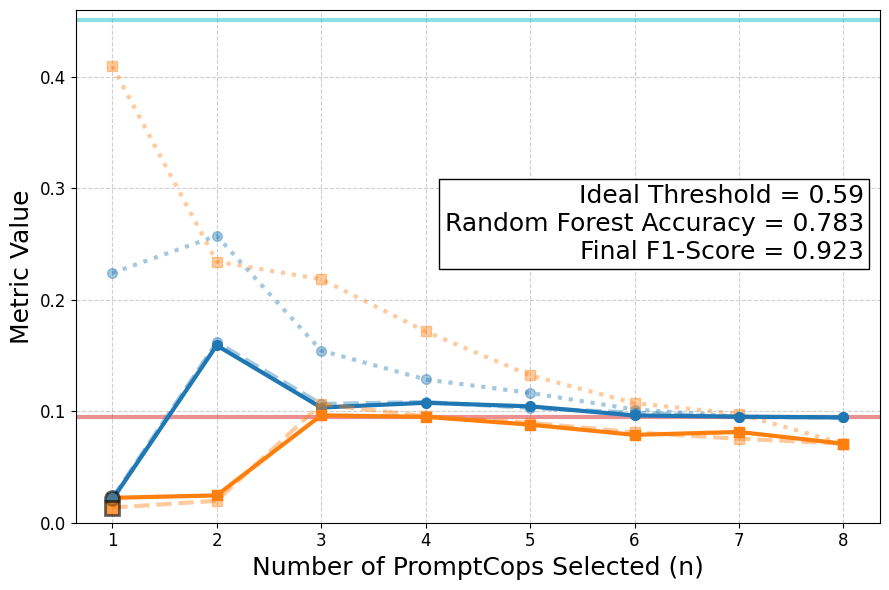

In [ ]:
threshold = 0.59

# Collect all fine-tune model probabilities
finetune_probs = [
    model_1_probs,
    model_2_probs,
    model_3_probs,
    model_4_probs,
    model_5_probs,
    model_6_probs,
    model_7_probs,
    model_8_probs
]

n_models = len(finetune_probs)
n_samples = len(test_labels)
results = []
ideal_results = []
forest_results = []

random.seed(42)  # reproducibility

# --- Baseline (non-finetuned model) ---
baseline_preds = [1 if p > 0.5 else 0 for p in baseline_probs]
baseline_metrics = compute_asr_fpr(test_labels, baseline_preds)
baseline_asr = baseline_metrics['ASR']
baseline_fpr = baseline_metrics['FPR']

# --- Normal random finetune selection for n = 1..5 ---
for n in range(1, n_models + 1):
    combined_probs = []
    for i in range(n_samples):
        selected_indices = random.sample(range(n_models), n)
        avg_prob = np.mean([finetune_probs[j][i] for j in selected_indices])
        combined_probs.append(avg_prob)

    preds = [1 if p > threshold else 0 for p in combined_probs]
    metrics = compute_asr_fpr(test_labels, preds)
    metrics['n'] = n
    results.append(metrics)

# --- Ideal case: always include the best model per sample ---
# best_model_ids is a list of integers from 1 to 5 (same length as test_labels)
for n in range(1, n_models + 1):
    combined_probs = []
    for i in range(n_samples):
        best_model_idx = best_model_ids[i] - 1  # convert 1–5 → 0–4 index

        if n == 1:
            selected_indices = [best_model_idx]
        else:
            # Always include the best model, and select the rest randomly
            other_indices = [idx for idx in range(n_models) if idx != best_model_idx]
            selected_indices = [best_model_idx] + random.sample(other_indices, n - 1)

        avg_prob = np.mean([finetune_probs[j][i] for j in selected_indices])
        combined_probs.append(avg_prob)

    preds = [1 if p > threshold else 0 for p in combined_probs]
    metrics = compute_asr_fpr(test_labels, preds)
    metrics['n'] = n
    ideal_results.append(metrics)


# --- Forest case: always include the random forest model per sample ---
# best_model_ids_forest is a list of integers from 1 to 9 (same length as test_labels)
for n in range(1, n_models + 1):
    combined_probs = []
    for i in range(n_samples):
        best_model_idx = best_model_ids_forest[i] - 1  # convert 1–5 → 0–4 index

        if n == 1:
            selected_indices = [best_model_idx]
        else:
            # Always include the best model, and select the rest randomly
            other_indices = [idx for idx in range(n_models) if idx != best_model_idx]
            selected_indices = [best_model_idx] + random.sample(other_indices, n - 1)

        avg_prob = np.mean([finetune_probs[j][i] for j in selected_indices])
        combined_probs.append(avg_prob)

    preds = [1 if p > threshold else 0 for p in combined_probs]
    metrics = compute_asr_fpr(test_labels, preds)
    metrics['n'] = n
    forest_results.append(metrics)
    forest_final_f1 = f1_score(test_labels, preds)



# --- Extract values for plotting ---
n_values = [r['n'] for r in results]
asr_values = [r['ASR'] for r in results]
fpr_values = [r['FPR'] for r in results]

ideal_asr_values = [r['ASR'] for r in ideal_results]
ideal_fpr_values = [r['FPR'] for r in ideal_results]

forest_asr_values = [r['ASR'] for r in forest_results]
forest_fpr_values = [r['FPR'] for r in forest_results]

# --- Compute final F1 score for the random strategy (at n = ?) ---
# Reconstruct the last (n=?) combined probabilities and predictions
final_combined_probs = []
n_final = n_models
for i in range(n_samples):
    selected_indices = random.sample(range(n_models), n_final)
    avg_prob = np.mean([finetune_probs[j][i] for j in selected_indices])
    final_combined_probs.append(avg_prob)

final_preds = [1 if p > threshold else 0 for p in final_combined_probs]
final_f1 = f1_score(test_labels, final_preds)

# --- Plot ---
plt.figure(figsize=(9, 6))

plt.axhline(y=baseline_asr, color='C9', alpha=0.5, label='Baseline ASR', linewidth=3, markersize=7)
plt.axhline(y=baseline_fpr, color='C3', alpha=0.5, label='Baseline FPR', linewidth=3, markersize=7)
plt.plot(n_values, asr_values, marker='o', linestyle=':', color='C0', alpha=0.4, label='Random Selection ASR', linewidth=3, markersize=7)
plt.plot(n_values, fpr_values, marker='s', linestyle=':', color='C1', alpha=0.4, label='Random Selection FPR', linewidth=3, markersize=7)
plt.plot(n_values, forest_asr_values, marker='o', color='C0', label='ASR (Predicted Expert and n-1 Random Selections)', linewidth=3, markersize=7)
plt.plot(n_values, forest_fpr_values, marker='s', color='C1', label='FPR (Predicted Expert and n-1 Random Selections)', linewidth=3, markersize=7)
plt.plot(n_values, ideal_asr_values, marker='o', linestyle='--', color='C0', alpha=0.4, label='Ideal ASR (Best Expert and n-1 Random Selections)', linewidth=3, markersize=7)
plt.plot(n_values, ideal_fpr_values, marker='s', linestyle='--', color='C1', alpha=0.4, label='Ideal FPR (Best Expert and n-1 Random Selections)', linewidth=3, markersize=7)

plt.plot(
    n_values[0], ideal_asr_values[0],
    marker='o', markersize=10, linestyle='None',
    color='C0', markeredgecolor='black',
    label='Ideal ASR (Best Expert Only)', zorder=5, alpha=0.6, markeredgewidth=2
)

plt.plot(
    n_values[0], ideal_fpr_values[0],
    marker='s', markersize=10, linestyle='None',
    color='C1', markeredgecolor='black',
    label='Ideal FPR (Best Expert Only)', zorder=5, alpha=0.6, markeredgewidth=2
)

textstr = f'Ideal Threshold = {threshold}\nRandom Forest Accuracy = {clf.score(X_test, y_test):.3f}\nFinal F1-Score = {final_f1:.3f}'
plt.text(
    0.98, 0.66, textstr,
    transform=plt.gca().transAxes,
    fontsize=18,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(facecolor="white", alpha=1.0)
)

plt.ylim(0, 0.46)
plt.xlabel('Number of PromptCops Selected (n)', fontsize='18')
plt.ylabel('Metric Value', fontsize='18')
# plt.title(
#     f'(k=8) Performance Across Increasing Selection Size',
#     fontweight='bold',
#     fontsize='19'
# )
plt.grid(True, linestyle='--', alpha=0.6)

plt.tick_params(axis='both', which='major', labelsize=12)

# leg = plt.legend(loc="upper right", bbox_to_anchor=(0.99, 0.96), borderaxespad=0.0, facecolor="white", fontsize='11')
# for text in leg.get_texts():
#     if text.get_text() == "ASR (Predicted Expert and n-1 Random Selections)" or text.get_text() == "FPR (Predicted Expert and n-1 Random Selections)":
#         text.set_fontstyle('oblique')

plt.tight_layout()
plt.savefig("exp2_8.pdf", bbox_inches="tight")
plt.show()

# Dataset / Finetune 9

## guychuk/benign-malicious-prompt-classification

https://huggingface.co/datasets/guychuk/benign-malicious-prompt-classification

In [ ]:
# Load and analyze the  dataset
dataset = load_dataset("guychuk/benign-malicious-prompt-classification")
dataset = dataset['train'].to_pandas()

train_df, temp_df = train_test_split(dataset, test_size=0.30, random_state=42, stratify=dataset['label'])
cal_df, test_df = train_test_split(temp_df, test_size=2/3, random_state=42)
finetuning_df, val_df = train_test_split(train_df, test_size=0.20, random_state=42)

In [ ]:
# Load the Prompt Guard model
prompt_injection_model_name = 'meta-llama/Llama-Prompt-Guard-2-86M'
tokenizer = AutoTokenizer.from_pretrained(prompt_injection_model_name)
model = AutoModelForSequenceClassification.from_pretrained(prompt_injection_model_name)

In [ ]:
print("\n" + "="*50)
print("EVALUATING ORIGINAL MODEL ON VAL SET")
print("="*50)

test_texts = test_df['prompt'].tolist()
test_labels = test_df['label'].tolist()

# Get predictions from model
test_scores = evaluate_batch(model, tokenizer, test_texts, batch_size=64, positive_label=1, temperature=3.0)

# Convert scores to binary predictions (threshold = 0.5)
test_predictions = [1 if score > 0.5 else 0 for score in test_scores]

# Calculate metrics
metrics = compute_asr_fpr(test_labels, test_predictions)

print(f"Original Model Performance:")
print(metrics)

In [ ]:
# Fine-tune the model
print("\n" + "="*50)
print("FINE-TUNING MODEL")
print("="*50)

model, tokenizer = train_model(model, tokenizer, train_df, batch_size=16, epochs=3, device='cuda')

In [ ]:
print("\n" + "="*50)
print("EVALUATING FINETUNED MODEL ON TEST SET")
print("="*50)

test_texts = test_df['prompt'].tolist()
test_labels = test_df['label'].tolist()

# Get predictions from original model
test_scores = evaluate_batch(model, tokenizer, test_texts, positive_label=1, temperature=3.0)

# Convert scores to binary predictions (threshold = 0.5)
test_predictions = [1 if score > 0.5 else 0 for score in test_scores]

# Calculate metrics
metrics = compute_asr_fpr(test_labels, test_predictions)

print(f"Finetuned Model Performance:")
print(metrics)

In [ ]:
save_dir = MODELS_DIRECTORY + "model_9"
save_model_and_tokenizer(model, tokenizer, save_dir)

In [ ]:
# delete the old model explicitly
del model
gc.collect()
torch.cuda.empty_cache()

In [ ]:
test_df['model'] = 9
combined_df = pd.concat([combined_df, test_df], ignore_index=True)
print("Combined dataset size = ", combined_df.shape[0])
combined_df.head()

In [ ]:
# Save combined dataset for k = 9
combined_df.to_csv(RESULTS_DIRECTORY + "k=9/combined_df.csv", index=False)

## Analysis

In [ ]:
# Load the combined dataset at this point in time
combined_df = pd.read_csv(RESULTS_DIRECTORY + 'k=9/combined_df.csv')

In [ ]:
test_texts = combined_df['prompt'].tolist()
test_labels = combined_df['label'].tolist()
best_model_ids = combined_df['model'].tolist()

In [ ]:
#Baseline Results
prompt_injection_model_name = 'meta-llama/Llama-Prompt-Guard-2-86M'
tokenizer = AutoTokenizer.from_pretrained(prompt_injection_model_name)
model = AutoModelForSequenceClassification.from_pretrained(prompt_injection_model_name)

baseline_probs = evaluate_batch(model, tokenizer, test_texts, positive_label=1, temperature=3.0)

#Model 1 Results
model, tokenizer = load_model_and_tokenizer(MODELS_DIRECTORY + "model_1")

model_1_probs = evaluate_batch(model, tokenizer, test_texts, positive_label=1, temperature=3.0)

#Model 2 Results
model, tokenizer = load_model_and_tokenizer(MODELS_DIRECTORY + "model_2")

model_2_probs = evaluate_batch(model, tokenizer, test_texts, positive_label=1, temperature=3.0)

#Model 3 Results
model, tokenizer = load_model_and_tokenizer(MODELS_DIRECTORY + "model_3")

model_3_probs = evaluate_batch(model, tokenizer, test_texts, positive_label=1, temperature=3.0)

#Model 4 Results
model, tokenizer = load_model_and_tokenizer(MODELS_DIRECTORY + "model_4")

model_4_probs = evaluate_batch(model, tokenizer, test_texts, positive_label=1, temperature=3.0)

#Model 5 Results
model, tokenizer = load_model_and_tokenizer(MODELS_DIRECTORY + "model_5")

model_5_probs = evaluate_batch(model, tokenizer, test_texts, positive_label=1, temperature=3.0)

#Model 6 Results
model, tokenizer = load_model_and_tokenizer(MODELS_DIRECTORY + "model_6")

model_6_probs = evaluate_batch(model, tokenizer, test_texts, positive_label=1, temperature=3.0)

#Model 7 Results
model, tokenizer = load_model_and_tokenizer(MODELS_DIRECTORY + "model_7")

model_7_probs = evaluate_batch(model, tokenizer, test_texts, positive_label=1, temperature=3.0)

#Model 8 Results
model, tokenizer = load_model_and_tokenizer(MODELS_DIRECTORY + "model_8")

model_8_probs = evaluate_batch(model, tokenizer, test_texts, positive_label=1, temperature=3.0)

#Model 9 Results
model, tokenizer = load_model_and_tokenizer(MODELS_DIRECTORY + "model_9")

model_9_probs = evaluate_batch(model, tokenizer, test_texts, positive_label=1, temperature=3.0)

In [ ]:
with open(RESULTS_DIRECTORY + "k=9/baseline_probs.pkl", "wb") as f:
    pickle.dump(baseline_probs, f)
with open(RESULTS_DIRECTORY + "k=9/model_1_probs.pkl", "wb") as f:
    pickle.dump(model_1_probs, f)
with open(RESULTS_DIRECTORY + "k=9/model_2_probs.pkl", "wb") as f:
    pickle.dump(model_2_probs, f)
with open(RESULTS_DIRECTORY + "k=9/model_3_probs.pkl", "wb") as f:
    pickle.dump(model_3_probs, f)
with open(RESULTS_DIRECTORY + "k=9/model_4_probs.pkl", "wb") as f:
    pickle.dump(model_4_probs, f)
with open(RESULTS_DIRECTORY + "k=9/model_5_probs.pkl", "wb") as f:
    pickle.dump(model_5_probs, f)
with open(RESULTS_DIRECTORY + "k=9/model_6_probs.pkl", "wb") as f:
    pickle.dump(model_6_probs, f)
with open(RESULTS_DIRECTORY + "k=9/model_7_probs.pkl", "wb") as f:
    pickle.dump(model_7_probs, f)
with open(RESULTS_DIRECTORY + "k=9/model_8_probs.pkl", "wb") as f:
    pickle.dump(model_8_probs, f)
with open(RESULTS_DIRECTORY + "k=9/model_9_probs.pkl", "wb") as f:
    pickle.dump(model_9_probs, f)

In [ ]:
with open(RESULTS_DIRECTORY + "k=9/baseline_probs.pkl", "rb") as f:
    baseline_probs = pickle.load(f)
with open(RESULTS_DIRECTORY + "k=9/model_1_probs.pkl", "rb") as f:
    model_1_probs = pickle.load(f)
with open(RESULTS_DIRECTORY + "k=9/model_2_probs.pkl", "rb") as f:
    model_2_probs = pickle.load(f)
with open(RESULTS_DIRECTORY + "k=9/model_3_probs.pkl", "rb") as f:
    model_3_probs = pickle.load(f)
with open(RESULTS_DIRECTORY + "k=9/model_4_probs.pkl", "rb") as f:
    model_4_probs = pickle.load(f)
with open(RESULTS_DIRECTORY + "k=9/model_5_probs.pkl", "rb") as f:
    model_5_probs = pickle.load(f)
with open(RESULTS_DIRECTORY + "k=9/model_6_probs.pkl", "rb") as f:
    model_6_probs = pickle.load(f)
with open(RESULTS_DIRECTORY + "k=9/model_7_probs.pkl", "rb") as f:
    model_7_probs = pickle.load(f)
with open(RESULTS_DIRECTORY + "k=9/model_8_probs.pkl", "rb") as f:
    model_8_probs = pickle.load(f)
with open(RESULTS_DIRECTORY + "k=9/model_9_probs.pkl", "rb") as f:
    model_9_probs = pickle.load(f)

In [ ]:
import pandas as pd
import numpy as np
import re
from collections import Counter
from math import log2

# Function to calculate Shannon entropy of characters
def text_entropy(text):
    if not text:
        return 0
    freq = Counter(text)
    probs = [v / len(text) for v in freq.values()]
    return -sum(p * log2(p) for p in probs)

# Function to check for common code keywords
code_keywords = {'if', 'else', 'while', 'for', 'import', 'def', 'function',
                 'var', 'let', 'const', 'return', 'class', 'script', 'print', 'exec'}

common_english = {'the', 'and', 'you', 'your', 'please', 'what', 'how', 'can', 'do', 'tell'}

def extract_features(df):
    df = df.copy()

    # Basic text cleaning
    df['prompt'] = df['prompt'].astype(str)

    # 1. Prompt length (in words)
    df['prompt_length'] = df['prompt'].apply(lambda x: len(x.split()))

    # 2. Whitespace proportion
    df['whitespace_proportion'] = df['prompt'].apply(lambda x: x.count(' ') / len(x) if len(x) > 0 else 0)

    # 3. Special character proportion
    special_chars = r"[^a-zA-Z0-9\s]"
    df['special_char_proportion'] = df['prompt'].apply(
        lambda x: len(re.findall(special_chars, x)) / len(x) if len(x) > 0 else 0
    )

    # 4. Average word length
    df['avg_word_length'] = df['prompt'].apply(
        lambda x: np.mean([len(w) for w in x.split()]) if len(x.split()) > 0 else 0
    )

    # 5. Digit proportion
    df['digit_proportion'] = df['prompt'].apply(lambda x: sum(c.isdigit() for c in x) / len(x) if len(x) > 0 else 0)

    # 6. Uppercase ratio
    df['uppercase_ratio'] = df['prompt'].apply(lambda x: sum(c.isupper() for c in x) / len(x) if len(x) > 0 else 0)

    # 7. Code keyword proportion
    df['code_keyword_count'] = df['prompt'].apply(
        lambda x: sum(1 for w in re.findall(r'\b\w+\b', x.lower()) if w in code_keywords)
    )

    # 8. Natural language word proportion
    df['nl_word_count'] = df['prompt'].apply(
        lambda x: sum(1 for w in re.findall(r'\b\w+\b', x.lower()) if w in common_english)
    )

    # 9. Character entropy
    df['char_entropy'] = df['prompt'].apply(text_entropy)

    return df

# Example usage:
combined_df = extract_features(combined_df)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X = cal_df.drop(columns=['prompt', 'model', 'label', 'type'])
y = cal_df['model']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = RandomForestClassifier(n_estimators=200, random_state=42)
clf.fit(X_train, y_train)

print("Accuracy:", clf.score(X_test, y_test))

In [ ]:
best_model_ids_forest = clf.predict(X)
print(len(best_model_ids_forest))
print(best_model_ids_forest)

In [ ]:
best_model_ids_forest = best_model_ids_forest.tolist()

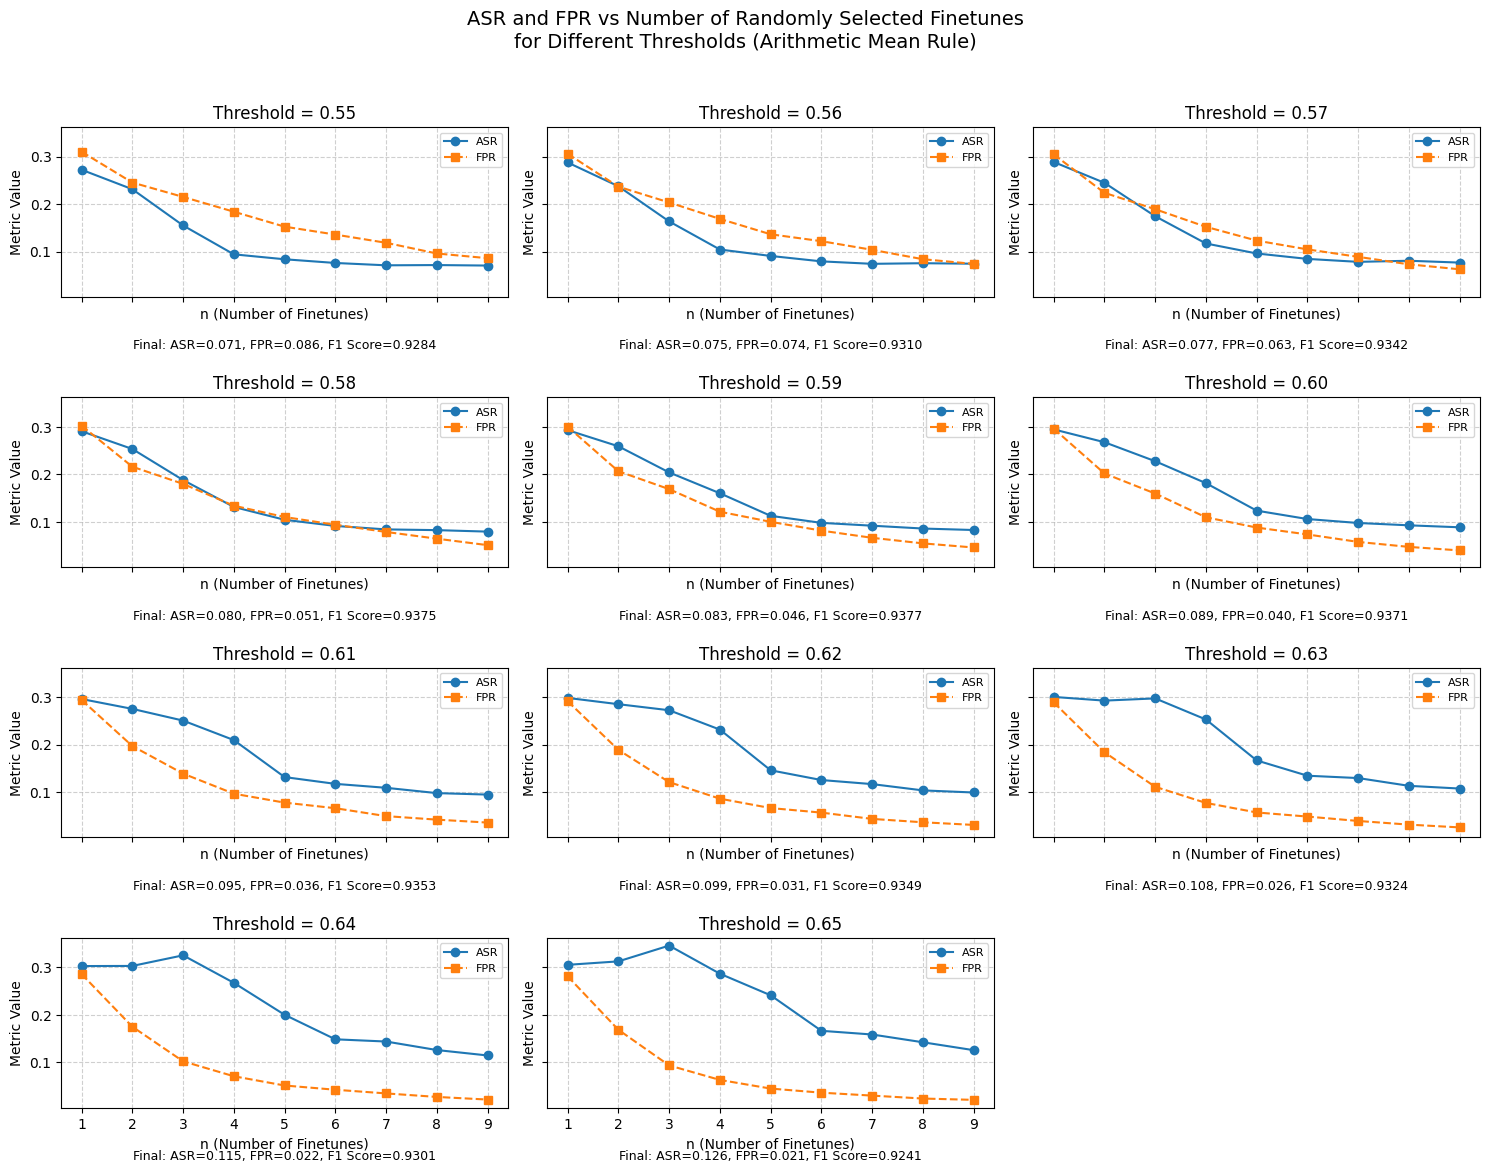

In [ ]:
# Collect finetune model probabilities
finetune_probs = [
    model_1_probs,
    model_2_probs,
    model_3_probs,
    model_4_probs,
    model_5_probs,
    model_6_probs,
    model_7_probs,
    model_8_probs,
    model_9_probs
]

n_models = len(finetune_probs)
n_samples = len(test_labels)
thresholds = np.arange(0.55, 0.66, 0.01)

random.seed(42)
all_results = []

# --- Main loop: n = 1..5, threshold sweep ---
for n in range(1, n_models + 1):
    combined_probs = []
    for i in range(n_samples):
        selected_indices = random.sample(range(n_models), n)
        avg_prob = np.mean([finetune_probs[j][i] for j in selected_indices])
        combined_probs.append(avg_prob)
    combined_probs = np.array(combined_probs)

    for thresh in thresholds:
        preds = [1 if p > thresh else 0 for p in combined_probs]
        metrics = compute_asr_fpr(test_labels, preds)
        f1 = f1_score([int(x) for x in test_labels], preds)
        all_results.append({
            'n': n,
            'threshold': round(thresh, 2),
            'ASR': metrics['ASR'],
            'FPR': metrics['FPR'],
            'F1': f1
        })

results_df = pd.DataFrame(all_results)

# --- Plot: one subplot per threshold, showing both ASR and FPR ---
num_thresholds = len(thresholds)
ncols = 3  # grid layout (3 columns)
nrows = int(np.ceil(num_thresholds / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 3), sharex=True, sharey=True)
axes = axes.flatten()

for idx, thresh in enumerate(thresholds):
    ax = axes[idx]
    subset = results_df[results_df['threshold'] == round(thresh, 2)]

    ax.plot(subset['n'], subset['ASR'], marker='o', label='ASR', color='C0')
    ax.plot(subset['n'], subset['FPR'], marker='s', linestyle='--', label='FPR', color='C1')
    ax.set_title(f'Threshold = {thresh:.2f}')
    ax.set_xlabel('n (Number of Finetunes)')
    ax.set_ylabel('Metric Value')
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(fontsize=8)

    final_row = subset[subset['n'] == len(finetune_probs)].iloc[0]
    final_asr = final_row['ASR']
    final_fpr = final_row['FPR']
    final_f1 = final_row['F1']
    ax.text(
        0.5, -0.25,
        f"Final: ASR={final_asr:.3f}, FPR={final_fpr:.3f}, F1 Score={final_f1:.4f}",
        ha='center', va='top', transform=ax.transAxes, fontsize=9, color='black'
    )

# Hide unused subplots if thresholds don’t fill the grid
for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('ASR and FPR vs Number of Randomly Selected Finetunes\nfor Different Thresholds (Arithmetic Mean Rule)', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

0.8215528984410474
0.8881081081081081
0.8848764594080912
0.9089452603471295
0.9224662609155861
0.9303122118297984
0.930367250230354
0.9323149855148801
0.9375247655527671


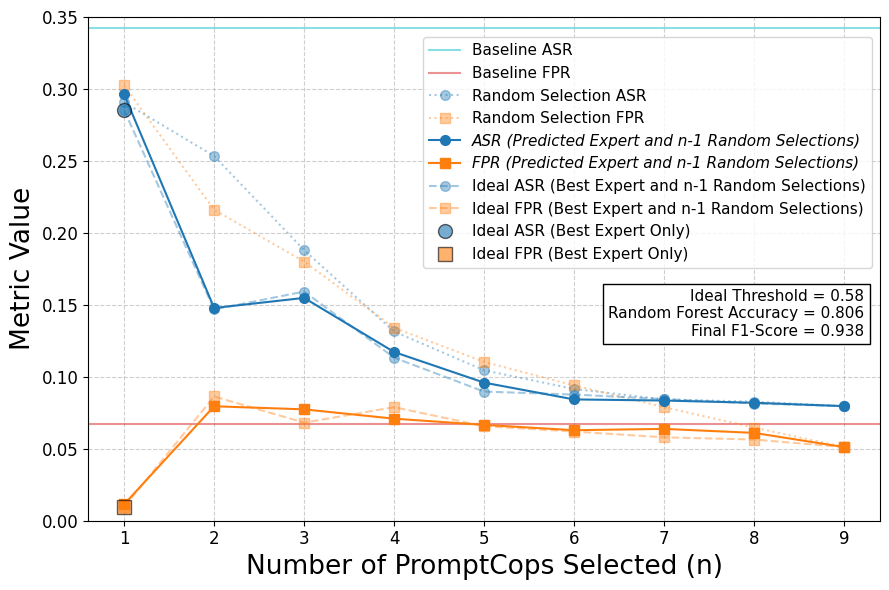

In [ ]:
threshold = 0.58

# Collect all fine-tune model probabilities
finetune_probs = [
    model_1_probs,
    model_2_probs,
    model_3_probs,
    model_4_probs,
    model_5_probs,
    model_6_probs,
    model_7_probs,
    model_8_probs,
    model_9_probs
]

n_models = len(finetune_probs)
n_samples = len(test_labels)
results = []
ideal_results = []
forest_results = []

random.seed(42)  # reproducibility

# --- Baseline (non-finetuned model) ---
baseline_preds = [1 if p > 0.5 else 0 for p in baseline_probs]
baseline_metrics = compute_asr_fpr(test_labels, baseline_preds)
baseline_asr = baseline_metrics['ASR']
baseline_fpr = baseline_metrics['FPR']

# --- Normal random finetune selection for n = 1..5 ---
for n in range(1, n_models + 1):
    combined_probs = []
    for i in range(n_samples):
        selected_indices = random.sample(range(n_models), n)
        avg_prob = np.mean([finetune_probs[j][i] for j in selected_indices])
        combined_probs.append(avg_prob)

    preds = [1 if p > threshold else 0 for p in combined_probs]
    metrics = compute_asr_fpr(test_labels, preds)
    metrics['n'] = n
    results.append(metrics)

# --- Ideal case: always include the best model per sample ---
# best_model_ids is a list of integers from 1 to 5 (same length as test_labels)
for n in range(1, n_models + 1):
    combined_probs = []
    for i in range(n_samples):
        best_model_idx = best_model_ids[i] - 1  # convert 1–5 → 0–4 index

        if n == 1:
            selected_indices = [best_model_idx]
        else:
            # Always include the best model, and select the rest randomly
            other_indices = [idx for idx in range(n_models) if idx != best_model_idx]
            selected_indices = [best_model_idx] + random.sample(other_indices, n - 1)

        avg_prob = np.mean([finetune_probs[j][i] for j in selected_indices])
        combined_probs.append(avg_prob)

    preds = [1 if p > threshold else 0 for p in combined_probs]
    metrics = compute_asr_fpr(test_labels, preds)
    metrics['n'] = n
    ideal_results.append(metrics)


# --- Forest case: always include the random forest model per sample ---
# best_model_ids_forest is a list of integers from 1 to 9 (same length as test_labels)
for n in range(1, n_models + 1):
    combined_probs = []
    for i in range(n_samples):
        best_model_idx = best_model_ids_forest[i] - 1  # convert 1–5 → 0–4 index

        if n == 1:
            selected_indices = [best_model_idx]
        else:
            # Always include the best model, and select the rest randomly
            other_indices = [idx for idx in range(n_models) if idx != best_model_idx]
            selected_indices = [best_model_idx] + random.sample(other_indices, n - 1)

        avg_prob = np.mean([finetune_probs[j][i] for j in selected_indices])
        combined_probs.append(avg_prob)

    preds = [1 if p > threshold else 0 for p in combined_probs]
    metrics = compute_asr_fpr(test_labels, preds)
    metrics['n'] = n
    forest_results.append(metrics)
    forest_final_f1 = f1_score(test_labels, preds)
    print(forest_final_f1)



# --- Extract values for plotting ---
n_values = [r['n'] for r in results]
asr_values = [r['ASR'] for r in results]
fpr_values = [r['FPR'] for r in results]

ideal_asr_values = [r['ASR'] for r in ideal_results]
ideal_fpr_values = [r['FPR'] for r in ideal_results]

forest_asr_values = [r['ASR'] for r in forest_results]
forest_fpr_values = [r['FPR'] for r in forest_results]

# --- Compute final F1 score for the random strategy (at n = ?) ---
# Reconstruct the last (n=?) combined probabilities and predictions
final_combined_probs = []
n_final = n_models
for i in range(n_samples):
    selected_indices = random.sample(range(n_models), n_final)
    avg_prob = np.mean([finetune_probs[j][i] for j in selected_indices])
    final_combined_probs.append(avg_prob)

final_preds = [1 if p > threshold else 0 for p in final_combined_probs]
final_f1 = f1_score(test_labels, final_preds)

# --- Plot ---
plt.figure(figsize=(9, 6))

plt.axhline(y=baseline_asr, color='C9', alpha=0.5, label='Baseline ASR', markersize=7)
plt.axhline(y=baseline_fpr, color='C3', alpha=0.5, label='Baseline FPR', markersize=7)
plt.plot(n_values, asr_values, marker='o', linestyle=':', color='C0', alpha=0.4, label='Random Selection ASR', markersize=7)
plt.plot(n_values, fpr_values, marker='s', linestyle=':', color='C1', alpha=0.4, label='Random Selection FPR', markersize=7)
plt.plot(n_values, forest_asr_values, marker='o', color='C0', label='ASR (Predicted Expert and n-1 Random Selections)', markersize=7)
plt.plot(n_values, forest_fpr_values, marker='s', color='C1', label='FPR (Predicted Expert and n-1 Random Selections)', markersize=7)
plt.plot(n_values, ideal_asr_values, marker='o', linestyle='--', color='C0', alpha=0.4, label='Ideal ASR (Best Expert and n-1 Random Selections)', markersize=7)
plt.plot(n_values, ideal_fpr_values, marker='s', linestyle='--', color='C1', alpha=0.4, label='Ideal FPR (Best Expert and n-1 Random Selections)', markersize=7)

plt.plot(
    n_values[0], ideal_asr_values[0],
    marker='o', markersize=10, linestyle='None',
    color='C0', markeredgecolor='black',
    label='Ideal ASR (Best Expert Only)', zorder=5, alpha=0.6
)

plt.plot(
    n_values[0], ideal_fpr_values[0],
    marker='s', markersize=10, linestyle='None',
    color='C1', markeredgecolor='black',
    label='Ideal FPR (Best Expert Only)', zorder=5, alpha=0.6
)

textstr = f'Ideal Threshold = {threshold}\nRandom Forest Accuracy = {clf.score(X_test, y_test):.3f}\nFinal F1-Score = {final_f1:.3f}'
plt.text(
    0.98, 0.46, textstr,
    transform=plt.gca().transAxes,
    fontsize=11,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(facecolor="white", alpha=1.0)
)

plt.ylim(0, 0.35)
plt.xlabel('Number of PromptCops Selected (n)', fontsize='19')
plt.ylabel('Metric Value', fontsize='19')
# plt.title(
#     f'(k=9) Performance Across Increasing Selection Size',
#     fontweight='bold',
#     fontsize='19'
# )
plt.grid(True, linestyle='--', alpha=0.6)

plt.tick_params(axis='both', which='major', labelsize=12)

leg = plt.legend(loc="upper right", bbox_to_anchor=(0.99, 0.96), borderaxespad=0.0, facecolor="white", fontsize='11')
for text in leg.get_texts():
    if text.get_text() == "ASR (Predicted Expert and n-1 Random Selections)" or text.get_text() == "FPR (Predicted Expert and n-1 Random Selections)":
        text.set_fontstyle('oblique')

plt.tight_layout()
plt.savefig("exp1.pdf", bbox_inches="tight")
plt.show()

In [ ]:
print("Random Selection ASR Values:", asr_values)
print("Random Selection FPR Values:", fpr_values)
print("Ideal ASR Values:", ideal_asr_values)
print("Ideal FPR Values:", ideal_fpr_values)
print("True BAGEL ASR Values:", forest_asr_values)
print("True BAGEL FPR Values:", forest_fpr_values)

Random Selection ASR Values: [0.29071576763485474, 0.2533713692946058, 0.18801867219917012, 0.13148340248962653, 0.10451244813278004, 0.09154564315352698, 0.08428423236514526, 0.0827282157676349, 0.07961618257261416]
Random Selection FPR Values: [0.3024044389642417, 0.2160912453760789, 0.18002466091245375, 0.1340937114673243, 0.11035758323057954, 0.094019728729963, 0.07891491985203453, 0.06473489519112208, 0.051171393341553635]
Ideal ASR Values: [0.28526970954356845, 0.14678423236514526, 0.1592323651452282, 0.11332987551867224, 0.08973029045643155, 0.08765560165975106, 0.08454356846473032, 0.08143153526970959, 0.07961618257261416]
Ideal FPR Values: [0.009556103575832305, 0.08631319358816276, 0.06812577065351418, 0.07891491985203453, 0.0656596794081381, 0.061960542540073986, 0.05795314426633785, 0.056411837237977804, 0.051171393341553635]
True BAGEL ASR Values: [0.296161825726141, 0.1478215767634855, 0.15482365145228216, 0.11721991701244816, 0.09595435684647302, 0.08428423236514526, 0.0

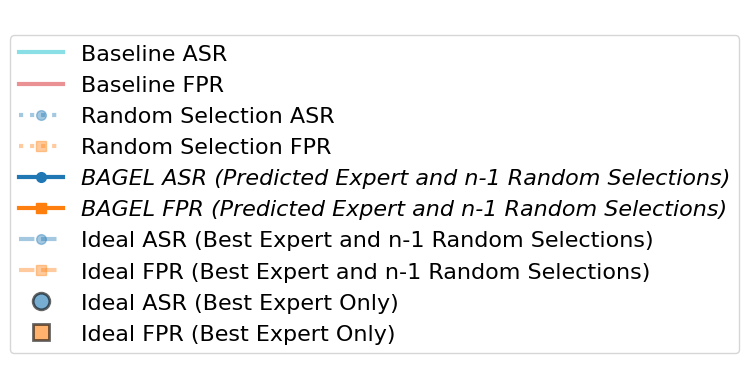

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

handles = [
    Line2D([0], [0], color='C9', alpha=0.5, label='Baseline ASR', linewidth=3, markersize=7),
    Line2D([0], [0], color='C3', alpha=0.5, label='Baseline FPR', linewidth=3, markersize=7),
    Line2D([0], [0], marker='o', linestyle=':', color='C0', alpha=0.4, label='Random Selection ASR', linewidth=3, markersize=7),
    Line2D([0], [0], marker='s', linestyle=':', color='C1', alpha=0.4, label='Random Selection FPR', linewidth=3, markersize=7),
    Line2D([0], [0], marker='o', color='C0', label='BAGEL ASR (Predicted Expert and n-1 Random Selections)', linewidth=3, markersize=7),
    Line2D([0], [0], marker='s', color='C1', label='BAGEL FPR (Predicted Expert and n-1 Random Selections)', linewidth=3, markersize=7),
    Line2D([0], [0], marker='o', linestyle='--', color='C0', alpha=0.4, label='Ideal ASR (Best Expert and n-1 Random Selections)', linewidth=3, markersize=7),
    Line2D([0], [0], marker='s', linestyle='--', color='C1', alpha=0.4, label='Ideal FPR (Best Expert and n-1 Random Selections)', linewidth=3, markersize=7),
    Line2D([0], [0], marker='o', markersize=12, linestyle='None', color='C0',
           markeredgecolor='black', label='Ideal ASR (Best Expert Only)', alpha=0.6, markeredgewidth=2),
    Line2D([0], [0], marker='s', markersize=12, linestyle='None', color='C1',
           markeredgecolor='black', label='Ideal FPR (Best Expert Only)', alpha=0.6, markeredgewidth=2),
]

# Create standalone figure
fig = plt.figure()

leg = fig.legend(
    handles=handles,
    loc="center",
    fontsize=16,          # <-- increase label quality
    frameon=True,
    facecolor="white"
)

# Optional styling
for text in leg.get_texts():
    if "BAGEL" in text.get_text():
        text.set_fontstyle("oblique")

plt.axis("off")

# Save tightly cropped vector PDF
fig.savefig(
    "exp2_legend.pdf",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.05
)

plt.show()


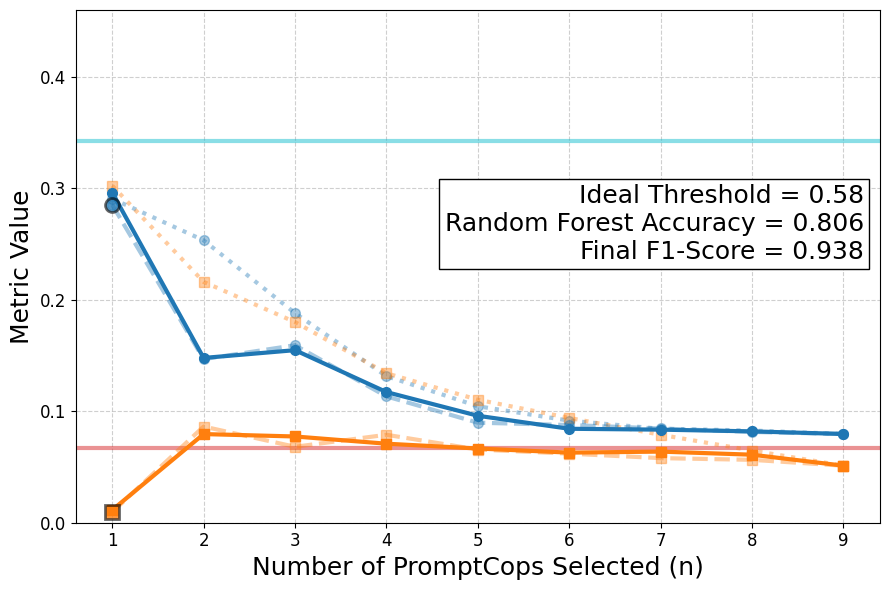

In [ ]:
threshold = 0.58

# Collect all fine-tune model probabilities
finetune_probs = [
    model_1_probs,
    model_2_probs,
    model_3_probs,
    model_4_probs,
    model_5_probs,
    model_6_probs,
    model_7_probs,
    model_8_probs,
    model_9_probs
]

n_models = len(finetune_probs)
n_samples = len(test_labels)
results = []
ideal_results = []
forest_results = []

random.seed(42)  # reproducibility

# --- Baseline (non-finetuned model) ---
baseline_preds = [1 if p > 0.5 else 0 for p in baseline_probs]
baseline_metrics = compute_asr_fpr(test_labels, baseline_preds)
baseline_asr = baseline_metrics['ASR']
baseline_fpr = baseline_metrics['FPR']

# --- Normal random finetune selection for n = 1..5 ---
for n in range(1, n_models + 1):
    combined_probs = []
    for i in range(n_samples):
        selected_indices = random.sample(range(n_models), n)
        avg_prob = np.mean([finetune_probs[j][i] for j in selected_indices])
        combined_probs.append(avg_prob)

    preds = [1 if p > threshold else 0 for p in combined_probs]
    metrics = compute_asr_fpr(test_labels, preds)
    metrics['n'] = n
    results.append(metrics)

# --- Ideal case: always include the best model per sample ---
# best_model_ids is a list of integers from 1 to 5 (same length as test_labels)
for n in range(1, n_models + 1):
    combined_probs = []
    for i in range(n_samples):
        best_model_idx = best_model_ids[i] - 1  # convert 1–5 → 0–4 index

        if n == 1:
            selected_indices = [best_model_idx]
        else:
            # Always include the best model, and select the rest randomly
            other_indices = [idx for idx in range(n_models) if idx != best_model_idx]
            selected_indices = [best_model_idx] + random.sample(other_indices, n - 1)

        avg_prob = np.mean([finetune_probs[j][i] for j in selected_indices])
        combined_probs.append(avg_prob)

    preds = [1 if p > threshold else 0 for p in combined_probs]
    metrics = compute_asr_fpr(test_labels, preds)
    metrics['n'] = n
    ideal_results.append(metrics)


# --- Forest case: always include the random forest model per sample ---
# best_model_ids_forest is a list of integers from 1 to 9 (same length as test_labels)
for n in range(1, n_models + 1):
    combined_probs = []
    for i in range(n_samples):
        best_model_idx = best_model_ids_forest[i] - 1  # convert 1–5 → 0–4 index

        if n == 1:
            selected_indices = [best_model_idx]
        else:
            # Always include the best model, and select the rest randomly
            other_indices = [idx for idx in range(n_models) if idx != best_model_idx]
            selected_indices = [best_model_idx] + random.sample(other_indices, n - 1)

        avg_prob = np.mean([finetune_probs[j][i] for j in selected_indices])
        combined_probs.append(avg_prob)

    preds = [1 if p > threshold else 0 for p in combined_probs]
    metrics = compute_asr_fpr(test_labels, preds)
    metrics['n'] = n
    forest_results.append(metrics)
    forest_final_f1 = f1_score(test_labels, preds)



# --- Extract values for plotting ---
n_values = [r['n'] for r in results]
asr_values = [r['ASR'] for r in results]
fpr_values = [r['FPR'] for r in results]

ideal_asr_values = [r['ASR'] for r in ideal_results]
ideal_fpr_values = [r['FPR'] for r in ideal_results]

forest_asr_values = [r['ASR'] for r in forest_results]
forest_fpr_values = [r['FPR'] for r in forest_results]

# --- Compute final F1 score for the random strategy (at n = ?) ---
# Reconstruct the last (n=?) combined probabilities and predictions
final_combined_probs = []
n_final = n_models
for i in range(n_samples):
    selected_indices = random.sample(range(n_models), n_final)
    avg_prob = np.mean([finetune_probs[j][i] for j in selected_indices])
    final_combined_probs.append(avg_prob)

final_preds = [1 if p > threshold else 0 for p in final_combined_probs]
final_f1 = f1_score(test_labels, final_preds)

# --- Plot ---
plt.figure(figsize=(9, 6))

plt.axhline(y=baseline_asr, color='C9', alpha=0.5, label='Baseline ASR', linewidth=3, markersize=7)
plt.axhline(y=baseline_fpr, color='C3', alpha=0.5, label='Baseline FPR', linewidth=3, markersize=7)
plt.plot(n_values, asr_values, marker='o', linestyle=':', color='C0', alpha=0.4, label='Random Selection ASR', linewidth=3, markersize=7)
plt.plot(n_values, fpr_values, marker='s', linestyle=':', color='C1', alpha=0.4, label='Random Selection FPR', linewidth=3, markersize=7)
plt.plot(n_values, forest_asr_values, marker='o', color='C0', label='ASR (Predicted Expert and n-1 Random Selections)', linewidth=3, markersize=7)
plt.plot(n_values, forest_fpr_values, marker='s', color='C1', label='FPR (Predicted Expert and n-1 Random Selections)', linewidth=3, markersize=7)
plt.plot(n_values, ideal_asr_values, marker='o', linestyle='--', color='C0', alpha=0.4, label='Ideal ASR (Best Expert and n-1 Random Selections)', linewidth=3, markersize=7)
plt.plot(n_values, ideal_fpr_values, marker='s', linestyle='--', color='C1', alpha=0.4, label='Ideal FPR (Best Expert and n-1 Random Selections)', linewidth=3, markersize=7)

plt.plot(
    n_values[0], ideal_asr_values[0],
    marker='o', markersize=10, linestyle='None',
    color='C0', markeredgecolor='black',
    label='Ideal ASR (Best Expert Only)', zorder=5, alpha=0.6, markeredgewidth=2
)

plt.plot(
    n_values[0], ideal_fpr_values[0],
    marker='s', markersize=10, linestyle='None',
    color='C1', markeredgecolor='black',
    label='Ideal FPR (Best Expert Only)', zorder=5, alpha=0.6, markeredgewidth=2
)

textstr = f'Ideal Threshold = {threshold}\nRandom Forest Accuracy = {clf.score(X_test, y_test):.3f}\nFinal F1-Score = {final_f1:.3f}'
plt.text(
    0.98, 0.66, textstr,
    transform=plt.gca().transAxes,
    fontsize=18,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(facecolor="white", alpha=1.0)
)

plt.ylim(0, 0.46)
plt.xlabel('Number of PromptCops Selected (n)', fontsize='18')
plt.ylabel('Metric Value', fontsize='18')
# plt.title(
#     f'(k=9) Performance Across Increasing Selection Size',
#     fontweight='bold',
#     fontsize='19'
# )
plt.grid(True, linestyle='--', alpha=0.6)

plt.tick_params(axis='both', which='major', labelsize=12)

# leg = plt.legend(loc="upper right", bbox_to_anchor=(0.99, 0.96), borderaxespad=0.0, facecolor="white", fontsize='11')
# for text in leg.get_texts():
#     if text.get_text() == "ASR (Predicted Expert and n-1 Random Selections)" or text.get_text() == "FPR (Predicted Expert and n-1 Random Selections)":
#         text.set_fontstyle('oblique')

plt.tight_layout()
plt.savefig("exp2_9.pdf", bbox_inches="tight")
plt.show()

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~